# Predicción del riesgo de mortalidad en UCI cardiovascular (pediátrica)

**Objetivo del notebook:** preparar y depurar el dataset clínico para una posterior etapa de modelado predictivo. En este notebook realizaremos:

- Carga de librerías.
- Carga y exploración inicial del dataset.
- Detección y tratamiento de valores faltantes.
- Normalización de nombres de columnas y conversión de tipos.
- Tratamiento de variables categóricas y numéricas (codificación, detección de outliers, escalado).
- Detección de valores incoherentes.
- Análisis exploratorio inicial con visualizaciones.
- Exportación del dataset limpio para la fase de modelado.

Todas las acciones están documentadas y pensadas para datos clínicos; adapta umbrales y reglas según el conocimiento médico disponible.

In [1]:
%pip install pandas openpyxl matplotlib seaborn scikit-learn fuzzywuzzy python-Levenshtein

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
from pathlib import Path
import pandas as pd

# Ruta base del proyecto
BASE_DIR = Path.cwd().parent

# Ruta al dataset
DATA_PATH = BASE_DIR / "data" / "datasets" / "dataset_inicial.xlsx"

print("Ruta al dataset:", DATA_PATH)
print("¿Existe el archivo?", DATA_PATH.exists())

# Cargar datos
df = pd.read_excel(DATA_PATH)

df.head()

Ruta al dataset: /home/pablo/Desktop/Estressss/pdg/data/datasets/dataset_inicial.xlsx
¿Existe el archivo? True


,EPISODIO,Nº documento,NOMBRE,Descripción Aseguradora,Clase de Aseguradora,SEXO,EDAD,D - M - A,Peso,Talla,...,CREATININA PREQX,NITROGENO UREICO PREQX,LEUCOCITOS PREQX,PT PREQX,PTT PREQX,PLAQUETAS PREQX,FECHA ECOCARDIOGRAMA,DOPPLER TISULAR MITRAL,FEVI / ProBNP,FUNCIÓN CUALITATIVA DEL VENTRICULO IZQUIERDO
0,6588058.0,1059607683,DIANA JULISSA BERMUDEZ HURTADO,ASMET SALUD EPS S.A.S. RS,SUBSIDIADO,F,1.0,AÑOS,9.2,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6757680.0,1113779731,JENIFER ZAPATA TORO,NUEVA EPS S.A. RC,CONTRIBUTIVO,F,33.0,AÑOS,38.0,119.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6829110.0,1072926244,JOEL SANTIAGO VALENCIA CASTELLANOS,NUEVA EPS S.A. RC,CONTRIBUTIVO,M,2.0,AÑOS,10.5,82.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6833879.0,1114244350,LOREN DAYANA VILLARAGA,SERVICIO OCCID. DE SALUD RC,CONTRIBUTIVO,F,10.0,AÑOS,29.0,133.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6833890.0,1112067026,ESTEBAN AVIRAMA PAZ,EPS SURAMERICANA S.A CARDIOPEDIA,CONTRIBUTIVO,M,2.0,AÑOS,4.6,57.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Limpieza de datos

Realizaremos la limpieza de los datos disponibles para determinar la mejor estrategia frente a los valores faltantes, ya sea eliminarlos, imputarlos o solicitar información adicional. Asimismo, procederemos a eliminar los registros duplicados para garantizar la calidad y precisión del análisis.

In [4]:
df_copy = df.copy()

In [5]:
print("Número de registros duplicados:", df_copy.duplicated().sum())

Número de registros duplicados: 3


In [6]:
df_copy = df_copy.drop_duplicates()
print(f"Dimensiones del DataFrame después de eliminar duplicados: {df_copy.shape}")

Dimensiones del DataFrame después de eliminar duplicados: (1008, 99)


In [7]:
threshold = 0.5  # Si una fila tiene más del 50% de NaN, eliminarla
min_non_null = int(df_copy.shape[1] * (1 - threshold))
non_null_counts = df_copy.count(axis=1)
rows_to_keep = non_null_counts >= min_non_null
df_copy = df_copy[rows_to_keep].copy()

In [8]:
print(f"Dimensiones del DataFrame después de eliminar registros con el 50% de su info NaN: {df_copy.shape}")

Dimensiones del DataFrame después de eliminar registros con el 50% de su info NaN: (970, 99)


Debido a que se encontraros $3$ registros duplicados se eliminaron y  $1$ cuya información en su mayoria era NaN ahora tenemos $1007$ registros

In [9]:
# Calcular datos faltantes
missing_data = df_copy.isnull().sum()
missing_percent = 100 * missing_data / len(df_copy)

# Construir tabla de datos faltantes y ordenarla
missing_table = pd.DataFrame({
    'Total Missing Data': missing_data,
    'Missing Percent': missing_percent
}).sort_values(by='Missing Percent', ascending=False)

# Total de filas
total_data = len(df_copy)
print(f"Total de filas en el DataFrame: {total_data}\n")

# Mostrar resumen general si hay datos faltantes
missing_with_data = missing_table[missing_table['Missing Percent'] > 0]
if not missing_with_data.empty:
    print("Resumen de columnas con datos faltantes:\n")
    print(missing_with_data.to_string())
else:
    print("No hay datos faltantes en el DataFrame.")

# Filtrar columnas de interés específicas
interest_columns = ['MORTALIDAD GENERAL', 'MORTALIDAD A 30 DÍAS']
filtered_missing = missing_table.loc[missing_table.index.isin(interest_columns)].reset_index()
filtered_missing.rename(columns={'index': 'Atributo'}, inplace=True)

# Mostrar tabla filtrada solo si contiene datos
if not filtered_missing.empty:
    print("\nDatos faltantes en columnas de interés:")
    print(filtered_missing.to_string(index=False))
else:
    print("\nLas columnas de interés no tienen datos faltantes o no existen en el DataFrame.")

Total de filas en el DataFrame: 970

Resumen de columnas con datos faltantes:

                                              Total Missing Data  Missing Percent
CO2 PREQX                                                    970       100.000000
pH PREQX                                                     970       100.000000
FC PREQX                                                     970       100.000000
FEVI / ProBNP                                                970       100.000000
DOPPLER TISULAR MITRAL                                       970       100.000000
FUNCIÓN CUALITATIVA DEL VENTRICULO IZQUIERDO                 970       100.000000
FECHA ECOCARDIOGRAMA                                         970       100.000000
PLAQUETAS PREQX                                              970       100.000000
PTT PREQX                                                    970       100.000000
PT PREQX                                                     970       100.000000
LEUCOCITOS PREQX   

Mediante el resultado anterior, analizamos cada atributo con datos faltantes, obteniendo tanto el total de registros vacíos como su proporción respecto al conjunto de datos ($1007$ registros). Los atributos cuyos valores están completos no se incluyen en la tabla. Es fundamental revisar los atributos de interés, es decir, nuestras variables objetivo, para evaluar la viabilidad del modelo según el porcentaje de datos faltantes y definir la estrategia de tratamiento adecuada. En este caso, `MORTALIDAD GENERAL` Y `MORTALIDAD A 30 DÍAS` no presentan valores faltantes.

Por otro lado, identificamos que en algunas columnas, como Disfunción Multiorgánica, Arritmias, ISO, Sangrado, Sepsis y otras, los valores que inicialmente parecen ser datos faltantes (NaN) en realidad representan casos en los que el paciente no presentó esa condición. Por lo tanto, estos valores no deben considerarse como nulos, sino como una ausencia de la condición, y es necesario imputarlos adecuadamente para reflejar esta situación.

In [10]:
# Lista de columnas donde los valores nulos representan "NO APLICA"
columns_to_replace = ["Disfunción Multiorganica", "Arritmias", "Sangrado", "ISO", "Sepsis", "Fecha Fin ECMO", "Fecha Inicio ECMO", "Tipo Ventilación Mecanica", "Medicamentos-Antibiotico Profilaxis", "Antibióticos Profilácticos"]

# Reemplazar valores nulos por "NO APLICA" en las columnas especificadas
for col in columns_to_replace:
    if col in df_copy.columns:
        df_copy[col] = df_copy[col].fillna("NO APLICA")
        print(f"Valores NaN en la columna '{col}' han sido reemplazados por 'NO APLICA'")
    else:
        print(f"Columna '{col}' no encontrada en el DataFrame")

Valores NaN en la columna 'Disfunción Multiorganica' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'Arritmias' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'Sangrado' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'ISO' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'Sepsis' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'Fecha Fin ECMO' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'Fecha Inicio ECMO' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'Tipo Ventilación Mecanica' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'Medicamentos-Antibiotico Profilaxis' han sido reemplazados por 'NO APLICA'
Valores NaN en la columna 'Antibióticos Profilácticos' han sido reemplazados por 'NO APLICA'


In [11]:
# Calcular datos faltantes
missing_data = df_copy.isnull().sum()
missing_percent = 100 * missing_data / len(df_copy)

# Construir tabla de datos faltantes y ordenarla
missing_table = pd.DataFrame({
    'Total Missing Data': missing_data,
    'Missing Percent': missing_percent
}).sort_values(by='Missing Percent', ascending=False)

# Total de filas
total_data = len(df_copy)
print(f"Total de filas en el DataFrame: {total_data}\n")

# Mostrar resumen general si hay datos faltantes
missing_with_data = missing_table[missing_table['Missing Percent'] > 0]
if not missing_with_data.empty:
    print("Resumen de columnas con datos faltantes:\n")
    print(missing_with_data.to_string())
else:
    print("No hay datos faltantes en el DataFrame.")

# Filtrar columnas de interés específicas
interest_columns = ['MORTALIDAD GENERAL', 'MORTALIDAD A 30 DÍAS']
filtered_missing = missing_table.loc[missing_table.index.isin(interest_columns)].reset_index()
filtered_missing.rename(columns={'index': 'Atributo'}, inplace=True)

# Mostrar tabla filtrada solo si contiene datos
if not filtered_missing.empty:
    print("\nDatos faltantes en columnas de interés:")
    print(filtered_missing.to_string(index=False))
else:
    print("\nLas columnas de interés no tienen datos faltantes o no existen en el DataFrame.")

Total de filas en el DataFrame: 970

Resumen de columnas con datos faltantes:

                                              Total Missing Data  Missing Percent
CO2 PREQX                                                    970       100.000000
pH PREQX                                                     970       100.000000
FC PREQX                                                     970       100.000000
FEVI / ProBNP                                                970       100.000000
DOPPLER TISULAR MITRAL                                       970       100.000000
FUNCIÓN CUALITATIVA DEL VENTRICULO IZQUIERDO                 970       100.000000
FECHA ECOCARDIOGRAMA                                         970       100.000000
PLAQUETAS PREQX                                              970       100.000000
PTT PREQX                                                    970       100.000000
PT PREQX                                                     970       100.000000
LEUCOCITOS PREQX   

Por otro lado, identificamos que algunas variables que deberían ser numéricas, como Circulatorio Hora Total, Bomba Hora Total, Isquemia Hora Total y tiempo quirurgico y TIEMPO QUIROFANO, están clasificadas como categóricas. Por lo tanto, es necesario convertirlas al tipo de dato numérico. Asimismo, la información de la edad está dividida en dos columnas: una que contiene el valor numérico y otra que indica la unidad de tiempo (años, meses o días). Es necesario unificar estas dos columnas en una sola, convirtiendo todo a una escala común (por ejemplo, años) para facilitar el análisis."

In [12]:
import datetime

# Lista de columnas a convertir
columns_to_convert = ["Paro Circulatorio Hora Total", "Bomba Hora Total", "Isquemia Hora Total", "Tiempo quirurgico ", "TIEMPO QUIROFANO"]

# Función para convertir datetime.datetime a horas
def convert_to_hours(value):
    if pd.isnull(value):
        return np.nan
    if isinstance(value, datetime.datetime):
        # Extraer horas y minutos como duración
        return value.hour + value.minute / 60 + value.second / 3600
    if isinstance(value, datetime.time):
        # Si es datetime.time, convertir a horas
        return value.hour + value.minute / 60 + value.second / 3600
    return np.nan  # Si no es un tipo válido, devolver NaN

# Aplicar la conversión a cada columna
for col in columns_to_convert:
    if col in df_copy.columns:
        df_copy[col] = df_copy[col].apply(convert_to_hours)
        print(f"Columna '{col}' convertida a horas.")
        print(df_copy[col].head(50).tolist())
    else:
        print(f"Columna '{col}' no encontrada en el DataFrame.")

Columna 'Paro Circulatorio Hora Total' convertida a horas.
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, 0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, 0.0, nan, 0.0, 0.0, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.21666666666666667, 0.21666666666666667, 0.21666666666666667, 0.21666666666666667, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, 0.0, 0.0, nan, nan, nan, nan, 0.0, 0.0, 0.0]
Columna 'Bomba Hora Total' convertida a horas.
[0.5833333333333334, 0.4, 0.5, 0.8666666666666667, 0.8666666666666667, 1.2333333333333334, 1.2333333333333334, 1.2333333333333334, 0.45, 2.9333333333333336, nan, 1.35, nan, 0.5, 0.0, 0.0, nan, 0.1, 0.0, 0.0, nan, 2.8666666666666667, 2.8666666666666667, nan, 0.7333333333333333, 0.65, 2.45, 2.45, 2.45, 2.3333333333333335, 2.3333333333333335, 2.3333333333333335, 2.3333333333333335, 0.43333333333333335, 1.3, 1.3, 1.3, 1.3, 1.3, 0.9333333333333333, nan, 0.5833333333333334, 0.8333333333333334, nan, nan, nan, nan, 2.0833333333333335, 1

In [13]:
# Crear una nueva columna de edad unificada en años
def unificar_edad(edad_val, unidad):
    """
    Convierte la edad a años según la unidad especificada
    """
    if pd.isna(edad_val) or pd.isna(unidad):
        return np.nan

    try:
        edad_num = float(edad_val)
        unidad_clean = str(unidad).upper().strip()

        # Convertir según la unidad
        if unidad_clean in ['AÑOS', 'AÑO', 'A']:
            return edad_num
        elif unidad_clean in ['MESES', 'M']:
            return edad_num / 12  # Convertir meses a años
        elif unidad_clean in ['DIAS', 'D']:
            return edad_num / 365.25  # Convertir días a años (considerando años bisiestos)
        else:
            print(f"Unidad no reconocida: {unidad_clean}")
            return np.nan
    except (ValueError, TypeError):
        print(f"Error al convertir edad: {edad_val}, unidad: {unidad}")
        return np.nan

# Aplicar la función para crear la nueva columna
df_copy['EDAD_AÑOS'] = df_copy.apply(lambda row: unificar_edad(row['EDAD'], row['D - M - A']), axis=1)

# Verificar el resultado
print("=== RESUMEN DE CONVERSIÓN DE EDAD ===")
print(f"Total de registros: {len(df_copy)}")
print(f"Valores válidos de edad convertidos: {df_copy['EDAD_AÑOS'].notna().sum()}")
print(f"Valores faltantes: {df_copy['EDAD_AÑOS'].isna().sum()}")

# Mostrar estadísticas descriptivas
print(f"\n=== ESTADÍSTICAS DE EDAD EN AÑOS ===")
print(df_copy['EDAD_AÑOS'].describe())

# Verificar algunos ejemplos de la conversión
print(f"\n=== EJEMPLOS DE CONVERSIÓN ===")
sample_data = df_copy[['EDAD', 'D - M - A', 'EDAD_AÑOS']].dropna().head(10)
print(sample_data.to_string(index=False))

# Analizar distribución por rango pediátrico
pediatrico = df_copy['EDAD_AÑOS'] < 18
adulto = df_copy['EDAD_AÑOS'] >= 18

print(f"\n=== ANÁLISIS PEDIÁTRICO ===")
print(f"Pacientes pediátricos (<18 años): {pediatrico.sum()}")
print(f"Pacientes adultos (≥18 años): {adulto.sum()}")
print(f"Porcentaje pediátrico: {(pediatrico.sum() / df_copy['EDAD_AÑOS'].notna().sum() * 100):.1f}%")

df_copy = df_copy.drop(['EDAD', 'D - M - A'], axis=1)
print("\nColumnas originales de edad('EDAD' y 'D - M - A') eliminadas.")

=== RESUMEN DE CONVERSIÓN DE EDAD ===
Total de registros: 970
Valores válidos de edad convertidos: 956
Valores faltantes: 14

=== ESTADÍSTICAS DE EDAD EN AÑOS ===
count    956.000000
mean       2.763457
std        5.563119
min        0.002738
25%        0.076660
50%        0.416667
75%        2.000000
max       43.000000
Name: EDAD_AÑOS, dtype: float64

=== EJEMPLOS DE CONVERSIÓN ===
 EDAD D - M - A  EDAD_AÑOS
 33.0      AÑOS  33.000000
  2.0      AÑOS   2.000000
 10.0      AÑOS  10.000000
  2.0      AÑOS   2.000000
  2.0      AÑOS   2.000000
  1.0     MESES   0.083333
  1.0     MESES   0.083333
  1.0     MESES   0.083333
  3.0      AÑOS   3.000000
  1.0     MESES   0.083333

=== ANÁLISIS PEDIÁTRICO ===
Pacientes pediátricos (<18 años): 931
Pacientes adultos (≥18 años): 25
Porcentaje pediátrico: 97.4%

Columnas originales de edad('EDAD' y 'D - M - A') eliminadas.


In [14]:
# Eliminar pacientes adultos (≥18 años) del DataFrame
print("=== ELIMINACIÓN DE PACIENTES ADULTOS ===")
print(f"Dimensiones originales del DataFrame: {df_copy.shape}")

# Contar pacientes antes de filtrar
total_pacientes = len(df_copy)
adultos_antes = (df_copy['EDAD_AÑOS'] >= 18).sum()

print(f"Total de pacientes: {total_pacientes}")
print(f"Pacientes adultos (≥18 años): {adultos_antes}")

# Filtrar para mantener solo pacientes pediátricos
# Mantener pacientes <18 años Y también aquellos con edad desconocida
df_copy = df_copy[(df_copy['EDAD_AÑOS'] < 18) | (df_copy['EDAD_AÑOS'].isna())].copy()

print(f"\nDimensiones después de eliminar adultos: {df_copy.shape}")
print(f"Pacientes eliminados: {total_pacientes - len(df_copy)}")

# Verificar el resultado
pediatricos_despues = (df_copy['EDAD_AÑOS'] < 18).sum()

print(f"\nRESULTADO FINAL:")
print(f"Total de pacientes en el dataset pediátrico: {len(df_copy)}")

=== ELIMINACIÓN DE PACIENTES ADULTOS ===
Dimensiones originales del DataFrame: (970, 98)
Total de pacientes: 970
Pacientes adultos (≥18 años): 25

Dimensiones después de eliminar adultos: (945, 98)
Pacientes eliminados: 25

RESULTADO FINAL:
Total de pacientes en el dataset pediátrico: 945


In [15]:
print('\n--- Información general completa ---')
print(df_copy.info())


--- Información general completa ---
<class 'pandas.core.frame.DataFrame'>
Index: 945 entries, 2 to 1009
Data columns (total 98 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   EPISODIO                                      945 non-null    float64       
 1   Nº documento                                  945 non-null    object        
 2   NOMBRE                                        945 non-null    object        
 3   Descripción Aseguradora                       945 non-null    object        
 4   Clase de Aseguradora                          945 non-null    object        
 5   SEXO                                          934 non-null    object        
 6   Peso                                          856 non-null    float64       
 7   Talla                                         652 non-null    float64       
 8   IMC                                 

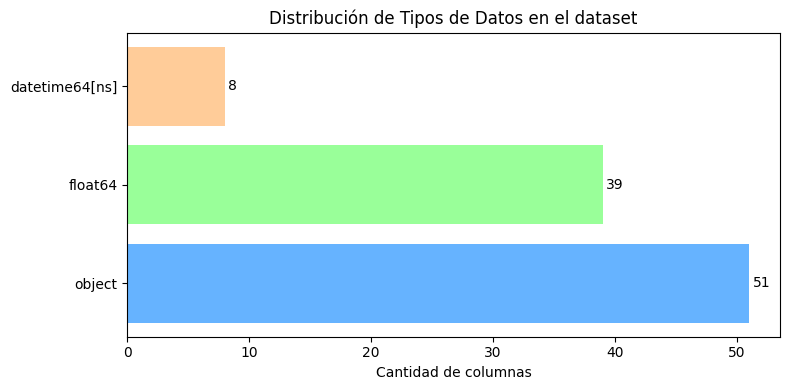

In [16]:
# Contar los tipos de datos en el DataFrame
dtype_counts = df_copy.dtypes.value_counts()
dtype_df = pd.DataFrame({
    'Tipo de Dato': dtype_counts.index.astype(str),
    'Conteo': dtype_counts.values
})

# Colores personalizados
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

# Crear gráfico de barras horizontales
plt.figure(figsize=(8, 4))
bars = plt.barh(dtype_df['Tipo de Dato'], dtype_df['Conteo'], color=colors)

# Añadir etiquetas sobre las barras
for bar, count in zip(bars, dtype_df['Conteo']):
    plt.text(count + 0.3, bar.get_y() + bar.get_height() / 2, str(count),
             va='center', ha='left', color='black')

# Título y estilo
plt.title('Distribución de Tipos de Datos en el dataset')
plt.xlabel('Cantidad de columnas')
plt.tight_layout()
plt.show()

In [17]:
# Calcular datos faltantes
missing_data = df_copy.isnull().sum()
missing_percent = 100 * missing_data / len(df_copy)

# Construir tabla de datos faltantes y ordenarla
missing_table = pd.DataFrame({
    'Total Missing Data': missing_data,
    'Missing Percent': missing_percent
}).sort_values(by='Missing Percent', ascending=False)

# Total de filas
total_data = len(df_copy)
print(f"Total de filas en el DataFrame: {total_data}\n")

# Mostrar resumen general si hay datos faltantes
missing_with_data = missing_table[missing_table['Missing Percent'] > 0]
if not missing_with_data.empty:
    print("Resumen de columnas con datos faltantes:\n")
    print(missing_with_data.to_string())
else:
    print("No hay datos faltantes en el DataFrame.")

# Filtrar columnas de interés específicas
interest_columns = ['MORTALIDAD GENERAL', 'MORTALIDAD A 30 DÍAS']
filtered_missing = missing_table.loc[missing_table.index.isin(interest_columns)].reset_index()
filtered_missing.rename(columns={'index': 'Atributo'}, inplace=True)

# Mostrar tabla filtrada solo si contiene datos
if not filtered_missing.empty:
    print("\nDatos faltantes en columnas de interés:")
    print(filtered_missing.to_string(index=False))
else:
    print("\nLas columnas de interés no tienen datos faltantes o no existen en el DataFrame.")

Total de filas en el DataFrame: 945

Resumen de columnas con datos faltantes:

                                              Total Missing Data  Missing Percent
CO2 PREQX                                                    945       100.000000
pH PREQX                                                     945       100.000000
DOPPLER TISULAR MITRAL                                       945       100.000000
FEVI / ProBNP                                                945       100.000000
FUNCIÓN CUALITATIVA DEL VENTRICULO IZQUIERDO                 945       100.000000
FC PREQX                                                     945       100.000000
FECHA ECOCARDIOGRAMA                                         945       100.000000
PLAQUETAS PREQX                                              945       100.000000
PTT PREQX                                                    945       100.000000
PT PREQX                                                     945       100.000000
LEUCOCITOS PREQX   

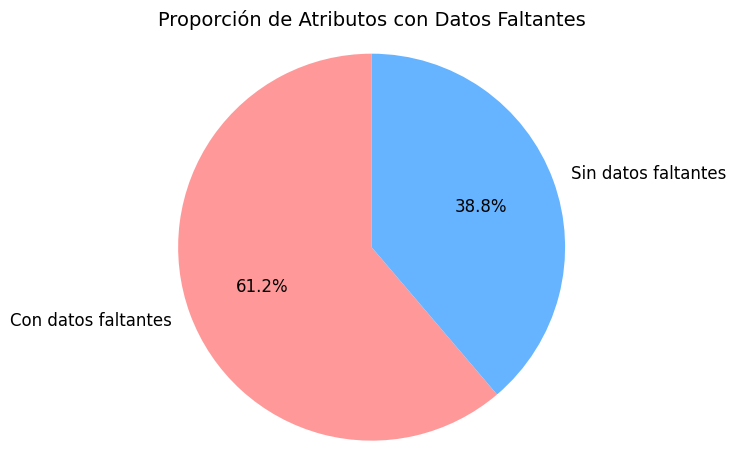

In [18]:
# Clasificación binaria: columnas con y sin datos faltantes
missing_data_bool = missing_data > 0
has_missing_data = missing_data_bool.sum()
no_missing_data = len(missing_data_bool) - has_missing_data

# Preparar datos para el gráfico de torta
labels = ['Con datos faltantes', 'Sin datos faltantes']
sizes = [has_missing_data, no_missing_data]
colors = ['#ff9999', '#66b3ff']

# Mostrar gráfico solo si hay columnas con datos faltantes
if has_missing_data > 0:
    plt.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12}
    )
    plt.axis('equal')  # Mantener proporciones de círculo
    plt.title('Proporción de Atributos con Datos Faltantes', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo hay columnas con datos faltantes. Se omite el gráfico de torta.")

El análisis del diagrama anterior revela que un $64.3$% de los atributos presentan datos faltantes, lo que exige especial atención en su tratamiento. Para abordar esta situación, hemos establecido criterios según el porcentaje de datos faltantes en cada atributo $x$:

- **Si $x \geq 75$**: **Eliminación**. Dado el alto porcentaje de datos faltantes, la información contenida en estos atributos es prácticamente nula y podría generar sesgos en el análisis.
- **Si $20 \leq x < 75$**: **Análisis**.
- **Si $x < 20$**: **Imputación de datos**. Con un porcentaje relativamente bajo de valores faltantes, la imputación permite conservar la información y mejorar la calidad del análisis.

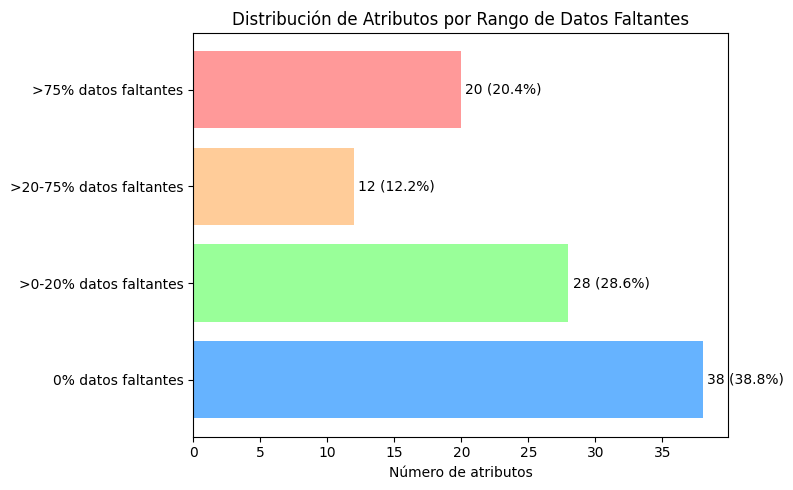

In [19]:
# Clasificar atributos por rangos de porcentaje de datos faltantes
range_0 = missing_percent[missing_percent == 0]
range_20 = missing_percent[(missing_percent > 0) & (missing_percent <= 20)]
range_75 = missing_percent[(missing_percent > 20) & (missing_percent <= 75)]
range_100 = missing_percent[missing_percent > 75]

# Datos para el gráfico
labels = [
    '0% datos faltantes',
    '>0-20% datos faltantes',
    '>20-75% datos faltantes',
    '>75% datos faltantes'
]
sizes = [len(range_0), len(range_20), len(range_75), len(range_100)]
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

# Crear gráfico de barras horizontales
plt.figure(figsize=(8, 5))
bars = plt.barh(labels, sizes, color=colors)

# Añadir etiquetas con número y porcentaje
total_attrs = len(missing_percent)
for bar, size in zip(bars, sizes):
    plt.text(
        size + 0.3, bar.get_y() + bar.get_height() / 2,
        f'{size} ({(size / total_attrs * 100):.1f}%)',
        va='center'
    )

# Estilo
plt.title('Distribución de Atributos por Rango de Datos Faltantes')
plt.xlabel('Número de atributos')
plt.tight_layout()
plt.show()

### Eliminar atributos ($x \geq 75\%$)

In [20]:
# Identificar columnas con ≥75% de valores perdidos
columns_to_drop = missing_percent[missing_percent >= 75].index

# Eliminar esas columnas del conjunto de datos
df_clean = df_copy.drop(columns=columns_to_drop).copy()

In [21]:
df_clean.shape

(945, 78)

Tras la eliminación de los atributos con más del $75$% de valores faltantes, se redujo significativamente la dimensionalidad del conjunto de datos, pasando de $99$ a $78$ columnas.

In [22]:
### Identificación y listado de variables por rangos de datos faltantes

# Calcular datos faltantes actualizados
missing_data = df_clean.isnull().sum()
missing_percent = 100 * missing_data / len(df_clean)

# Clasificar variables por rangos
range_0 = missing_percent[missing_percent == 0]
range_20 = missing_percent[(missing_percent > 0) & (missing_percent <= 20)]
range_75 = missing_percent[(missing_percent > 20) & (missing_percent <= 75)]
range_100 = missing_percent[missing_percent > 75]

print("=== CLASIFICACIÓN COMPLETA DE VARIABLES POR RANGO DE DATOS FALTANTES ===")
print(f"Total de variables en el dataset: {len(missing_percent)}")
print(f"Total de registros: {len(df_clean)}\n")

# RANGO 1: 0% datos faltantes
print("🟢 RANGO 1: 0% DATOS FALTANTES")
print(f"Cantidad de variables: {len(range_0)}")
print("Variables:")
if len(range_0) > 0:
    for i, var in enumerate(range_0.index, 1):
        print(f"  {i:2d}. {var}")
else:
    print("  No hay variables sin datos faltantes")

# RANGO 2: >0-20% datos faltantes
print(f"\n🟡 RANGO 2: >0-20% DATOS FALTANTES")
print(f"Cantidad de variables: {len(range_20)}")
print("Variables:")
if len(range_20) > 0:
    for i, (var, pct) in enumerate(range_20.sort_values(ascending=False).items(), 1):
        print(f"  {i:2d}. {var:<40} ({pct:.1f}% faltantes)")
else:
    print("  No hay variables en este rango")

# RANGO 3: >20-75% datos faltantes
print(f"\n🟠 RANGO 3: >20-75% DATOS FALTANTES")
print(f"Cantidad de variables: {len(range_75)}")
print("Variables:")
if len(range_75) > 0:
    for i, (var, pct) in enumerate(range_75.sort_values(ascending=False).items(), 1):
        print(f"  {i:2d}. {var:<40} ({pct:.1f}% faltantes)")
else:
    print("  No hay variables en este rango")

# RANGO 4: >75% datos faltantes
print(f"\n🔴 RANGO 4: >75% DATOS FALTANTES")
print(f"Cantidad de variables: {len(range_100)}")
print("Variables:")
if len(range_100) > 0:
    for i, (var, pct) in enumerate(range_100.sort_values(ascending=False).items(), 1):
        print(f"  {i:2d}. {var:<40} ({pct:.1f}% faltantes)")
else:
    print("  No hay variables en este rango")

=== CLASIFICACIÓN COMPLETA DE VARIABLES POR RANGO DE DATOS FALTANTES ===
Total de variables en el dataset: 78
Total de registros: 945

🟢 RANGO 1: 0% DATOS FALTANTES
Cantidad de variables: 38
Variables:
   1. EPISODIO
   2. Nº documento
   3. NOMBRE
   4. Descripción Aseguradora
   5. Clase de Aseguradora
   6. Valoración por nutrición 
   7. Fecha de Admisión
   8. Estancia Total Hosp
   9. MORTALIDAD GENERAL 
  10. MORTALIDAD A 30 DÍAS 
  11. Anomalias no Cardiacas Mayores
  12. Prematuridad
  13. PROCEDIMIENTO
  14. Junta Medica
  15. CEC 
  16. CLAMP 
  17. ARRESTO CIRCULATORIO
  18. Volumen total cardioplejia 
  19. Uso de OCTAPLEX u OCTAPLAS
  20. Antibióticos Profilácticos
  21. Medicamentos-Antibiotico Profilaxis
  22. Uso de Mupirocina
  23. Ventilación Mecanica
  24. Tipo Ventilación Mecanica
  25. Tiempo de Ventilación Mecanica
  26. ECMO
  27. Fecha Inicio ECMO
  28. Fecha Fin ECMO
  29. Reintervenciones asociadas al ECMO
  30. Reintervención Qx
  31. Causa de Reintervención

### Limpieza de variables numericas

previamente al tratamiento de las variables numericas definiremos una funcion auxiliar para la detección y visualización de datos atipicos

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def analizar_outliers_variable(df, var, unidades=None, mostrar_graficos=True, limite_z=3):
    """
    Analiza datos atípicos (outliers) para una variable numérica usando métodos IQR y Z-Score.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame que contiene la variable a analizar.
    var : str
        Nombre de la columna a analizar.
    unidades : str, opcional
        Texto para indicar las unidades en títulos y ejes.
    mostrar_graficos : bool, opcional
        Si es True, muestra los gráficos de boxplot e histograma.
    limite_z : float, opcional
        Límite absoluto del Z-Score para considerar un valor como outlier.

    Retorna
    -------
    dict
        Diccionario con los resultados del análisis (IQR, Z-Score, conteos, etc.).
    """

    print("=" * 70)
    print(f"📊 DETECCIÓN DE DATOS ATÍPICOS: {var}")
    print("=" * 70)

    if var not in df.columns:
        print(f"⚠️ La variable '{var}' no existe en el DataFrame")
        return None

    datos_validos = df[var].dropna()

    if len(datos_validos) == 0:
        print(f"⚠️ No hay datos válidos para la variable '{var}'")
        return None

    outliers_detectados = {}
    unidad_texto = f" ({unidades})" if unidades else ""

    # ------------------------------------------------------------------------
    # MÉTODO 1: IQR
    # ------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("🔍 MÉTODO 1: Detección por IQR (Rango Intercuartílico)")
    print("=" * 70)

    Q1 = datos_validos.quantile(0.25)
    Q3 = datos_validos.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mask_outliers_iqr = (df[var] < limite_inferior) | (df[var] > limite_superior)
    outliers_iqr = df[mask_outliers_iqr & df[var].notna()].copy()

    outliers_detectados['IQR'] = {
        'outliers': outliers_iqr,
        'cantidad': len(outliers_iqr),
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }

    print(f"\n📊 {var}:")
    print(f"   - Valores válidos: {len(datos_validos)}")
    print(f"   - Q1: {Q1:.2f}")
    print(f"   - Q3: {Q3:.2f}")
    print(f"   - IQR: {IQR:.2f}")
    print(f"   - Límite inferior: {limite_inferior:.2f}")
    print(f"   - Límite superior: {limite_superior:.2f}")
    print(f"   - Outliers detectados: {len(outliers_iqr)} ({len(outliers_iqr)/len(datos_validos)*100:.2f}%)")

    if len(outliers_iqr) > 0:
        print(f"\n   📋 Valores atípicos (primeros 20):")
        print(f"   {'Índice':<10} {'Valor':<15}")
        print(f"   {'-'*25}")
        for idx, valor in outliers_iqr[var].head(200).items():
            print(f"   {idx:<10} {valor:<15.2f}")
        if len(outliers_iqr) > 20:
            print(f"   ... y {len(outliers_iqr) - 20} más")

    # ------------------------------------------------------------------------
    # MÉTODO 2: Z-Score
    # ------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"🔍 MÉTODO 2: Detección por Z-Score (|Z| > {limite_z})")
    print("=" * 70)

    media = datos_validos.mean()
    desviacion = datos_validos.std()

    if desviacion == 0:
        print("⚠️ La desviación estándar es 0, no se puede calcular Z-Score")
        outliers_z = pd.DataFrame(columns=df.columns)
    else:
        z_scores = np.abs((df[var] - media) / desviacion)
        mask_outliers_z = (z_scores > limite_z) & df[var].notna()
        outliers_z = df[mask_outliers_z].copy()

    outliers_detectados['z_score'] = {
        'outliers': outliers_z,
        'cantidad': len(outliers_z),
        'media': media,
        'desviacion': desviacion,
        'limite_z': limite_z
    }

    print(f"\n📊 {var}:")
    print(f"   - Media: {media:.2f}")
    print(f"   - Desviación estándar: {desviacion:.2f}")
    print(f"   - Outliers detectados (|Z| > {limite_z}): {len(outliers_z)} ({len(outliers_z)/len(datos_validos)*100:.2f}%)")

    if len(outliers_z) > 0:
        print(f"\n   📋 Valores atípicos (primeros 20):")
        print(f"   {'Índice':<10} {'Valor':<15} {'Z-Score':<15}")
        print(f"   {'-'*40}")
        for idx in outliers_z.head(20).index:
            valor = df.loc[idx, var]
            z = (valor - media) / desviacion if desviacion != 0 else np.nan
            print(f"   {idx:<10} {valor:<15.2f} {z:<15.2f}")
        if len(outliers_z) > 20:
            print(f"   ... y {len(outliers_z) - 20} más")

    # ------------------------------------------------------------------------
    # VISUALIZACIONES
    # ------------------------------------------------------------------------
    if mostrar_graficos:
        print("\n" + "=" * 70)
        print("📈 CREANDO VISUALIZACIONES")
        print("=" * 70)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Boxplot
        ax1 = axes[0]
        bp = ax1.boxplot(datos_validos, vert=True, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('#66b3ff')
            patch.set_alpha(0.7)

        outliers_data = outliers_detectados['IQR']['outliers'][var].values
        if len(outliers_data) > 0:
            ax1.scatter([1] * len(outliers_data), outliers_data,
                        color='red', marker='o', s=50, alpha=0.6,
                        label=f'Outliers ({len(outliers_data)})', zorder=3)

        ax1.set_title(f'Boxplot de {var}\n(Outliers marcados en rojo)',
                      fontsize=12, fontweight='bold')
        ax1.set_ylabel(f'Valor{unidad_texto}', fontsize=10)
        ax1.grid(True, alpha=0.3)
        if len(outliers_data) > 0:
            ax1.legend()

        # Histograma
        ax2 = axes[1]
        ax2.hist(datos_validos, bins=50, color='skyblue', alpha=0.7,
                 edgecolor='black', label='Datos normales')
        if len(outliers_data) > 0:
            ax2.hist(outliers_data, bins=20, color='red', alpha=0.7,
                     edgecolor='black', label=f'Outliers ({len(outliers_data)})')

        ax2.set_title(f'Histograma de {var}', fontsize=12, fontweight='bold')
        ax2.set_xlabel(f'Valor{unidad_texto}', fontsize=10)
        ax2.set_ylabel('Frecuencia', fontsize=10)
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------------
    # RESUMEN
    # ------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("📋 RESUMEN")
    print("=" * 70)
    print(f"Variable: {var}")
    print(f"Valores válidos: {len(datos_validos)}")
    print(f"Outliers (IQR): {outliers_detectados['IQR']['cantidad']} ({outliers_detectados['IQR']['cantidad']/len(datos_validos)*100:.2f}%)")
    print(f"Outliers (Z-score): {outliers_detectados['z_score']['cantidad']} ({outliers_detectados['z_score']['cantidad']/len(datos_validos)*100:.2f}%)")

    return outliers_detectados



#### Talla

📊 DETECCIÓN DE DATOS ATÍPICOS: Talla

🔍 MÉTODO 1: Detección por IQR (Rango Intercuartílico)

📊 Talla:
   - Valores válidos: 652
   - Q1: 48.50
   - Q3: 86.62
   - IQR: 38.12
   - Límite inferior: -8.69
   - Límite superior: 143.81
   - Outliers detectados: 46 (7.06%)

   📋 Valores atípicos (primeros 20):
   Índice     Valor          
   -------------------------
   13         151.00         
   181        168.00         
   186        150.00         
   266        152.00         
   324        150.00         
   325        156.00         
   344        166.00         
   387        156.00         
   429        170.00         
   560        148.00         
   611        151.00         
   612        144.00         
   613        144.00         
   614        144.00         
   615        144.00         
   616        144.00         
   620        169.00         
   642        2565.00        
   652        152.00         
   663        177.00         
   665        165.00         
   68

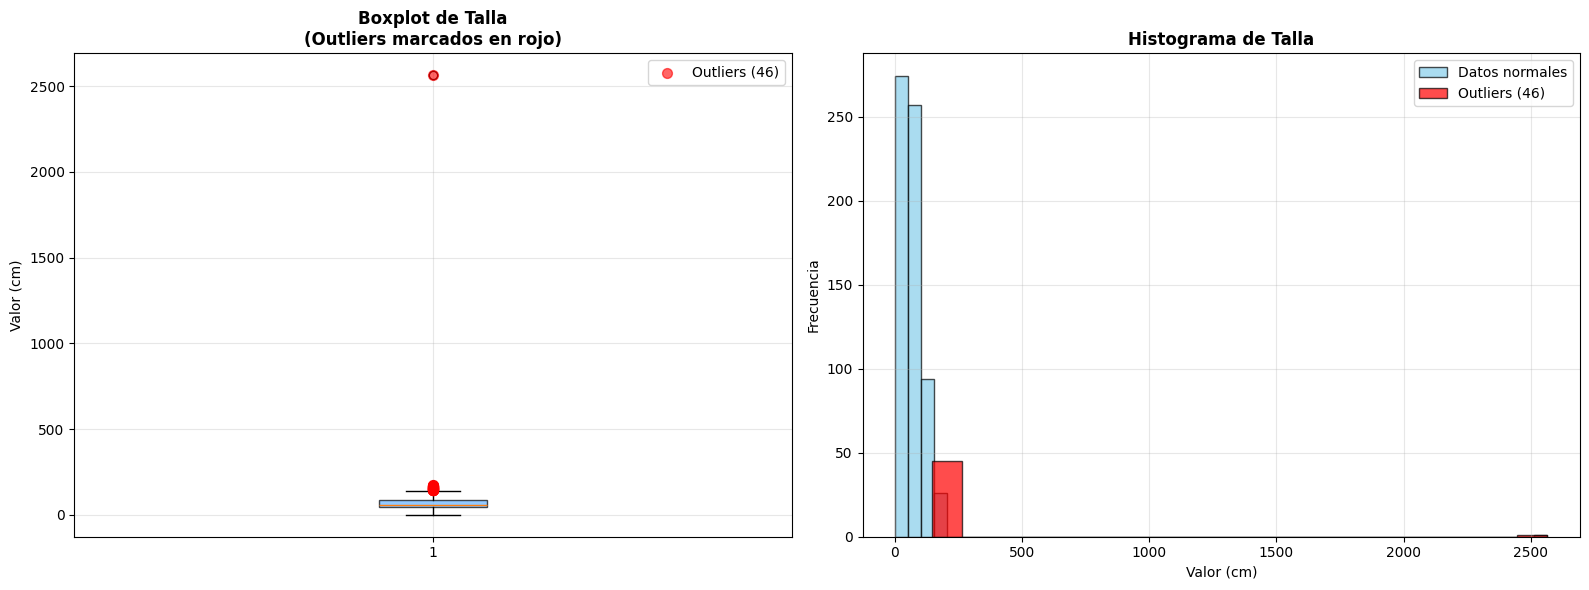


📋 RESUMEN
Variable: Talla
Valores válidos: 652
Outliers (IQR): 46 (7.06%)
Outliers (Z-score): 1 (0.15%)


In [24]:
resultado_outliers_talla = analizar_outliers_variable(
    df_clean,
    var='Talla',
    unidades='cm'
)

**¿Qué se observó?**

Durante el análisis de datos atípicos en la variable `Talla`, se detectaron:

- **48 outliers usando el método IQR** (7.15% de los valores válidos)
- **1 outlier usando el método Z-score** (0.15% de los valores válidos)

**Observaciones:**

Al revisar los valores atípicos, se observó que:

- La **mayoría de los outliers son valores normales** para pacientes pediátricos. Estos corresponden a tallas de niños que están grandes para su edad, pero que siguen siendo valores clínicamente válidos y razonables para pacientes pediátricos (por ejemplo, tallas entre 150-177 cm).

- Sin embargo, se identificó **un valor extremadamente anómalo**: un registro con una talla de **2565 cm**, lo cual es **clínicamente imposible** y no tiene ningún sentido desde el punto de vista médico.

**¿Qué se va a hacer?**

Se va a eliminar cualquier registro donde la `Talla` sea mayor a 250 cm y menor a 15 cm, ya que estos valores son claramente errores de registro y no representan datos válidos para pacientes pediátricos.


In [25]:
print("=" * 70)
print("🗑️  ELIMINACIÓN DE REGISTROS CON TALLA IMPOSIBLE (< 15 cm o > 250 cm)")
print("=" * 70)

# Identificar registros con Talla fuera del rango válido
umbral_talla_min = 15   # Tallas menores a 15 cm son imposibles para pacientes pediátricos
umbral_talla_max = 250  # Tallas mayores a 250 cm son imposibles para pacientes pediátricos

# Contar registros antes de la eliminación
total_antes = len(df_clean)
registros_muy_bajos = df_clean[(df_clean['Talla'] < umbral_talla_min) & df_clean['Talla'].notna()].copy()
registros_muy_altos = df_clean[df_clean['Talla'] > umbral_talla_max].copy()
registros_a_eliminar = df_clean[((df_clean['Talla'] < umbral_talla_min) | (df_clean['Talla'] > umbral_talla_max)) & df_clean['Talla'].notna()].copy()

print(f"\n📊 Análisis de registros a eliminar:")
print(f"   - Total de registros antes de la eliminación: {total_antes}")
print(f"   - Registros con Talla < {umbral_talla_min} cm: {len(registros_muy_bajos)}")
print(f"   - Registros con Talla > {umbral_talla_max} cm: {len(registros_muy_altos)}")
print(f"   - Total de registros a eliminar: {len(registros_a_eliminar)}")

if len(registros_a_eliminar) > 0:
    print(f"\n📋 Registros que serán eliminados:")
    print(f"   {'Índice':<10} {'Talla (cm)':<15} {'Tipo':<20}")
    print(f"   {'-'*45}")

    for idx in registros_a_eliminar.index:
        talla = df_clean.loc[idx, 'Talla']
        if talla < umbral_talla_min:
            tipo = "Muy bajo"
        else:
            tipo = "Muy alto"
        print(f"   {idx:<10} {talla:<15.2f} {tipo:<20}")

    # Eliminar los registros (mantener solo los que están en el rango válido o son NaN)
    df_clean = df_clean[((df_clean['Talla'] >= umbral_talla_min) & (df_clean['Talla'] <= umbral_talla_max)) | df_clean['Talla'].isna()].copy()

    # Contar registros después de la eliminación
    total_despues = len(df_clean)
    registros_eliminados = total_antes - total_despues

    print(f"\n✅ Eliminación completada:")
    print(f"   - Registros eliminados: {registros_eliminados}")
    print(f"   - Total de registros después de la eliminación: {total_despues}")
    print(f"   - Porcentaje de registros eliminados: {registros_eliminados/total_antes:.2%}")

    # Verificar que no queden registros fuera del rango válido
    registros_restantes_bajos = df_clean[(df_clean['Talla'] < umbral_talla_min) & df_clean['Talla'].notna()]
    registros_restantes_altos = df_clean[df_clean['Talla'] > umbral_talla_max]

    if len(registros_restantes_bajos) == 0 and len(registros_restantes_altos) == 0:
        print(f"\n✅ Verificación: No quedan registros con Talla fuera del rango válido ({umbral_talla_min}-{umbral_talla_max} cm)")
    else:
        if len(registros_restantes_bajos) > 0:
            print(f"\n⚠️  Advertencia: Aún hay {len(registros_restantes_bajos)} registros con Talla < {umbral_talla_min} cm")
        if len(registros_restantes_altos) > 0:
            print(f"\n⚠️  Advertencia: Aún hay {len(registros_restantes_altos)} registros con Talla > {umbral_talla_max} cm")
        print(f"   Estos podrían requerir revisión manual")

    # Mostrar estadísticas de Talla después de la eliminación
    talla_despues = df_clean['Talla'].dropna()
    if len(talla_despues) > 0:
        print(f"\n📊 Estadísticas de Talla después de la eliminación:")
        print(f"   - Valores válidos: {len(talla_despues)}")
        print(f"   - Mínimo: {talla_despues.min():.2f} cm")
        print(f"   - Máximo: {talla_despues.max():.2f} cm")
        print(f"   - Media: {talla_despues.mean():.2f} cm")
        print(f"   - Mediana: {talla_despues.median():.2f} cm")
else:
    print(f"\n✅ No se encontraron registros con Talla fuera del rango válido ({umbral_talla_min}-{umbral_talla_max} cm)")
    print(f"   Todos los valores de Talla están en un rango razonable")

print("\n" + "=" * 70)
print("✅ Eliminación de registros con Talla imposible completada")
print("=" * 70)


🗑️  ELIMINACIÓN DE REGISTROS CON TALLA IMPOSIBLE (< 15 cm o > 250 cm)

📊 Análisis de registros a eliminar:
   - Total de registros antes de la eliminación: 945
   - Registros con Talla < 15 cm: 1
   - Registros con Talla > 250 cm: 1
   - Total de registros a eliminar: 2

📋 Registros que serán eliminados:
   Índice     Talla (cm)      Tipo                
   ---------------------------------------------
   296        1.00            Muy bajo            
   642        2565.00         Muy alto            

✅ Eliminación completada:
   - Registros eliminados: 2
   - Total de registros después de la eliminación: 943
   - Porcentaje de registros eliminados: 0.21%

✅ Verificación: No quedan registros con Talla fuera del rango válido (15-250 cm)

📊 Estadísticas de Talla después de la eliminación:
   - Valores válidos: 650
   - Mínimo: 21.00 cm
   - Máximo: 177.00 cm
   - Media: 72.25 cm
   - Mediana: 60.00 cm

✅ Eliminación de registros con Talla imposible completada


##### Imputación de Talla

La matriz de correlaciones mostró una **relación muy fuerte entre la talla y la dosis inicial de cardioplejia** (~0.92). Esta alta correlación tiene sentido clínico, ya que la dosis de cardioplejia se calcula basándose en el tamaño del paciente.

Después de depurar los valores imposibles de talla, podemos aprovechar esa relación clínica para estimar las tallas faltantes a partir de la dosis registrada mediante un modelo de regresión lineal.

In [26]:
print("=" * 70)
print("📊 IMPUTACIÓN DE TALLA CON DOSIS INICIAL CARDIOPLEJIA")
print("=" * 70)

print("\n📋 ESTADO INICIAL:")
print(f"   - Talla: {df_clean['Talla'].notna().sum()} valores presentes, {df_clean['Talla'].isna().sum()} faltantes")
print(f"   - Dosis Inicial Cardioplejia: {df_clean['Dosis Inicial Cardioplejia'].notna().sum()} valores presentes, {df_clean['Dosis Inicial Cardioplejia'].isna().sum()} faltantes")

imputaciones_talla_cardioplejia = 0

# Filtrar datos donde ambas variables están presentes para entrenar el modelo
mask_ambas_presentes_talla = df_clean['Talla'].notna() & df_clean['Dosis Inicial Cardioplejia'].notna()
datos_entrenamiento_talla = df_clean[mask_ambas_presentes_talla][['Talla', 'Dosis Inicial Cardioplejia']].copy()

if len(datos_entrenamiento_talla) > 10:
    correlacion_talla = datos_entrenamiento_talla['Talla'].corr(datos_entrenamiento_talla['Dosis Inicial Cardioplejia'])
    print(f"\n📊 Correlación entre Talla y Dosis Inicial Cardioplejia: {correlacion_talla:.4f}")

    if abs(correlacion_talla) >= 0.9:
        print("   ✅ Correlación MUY ALTA (≥0.9): Excelente para imputación")
        print(f"      Explica aproximadamente el {correlacion_talla**2*100:.1f}% de la variabilidad de Talla")
    elif abs(correlacion_talla) >= 0.7:
        print("   ✅ Correlación ALTA (≥0.7): Apta para imputación")
    elif abs(correlacion_talla) >= 0.5:
        print("   ⚠️  Correlación MODERADA (≥0.5): Usar con precaución")
    else:
        print("   ⚠️  Correlación BAJA (<0.5): No se recomienda imputar")

    if abs(correlacion_talla) > 0.3:
        from sklearn.linear_model import LinearRegression
        from sklearn.metrics import r2_score

        X_train_talla = datos_entrenamiento_talla[['Dosis Inicial Cardioplejia']]
        y_train_talla = datos_entrenamiento_talla['Talla']

        modelo_talla = LinearRegression()
        modelo_talla.fit(X_train_talla, y_train_talla)

        y_pred_train_talla = modelo_talla.predict(X_train_talla)
        r2_talla = r2_score(y_train_talla, y_pred_train_talla)
        mae_talla = np.mean(np.abs(y_train_talla - y_pred_train_talla))

        print("\n📈 Métricas del modelo:")
        print(f"   - R²: {r2_talla:.4f}")
        print(f"   - Error absoluto medio (MAE): {mae_talla:.2f} cm")
        print(f"   - Coeficiente: {modelo_talla.coef_[0]:.4f} cm por unidad de dosis")
        print(f"   - Intercepto: {modelo_talla.intercept_:.2f} cm")

        if modelo_talla.coef_[0] > 0:
            print("   ✅ El modelo tiene sentido clínico: mayor dosis → mayor talla")
        else:
            print("   ⚠️  Advertencia: el modelo sugiere relación inversa, revisar antes de imputar")

        mask_talla_faltante_cardioplejia = df_clean['Talla'].isna() & df_clean['Dosis Inicial Cardioplejia'].notna()

        if mask_talla_faltante_cardioplejia.sum() > 0:
            X_imputar_talla = df_clean.loc[mask_talla_faltante_cardioplejia, ['Dosis Inicial Cardioplejia']]
            talla_imputada = modelo_talla.predict(X_imputar_talla)

            talla_imputada_original = talla_imputada.copy()
            talla_imputada = np.clip(talla_imputada, 30, 200)

            valores_recortados_talla = (talla_imputada_original != talla_imputada).sum()
            if valores_recortados_talla > 0:
                print(f"\n   ⚠️  {valores_recortados_talla} predicciones fueron ajustadas al rango clínico (30-200 cm)")

            df_clean.loc[mask_talla_faltante_cardioplejia, 'Talla'] = talla_imputada
            imputaciones_talla_cardioplejia = mask_talla_faltante_cardioplejia.sum()

            print(f"\n   ✓ Talla imputada para {imputaciones_talla_cardioplejia} registros usando Dosis Inicial Cardioplejia")
            print("   📊 Estadísticas de las tallas imputadas")
            print(f"      - Media: {talla_imputada.mean():.2f} cm")
            print(f"      - Mediana: {np.median(talla_imputada):.2f} cm")
            print(f"      - Rango: {talla_imputada.min():.2f} - {talla_imputada.max():.2f} cm")

            print("\n   📊 Comparación con las tallas reales del entrenamiento:")
            print(f"      - Media real: {y_train_talla.mean():.2f} cm")
            print(f"      - Media imputada: {talla_imputada.mean():.2f} cm")
            print(f"      - Diferencia: {abs(y_train_talla.mean() - talla_imputada.mean()):.2f} cm")
        else:
            print("\n   ℹ️  No se encontraron registros con Dosis Inicial Cardioplejia válida y Talla faltante")
    else:
        print("\n   ⚠️  La correlación es muy baja, no se realizará la imputación por este método")
else:
    print(f"\n⚠️  No hay suficientes registros para entrenar el modelo ({len(datos_entrenamiento_talla)} disponibles)")

print("\n" + "=" * 70)
print("✅ IMPUTACIÓN DE TALLA CON DOSIS COMPLETADA")
print("=" * 70)
print(f"Tallas imputadas usando la dosis inicial: {imputaciones_talla_cardioplejia}")

📊 IMPUTACIÓN DE TALLA CON DOSIS INICIAL CARDIOPLEJIA

📋 ESTADO INICIAL:
   - Talla: 650 valores presentes, 293 faltantes
   - Dosis Inicial Cardioplejia: 661 valores presentes, 282 faltantes

📊 Correlación entre Talla y Dosis Inicial Cardioplejia: 0.9213
   ✅ Correlación MUY ALTA (≥0.9): Excelente para imputación
      Explica aproximadamente el 84.9% de la variabilidad de Talla

📈 Métricas del modelo:
   - R²: 0.8489
   - Error absoluto medio (MAE): 9.29 cm
   - Coeficiente: 0.1369 cm por unidad de dosis
   - Intercepto: 46.44 cm
   ✅ El modelo tiene sentido clínico: mayor dosis → mayor talla

   ✓ Talla imputada para 193 registros usando Dosis Inicial Cardioplejia
   📊 Estadísticas de las tallas imputadas
      - Media: 72.56 cm
      - Mediana: 60.12 cm
      - Rango: 51.91 - 183.32 cm

   📊 Comparación con las tallas reales del entrenamiento:
      - Media real: 78.18 cm
      - Media imputada: 72.56 cm
      - Diferencia: 5.62 cm

✅ IMPUTACIÓN DE TALLA CON DOSIS COMPLETADA
Tallas 

Anteriormente inputamos valores de talla gracias a su alta correlación con la dosis inicial de cardioplejia, ahora tambien ppuede pasar que si tenemos los valores de `IMC` y `Peso`, podemos calcular la `Talla` despejando la fórmula del IMC:

- **Fórmula del IMC**: `IMC = Peso / (Talla/100)²`
- **Despejando Talla**: `Talla = 100 * √(Peso / IMC)`

In [27]:
import numpy as np

print("=" * 70)
print("📊 IMPUTACIÓN DE TALLA CON IMC Y PESO")
print("=" * 70)

print(f"\n📋 ESTADO INICIAL:")
print(f"   - Talla: {df_clean['Talla'].notna().sum()} valores presentes, {df_clean['Talla'].isna().sum()} faltantes")
print(f"   - IMC: {df_clean['IMC'].notna().sum()} valores presentes, {df_clean['IMC'].isna().sum()} faltantes")
print(f"   - Peso: {df_clean['Peso'].notna().sum()} valores presentes, {df_clean['Peso'].isna().sum()} faltantes")

# Identificar registros donde falta Talla pero hay IMC y Peso
mask_talla_faltante = df_clean['Talla'].isna()
mask_tiene_imc_peso = df_clean['IMC'].notna() & df_clean['Peso'].notna()
mask_calcular_talla = mask_talla_faltante & mask_tiene_imc_peso

if mask_calcular_talla.sum() > 0:
    # Calcular Talla: Talla = 100 * sqrt(Peso / IMC)
    df_clean.loc[mask_calcular_talla, 'Talla'] = 100 * np.sqrt(df_clean.loc[mask_calcular_talla, 'Peso'] / df_clean.loc[mask_calcular_talla, 'IMC'])

    print(f"\n✅ Talla calculada para {mask_calcular_talla.sum()} registros")

    # Estadísticas
    talla_calc = df_clean.loc[mask_calcular_talla, 'Talla']
    print(f"\n📊 Estadísticas de Talla calculada:")
    print(f"   - Mínimo: {talla_calc.min():.2f} cm")
    print(f"   - Máximo: {talla_calc.max():.2f} cm")
    print(f"   - Media: {talla_calc.mean():.2f} cm")
    print(f"   - Mediana: {talla_calc.median():.2f} cm")
else:
    print("\n   ℹ️  No se encontraron registros con Talla faltante e IMC/Peso disponibles")

print("\n" + "=" * 70)
print("✅ IMPUTACIÓN DE TALLA CON IMC Y PESO COMPLETADA")
print("=" * 70)

📊 IMPUTACIÓN DE TALLA CON IMC Y PESO

📋 ESTADO INICIAL:
   - Talla: 843 valores presentes, 100 faltantes
   - IMC: 456 valores presentes, 487 faltantes
   - Peso: 854 valores presentes, 89 faltantes

✅ Talla calculada para 2 registros

📊 Estadísticas de Talla calculada:
   - Mínimo: 7.88 cm
   - Máximo: 22.68 cm
   - Media: 15.28 cm
   - Mediana: 15.28 cm

✅ IMPUTACIÓN DE TALLA CON IMC Y PESO COMPLETADA


#### Dosis inicial cardioplejia

📊 DETECCIÓN DE DATOS ATÍPICOS: Dosis Inicial Cardioplejia

🔍 MÉTODO 1: Detección por IQR (Rango Intercuartílico)

📊 Dosis Inicial Cardioplejia:
   - Valores válidos: 661
   - Q1: 70.00
   - Q3: 260.00
   - IQR: 190.00
   - Límite inferior: -215.00
   - Límite superior: 545.00
   - Outliers detectados: 72 (10.89%)

   📋 Valores atípicos (primeros 20):
   Índice     Valor          
   -------------------------
   15         800.00         
   37         700.00         
   38         700.00         
   39         700.00         
   40         700.00         
   41         700.00         
   42         580.00         
   56         940.00         
   69         860.00         
   92         600.00         
   111        560.00         
   116        1000.00        
   117        1000.00        
   181        900.00         
   186        1000.00        
   266        860.00         
   324        680.00         
   325        1000.00        
   341        940.00         
   344        900.

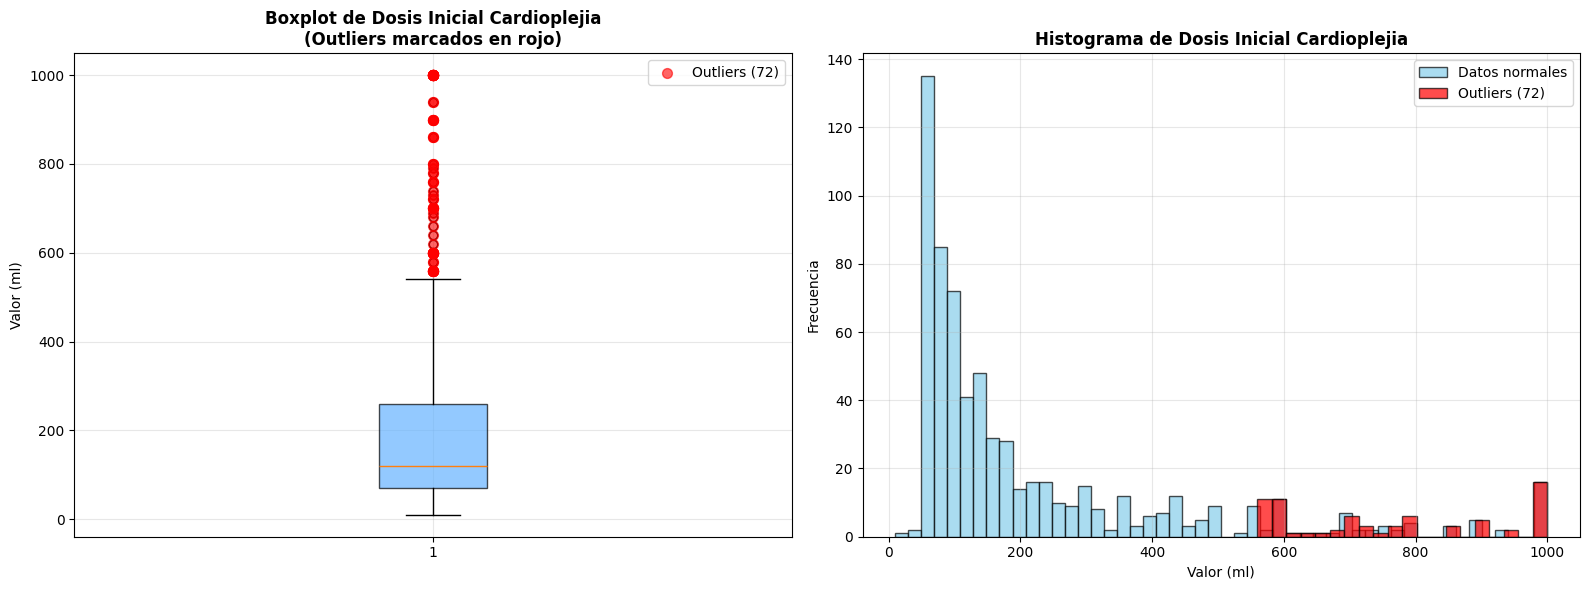


📋 RESUMEN
Variable: Dosis Inicial Cardioplejia
Valores válidos: 661
Outliers (IQR): 72 (10.89%)
Outliers (Z-score): 23 (3.48%)


In [28]:
resultado_outliers_dosis = analizar_outliers_variable(
    df_clean,
    var='Dosis Inicial Cardioplejia',
    unidades='ml'
)

Aunque existan estos outliers, son valores clínicamente válidos. Se observó que los pacientes con dosis inicial de cardioplejia alta son pacientes grandes.

#### Dosis Mantenimiento Cardioplejia y Volumen total cardioplejia

Los registros que no recibieron cardioplejia quedan con dosis inicial, dosis de mantenimiento y volumen total vacíos. Para reflejar clínicamente que no se administró solución, estos valores se reemplazarán por `0`.

In [29]:
print("=" * 70)
print("🩺 Reemplazando dosis cardioplégicas vacías por 0")
print("=" * 70)

cols_dosis = [
    'Dosis Inicial Cardioplejia',
    'Dosis Mantenimiento Cardioplejia',
    'Volumen total cardioplejia '
]

# Resumen inicial
resumen_inicial = df_clean[cols_dosis].isna().sum()
print("\n📋 Valores nulos antes del reemplazo:")
for col, nulos in resumen_inicial.items():
    print(f"   - {col}: {nulos} nulos")

# Reemplazar NaN por 0 en las tres columnas
for col in cols_dosis:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)
    else:
        print(f"   ⚠️  La columna '{col}' no existe en el DataFrame")

# Resumen final
resumen_final = df_copy[cols_dosis].isna().sum()
print("\n📋 Valores nulos después del reemplazo:")
for col, nulos in resumen_final.items():
    print(f"   - {col}: {nulos} nulos")

print("\n✅ Reemplazo completado. Los registros sin cardioplejia quedan explícitamente en 0.")

🩺 Reemplazando dosis cardioplégicas vacías por 0

📋 Valores nulos antes del reemplazo:
   - Dosis Inicial Cardioplejia: 282 nulos
   - Dosis Mantenimiento Cardioplejia: 282 nulos
   - Volumen total cardioplejia : 0 nulos

📋 Valores nulos después del reemplazo:
   - Dosis Inicial Cardioplejia: 284 nulos
   - Dosis Mantenimiento Cardioplejia: 284 nulos
   - Volumen total cardioplejia : 0 nulos

✅ Reemplazo completado. Los registros sin cardioplejia quedan explícitamente en 0.


#### Peso

📊 DETECCIÓN DE DATOS ATÍPICOS: Peso

🔍 MÉTODO 1: Detección por IQR (Rango Intercuartílico)

📊 Peso:
   - Valores válidos: 854
   - Q1: 4.60
   - Q3: 45.00
   - IQR: 40.40
   - Límite inferior: -56.00
   - Límite superior: 105.60
   - Outliers detectados: 186 (21.78%)

   📋 Valores atípicos (primeros 20):
   Índice     Valor          
   -------------------------
   6          2188.00        
   7          2188.00        
   8          2188.00        
   10         3690.00        
   26         764.00         
   29         2911.00        
   30         2911.00        
   31         2911.00        
   48         1570.00        
   49         603.00         
   51         2959.00        
   59         1074.00        
   60         1074.00        
   67         791.00         
   74         2673.00        
   75         2673.00        
   85         2844.00        
   86         2844.00        
   89         767.00         
   93         2624.00        
   94         2624.00        
   95

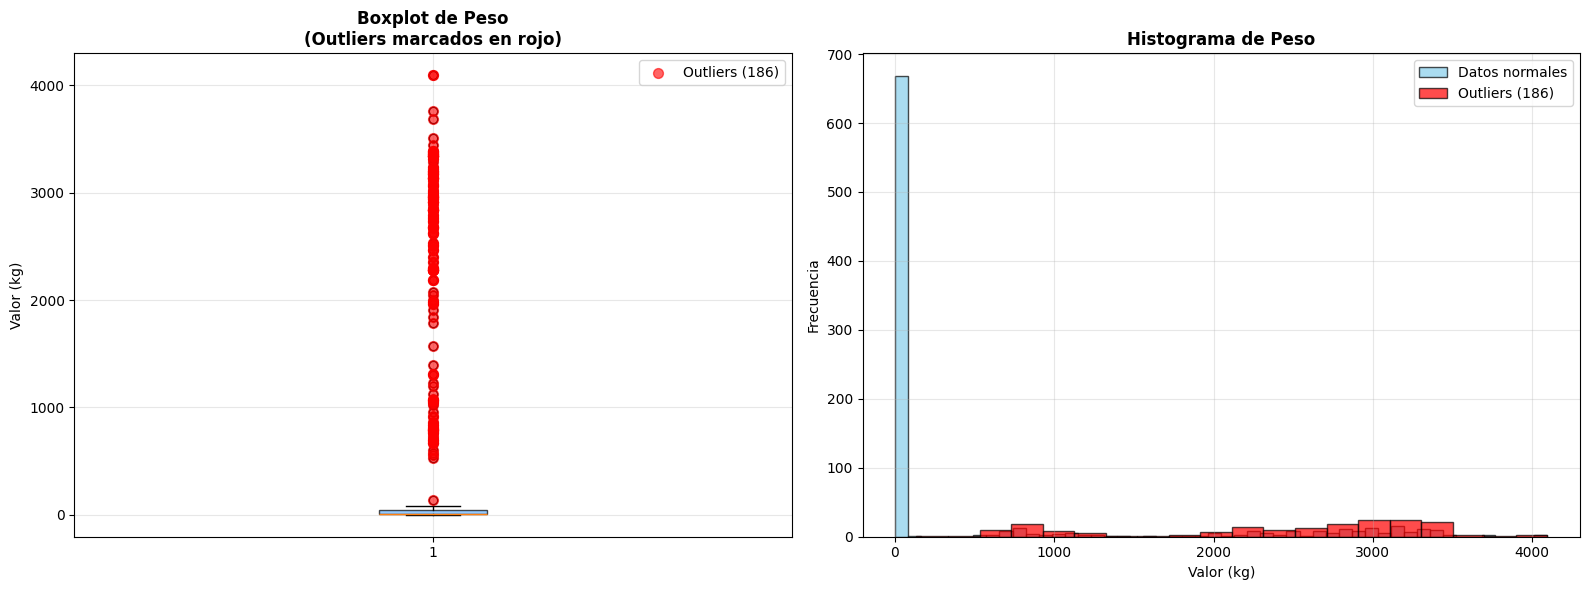


📋 RESUMEN
Variable: Peso
Valores válidos: 854
Outliers (IQR): 186 (21.78%)
Outliers (Z-score): 3 (0.35%)


In [30]:
resultado_outliers_peso = analizar_outliers_variable(
    df_clean,
    var='Peso',
    unidades='kg'
)

**¿Qué se vio?**

Durante el análisis de datos atípicos en la variable `Peso`, se detectaron:

- **198 outliers usando el método IQR** (22.60% de los valores válidos)
- **3 outliers usando el método Z-score** (0.34% de los valores válidos)

**Problema identificado:**

Al revisar los valores atípicos, se observó que muchos de ellos tenían valores **extremadamente altos** (por ejemplo, 2188 kg, 3690 kg, 2911 kg), lo cual es **clínicamente imposible** para pacientes pediátricos. Estos valores sugieren que algunos registros están en **gramos** en lugar de **kilogramos**.

**¿Qué se va a hacer?**

Se va a corregir este problema de unidades convirtiendo todos los valores de Peso mayores a 200 kg de gramos a kilogramos, dividiendo por 1000. Esto permitirá:

- Unificar todas las unidades a kilogramos
- Eliminar los valores atípicos causados por el error de unidades
- Obtener un rango de valores razonable para pacientes pediátricos

In [31]:
print("=" * 70)
print("🔧 CORRECCIÓN DE UNIDADES EN LA VARIABLE PESO")
print("=" * 70)

# Identificar valores que están en gramos (mayores a 200 kg)
umbral_gramos = 200  # Valores mayores a 200 kg probablemente están en gramos

# Crear una copia para no modificar el original directamente
valores_antes = df_clean['Peso'].copy()

# Identificar registros con valores en gramos
mask_gramos = (df_clean['Peso'] > umbral_gramos) & df_clean['Peso'].notna()
registros_gramos = df_clean[mask_gramos].copy()

print(f"\n📊 Análisis de valores de Peso:")
print(f"   - Total de registros con Peso válido: {df_clean['Peso'].notna().sum()}")
print(f"   - Registros con Peso > {umbral_gramos} kg: {mask_gramos.sum()}")
print(f"   - Estos registros probablemente están en gramos")

if mask_gramos.sum() > 0:
    print(f"\n📋 Registros que serán convertidos (primeros 20):")
    print(f"   {'Índice':<10} {'Peso Original (g)':<20} {'Peso Corregido (kg)':<20}")
    print(f"   {'-'*50}")

    for idx in registros_gramos.head(20).index:
        peso_original = df_clean.loc[idx, 'Peso']
        peso_corregido = peso_original / 1000
        print(f"   {idx:<10} {peso_original:<20.2f} {peso_corregido:<20.2f}")

    if mask_gramos.sum() > 20:
        print(f"   ... y {mask_gramos.sum() - 20} más")

    # Convertir de gramos a kilogramos
    df_clean.loc[mask_gramos, 'Peso'] = df_clean.loc[mask_gramos, 'Peso'] / 1000

    print(f"\n✅ Conversión completada:")
    print(f"   - Registros corregidos: {mask_gramos.sum()}")
    print(f"   - Todos los valores de Peso ahora están en kilogramos")

    # Mostrar estadísticas antes y después
    print(f"\n📊 Estadísticas de Peso:")
    print(f"   ANTES de la corrección:")
    print(f"      - Mínimo: {valores_antes.min():.2f} kg")
    print(f"      - Máximo: {valores_antes.max():.2f} kg")
    print(f"      - Media: {valores_antes.mean():.2f} kg")
    print(f"      - Mediana: {valores_antes.median():.2f} kg")

    valores_despues = df_copy['Peso']
    print(f"\n   DESPUÉS de la corrección:")
    print(f"      - Mínimo: {valores_despues.min():.2f} kg")
    print(f"      - Máximo: {valores_despues.max():.2f} kg")
    print(f"      - Media: {valores_despues.mean():.2f} kg")
    print(f"      - Mediana: {valores_despues.median():.2f} kg")

    # Verificar si hay valores que aún parecen incorrectos
    valores_sospechosos = df_clean[(df_clean['Peso'] > 200) & df_clean['Peso'].notna()]
    if len(valores_sospechosos) > 0:
        print(f"\n⚠️  Advertencia: Aún hay {len(valores_sospechosos)} registros con Peso > 200 kg")
        print(f"   Estos podrían requerir revisión manual")
    else:
        print(f"\n✅ Todos los valores de Peso están ahora en un rango razonable (< 200 kg)")

else:
    print(f"\n✅ No se encontraron valores de Peso > {umbral_gramos} kg")
    print(f"   Todos los valores ya están en kilogramos")

print("\n" + "=" * 70)
print("✅ Corrección de unidades completada")
print("=" * 70)

🔧 CORRECCIÓN DE UNIDADES EN LA VARIABLE PESO

📊 Análisis de valores de Peso:
   - Total de registros con Peso válido: 854
   - Registros con Peso > 200 kg: 185
   - Estos registros probablemente están en gramos

📋 Registros que serán convertidos (primeros 20):
   Índice     Peso Original (g)    Peso Corregido (kg) 
   --------------------------------------------------
   6          2188.00              2.19                
   7          2188.00              2.19                
   8          2188.00              2.19                
   10         3690.00              3.69                
   26         764.00               0.76                
   29         2911.00              2.91                
   30         2911.00              2.91                
   31         2911.00              2.91                
   48         1570.00              1.57                
   49         603.00               0.60                
   51         2959.00              2.96                
   59        

**¿Cómo terminó saliendo?**

Después de la corrección de unidades, se obtuvieron los siguientes resultados:

- **198 registros corregidos** (22.6% del total de registros con Peso válido)
- Todos los valores de Peso ahora están en **kilogramos**
- El rango de valores ahora es razonable para pacientes pediátricos:
  - **Antes**: Mínimo 0.70 kg, Máximo 4096.00 kg, Media 524.15 kg
  - **Después**: Mínimo 0.14 kg, Máximo 80.00 kg, Media 9.65 kg

Después de esta corrección, **aún pueden existir outliers** en la variable Peso, pero estos ya **no son causados por el problema de gramos a kilogramos**. Los outliers que quedan son valores clínicamente válidos pero extremos (por ejemplo, pacientes con sobrepeso u obesidad pediátrica), y por lo tanto son **correctos** y no deben ser eliminados.


#### IMC

📊 DETECCIÓN DE DATOS ATÍPICOS: IMC

🔍 MÉTODO 1: Detección por IQR (Rango Intercuartílico)

📊 IMC:
   - Valores válidos: 456
   - Q1: 12.80
   - Q3: 16.15
   - IQR: 3.35
   - Límite inferior: 7.78
   - Límite superior: 21.17
   - Outliers detectados: 26 (5.70%)

   📋 Valores atípicos (primeros 20):
   Índice     Valor          
   -------------------------
   186        26.89          
   217        24.85          
   317        28.00          
   384        50.15          
   494        322.07         
   536        26.46          
   556        446.28         
   566        272.11         
   571        270.27         
   620        26.96          
   685        24.52          
   702        24.77          
   735        27.59          
   741        21.32          
   753        6.79           
   754        22.50          
   772        22.18          
   788        22.42          
   840        28.37          
   876        22.84          
   889        21.19          
   895      

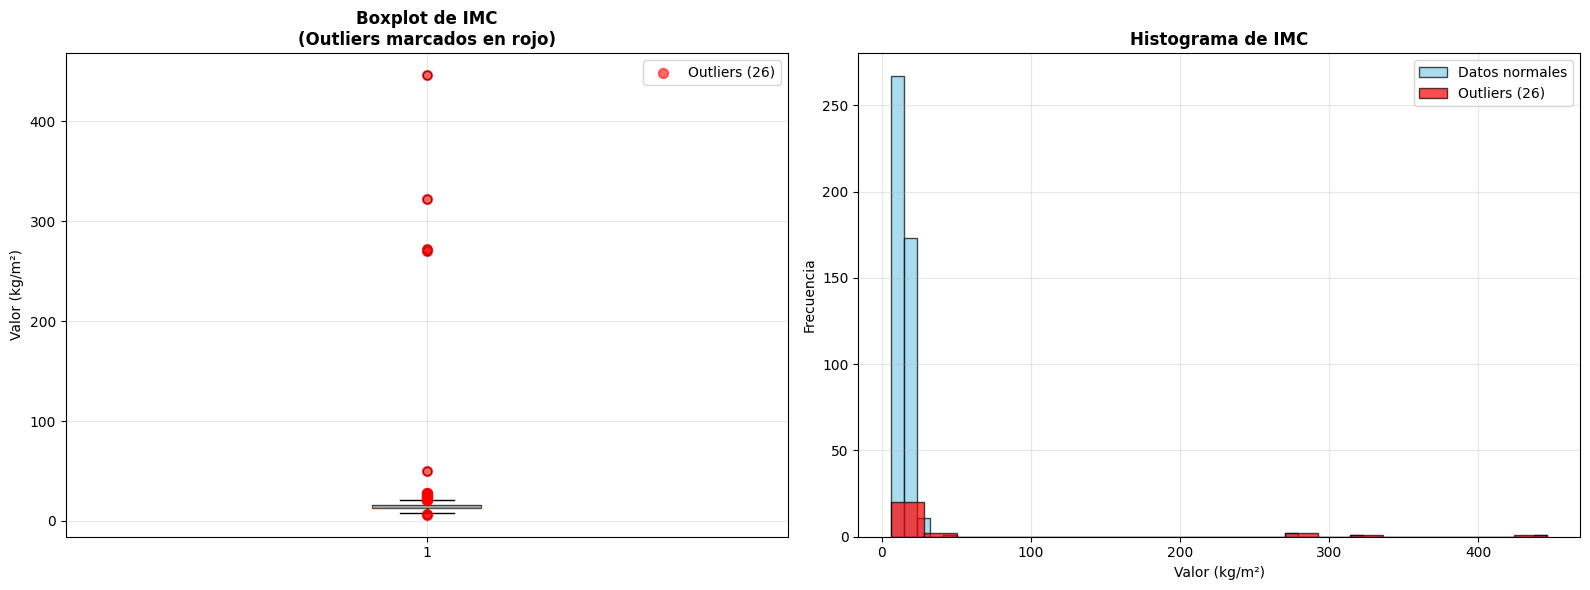


📋 RESUMEN
Variable: IMC
Valores válidos: 456
Outliers (IQR): 26 (5.70%)
Outliers (Z-score): 4 (0.88%)


In [32]:
resultado_outliers_imc = analizar_outliers_variable(
    df_clean,
    var='IMC',
    unidades='kg/m²'
)


Se identificaron valores de IMC mayores a 100, los cuales son **clínicamente imposibles** y representan errores de registro. En lugar de eliminar estos registros, se convertirán los valores de IMC > 100 a `NaN` (nulos), de manera que puedan ser recalculados correctamente en el siguiente paso utilizando la fórmula del IMC a partir de Peso y Talla.

In [33]:
print("=" * 70)
print("🔧 Conversión de IMC > 100 a nulos")
print("=" * 70)

umbral_imc = 100  # IMC mayor a 100 es clínicamente imposible

# Contar valores antes de la conversión
imc_antes = df_clean['IMC'].copy()
valores_imc_altos = (df_clean['IMC'] > umbral_imc) & df_clean['IMC'].notna()
cantidad_outliers = valores_imc_altos.sum()

print(f"\n📊 Análisis de IMC:")
print(f"   - Total de valores válidos de IMC: {df_clean['IMC'].notna().sum()}")
print(f"   - Valores de IMC > {umbral_imc}: {cantidad_outliers}")

if cantidad_outliers > 0:
    print(f"\n📋 Registros con IMC > {umbral_imc} (primeros 20):")
    print(f"   {'Índice':<10} {'IMC':<15}")
    print(f"   {'-'*25}")

    registros_outliers = df_clean[valores_imc_altos]
    for idx in registros_outliers.head(20).index:
        imc_valor = df_clean.loc[idx, 'IMC']
        print(f"   {idx:<10} {imc_valor:<15.2f}")

    if cantidad_outliers > 20:
        print(f"   ... y {cantidad_outliers - 20} más")

    # Convertir IMC > 100 a NaN
    df_clean.loc[valores_imc_altos, 'IMC'] = np.nan

    print(f"\n✅ Conversión completada:")
    print(f"   - Valores convertidos a NaN: {cantidad_outliers}")
    print(f"   - IMC válidos después: {df_clean['IMC'].notna().sum()}")
    print(f"   - IMC nulos después: {df_clean['IMC'].isna().sum()}")
else:
    print(f"\n✅ No se encontraron valores de IMC > {umbral_imc}")

print("\n" + "=" * 70)
print("✅ Conversión de outliers de IMC completada")
print("=" * 70)

🔧 Conversión de IMC > 100 a nulos

📊 Análisis de IMC:
   - Total de valores válidos de IMC: 456
   - Valores de IMC > 100: 4

📋 Registros con IMC > 100 (primeros 20):
   Índice     IMC            
   -------------------------
   494        322.07         
   556        446.28         
   566        272.11         
   571        270.27         

✅ Conversión completada:
   - Valores convertidos a NaN: 4
   - IMC válidos después: 452
   - IMC nulos después: 491

✅ Conversión de outliers de IMC completada


A continuación se calculará el IMC para aquellos registros que cuenten con `Peso` y `Talla` válidos y tengan `IMC` faltante.

In [34]:
print("=" * 70)
print("🧮 CÁLCULO DE IMC CUANDO HAY PESO Y TALLA")
print("=" * 70)

mask_imc_faltante = df_clean['IMC'].isna()
mask_tiene_peso_talla = df_clean['Peso'].notna() & df_clean['Talla'].notna()
mask_calcular_imc = mask_imc_faltante & mask_tiene_peso_talla

if mask_calcular_imc.sum() > 0:
    df_clean.loc[mask_calcular_imc, 'IMC'] = df_clean.loc[mask_calcular_imc, 'Peso'] / ((df_clean.loc[mask_calcular_imc, 'Talla'] / 100) ** 2)
    print(f"   ✓ IMC calculado para {mask_calcular_imc.sum()} registros")

    # Estadísticas rápidas
    imc_calc = df_clean.loc[mask_calcular_imc, 'IMC']
    print("\n📊 Estadísticas de IMC calculado:")
    print(f"   - Mínimo: {imc_calc.min():.2f}")
    print(f"   - Máximo: {imc_calc.max():.2f}")
    print(f"   - Media: {imc_calc.mean():.2f}")
    print(f"   - Mediana: {imc_calc.median():.2f}")
else:
    print("   ℹ️  No se encontraron registros con IMC faltante y Peso/Talla disponibles")


🧮 CÁLCULO DE IMC CUANDO HAY PESO Y TALLA
   ✓ IMC calculado para 344 registros

📊 Estadísticas de IMC calculado:
   - Mínimo: 5.79
   - Máximo: 446.28
   - Media: 17.32
   - Mediana: 12.87


Después de haber realizado todas las imputaciones posibles de IMC (usando Peso y Talla, y otras relaciones), los registros que aún tienen IMC nulo no pueden ser calculados porque no disponen de la información necesaria (Peso y/o Talla) para realizar el cálculo.

Dado que no es posible calcular ni el Peso, ni la Talla, ni el IMC para estos registros, y estas son variables fundamentales para el análisis, estos registros serán eliminados del dataset.

In [35]:
print("=" * 70)
print("🗑️  ELIMINACIÓN DE REGISTROS CON IMC FALTANTE")
print("=" * 70)

# Contar registros antes de la eliminación
total_antes = len(df_clean)
registros_imc_faltante = df_clean[df_clean['IMC'].isna()].copy()

print(f"\n📊 Análisis de registros a eliminar:")
print(f"   - Total de registros antes de la eliminación: {total_antes}")
print(f"   - Registros con IMC faltante: {len(registros_imc_faltante)}")
print(f"   - Porcentaje de registros a eliminar: {len(registros_imc_faltante)/total_antes*100:.2f}%")

if len(registros_imc_faltante) > 0:
    # Eliminar los registros con IMC faltante
    df_clean = df_clean[df_clean['IMC'].notna()].copy()

    # Contar registros después de la eliminación
    total_despues = len(df_clean)
    registros_eliminados = total_antes - total_despues

    print(f"\n✅ Eliminación completada:")
    print(f"   - Registros eliminados: {registros_eliminados}")
    print(f"   - Total de registros después de la eliminación: {total_despues}")
    print(f"   - Porcentaje de registros eliminados: {registros_eliminados/total_antes*100:.2f}%")

    # Verificar que no queden registros con IMC faltante
    registros_restantes_imc_faltante = df_clean[df_clean['IMC'].isna()]

    if len(registros_restantes_imc_faltante) == 0:
        print(f"\n✅ Verificación: No quedan registros con IMC faltante")
    else:
        print(f"\n⚠️  Advertencia: Aún hay {len(registros_restantes_imc_faltante)} registros con IMC faltante")
        print(f"   Estos podrían requerir revisión manual")

    # Mostrar estadísticas de IMC después de la eliminación
    imc_despues = df_clean['IMC'].dropna()
    if len(imc_despues) > 0:
        print(f"\n📊 Estadísticas de IMC después de la eliminación:")
        print(f"   - Valores válidos: {len(imc_despues)}")
        print(f"   - Mínimo: {imc_despues.min():.2f} kg/m²")
        print(f"   - Máximo: {imc_despues.max():.2f} kg/m²")
        print(f"   - Media: {imc_despues.mean():.2f} kg/m²")
        print(f"   - Mediana: {imc_despues.median():.2f} kg/m²")
else:
    print(f"\n✅ No se encontraron registros con IMC faltante")
    print(f"   Todos los registros tienen IMC válido")

print("\n" + "=" * 70)
print("✅ Eliminación de registros con IMC faltante completada")
print("=" * 70)

🗑️  ELIMINACIÓN DE REGISTROS CON IMC FALTANTE

📊 Análisis de registros a eliminar:
   - Total de registros antes de la eliminación: 943
   - Registros con IMC faltante: 147
   - Porcentaje de registros a eliminar: 15.59%

✅ Eliminación completada:
   - Registros eliminados: 147
   - Total de registros después de la eliminación: 796
   - Porcentaje de registros eliminados: 15.59%

✅ Verificación: No quedan registros con IMC faltante

📊 Estadísticas de IMC después de la eliminación:
   - Valores válidos: 796
   - Mínimo: 5.79 kg/m²
   - Máximo: 446.28 kg/m²
   - Media: 15.89 kg/m²
   - Mediana: 13.83 kg/m²

✅ Eliminación de registros con IMC faltante completada


#### Paro circulatorio Hora total

Se trabajará en la variable `Paro circulatorio Hora total`. Los valores nulos se reemplazarán por `0`, ya que esta variable indica el tiempo total en horas que duró el arresto circulatorio. Si no hay valor registrado, significa que no hubo arresto circulatorio durante el procedimiento.

In [36]:
print("=" * 70)
print("🩺 Reemplazando valores nulos en Paro circulatorio Hora total por 0")
print("=" * 70)

var_paro = 'Paro Circulatorio Hora Total'

# Verificar si la variable existe en el DataFrame
if var_paro in df_clean.columns:
    # Resumen inicial
    nulos_antes = df_clean[var_paro].isna().sum()
    valores_validos_antes = df_clean[var_paro].notna().sum()

    print(f"\n📋 Estado inicial:")
    print(f"   - Valores válidos: {valores_validos_antes}")
    print(f"   - Valores nulos: {nulos_antes}")

    # Reemplazar NaN por 0
    df_clean[var_paro] = df_clean[var_paro].fillna(0)

    # Resumen final
    nulos_despues = df_clean[var_paro].isna().sum()
    valores_cero = (df_clean[var_paro] == 0).sum()

    print(f"\n📋 Estado después del reemplazo:")
    print(f"   - Valores nulos: {nulos_despues}")
    print(f"   - Valores iguales a 0: {valores_cero}")
    print(f"   - Valores reemplazados: {nulos_antes - nulos_despues}")

    print(f"\n✅ Reemplazo completado. Los registros sin arresto circulatorio quedan explícitamente en 0.")
else:
    print(f"\n⚠️  La variable '{var_paro}' no existe en el DataFrame")
    print(f"   Variables disponibles que contienen 'Paro':")
    variables_paro = [col for col in df_clean.columns if 'Paro' in col or 'paro' in col]
    for var in variables_paro:
        print(f"   - {var}")

🩺 Reemplazando valores nulos en Paro circulatorio Hora total por 0

📋 Estado inicial:
   - Valores válidos: 669
   - Valores nulos: 127

📋 Estado después del reemplazo:
   - Valores nulos: 0
   - Valores iguales a 0: 719
   - Valores reemplazados: 127

✅ Reemplazo completado. Los registros sin arresto circulatorio quedan explícitamente en 0.


#### Isquemia Hora total

Se trabajará en la variable `Isquemia Hora Total`. Los valores nulos se reemplazarán por `0`, ya que esta variable indica el tiempo total en horas que la orta estuvo pinzada. Si no hay valor registrado, significa que no hubo pinzamiento aortico durante el procedimiento.

In [37]:
print("=" * 70)
print("🩺 Reemplazando valores nulos en Isquemia Hora Total por 0")
print("=" * 70)

var_isquemia = 'Isquemia Hora Total'

# Verificar si la variable existe en el DataFrame
if var_isquemia in df_clean.columns:
    # Resumen inicial
    nulos_antes = df_clean[var_isquemia].isna().sum()
    valores_validos_antes = df_clean[var_isquemia].notna().sum()

    print(f"\n📋 Estado inicial:")
    print(f"   - Valores válidos: {valores_validos_antes}")
    print(f"   - Valores nulos: {nulos_antes}")

    # Reemplazar NaN por 0
    df_clean[var_isquemia] = df_clean[var_isquemia].fillna(0)

    # Resumen final
    nulos_despues = df_clean[var_isquemia].isna().sum()
    valores_cero = (df_clean[var_isquemia] == 0).sum()

    print(f"\n📋 Estado después del reemplazo:")
    print(f"   - Valores nulos: {nulos_despues}")
    print(f"   - Valores iguales a 0: {valores_cero}")
    print(f"   - Valores reemplazados: {nulos_antes - nulos_despues}")

    print(f"\n✅ Reemplazo completado. Los registros sin pinzamiento aórtico quedan explícitamente en 0.")
else:
    print(f"\n⚠️  La variable '{var_isquemia}' no existe en el DataFrame")
    print(f"   Variables disponibles que contienen 'Isquemia':")
    variables_isquemia = [col for col in df_clean.columns if 'Isquemia' in col or 'isquemia' in col]
    for var in variables_isquemia:
        print(f"   - {var}")

🩺 Reemplazando valores nulos en Isquemia Hora Total por 0

📋 Estado inicial:
   - Valores válidos: 697
   - Valores nulos: 99

📋 Estado después del reemplazo:
   - Valores nulos: 0
   - Valores iguales a 0: 175
   - Valores reemplazados: 99

✅ Reemplazo completado. Los registros sin pinzamiento aórtico quedan explícitamente en 0.


#### Bomba hora total

Se trabajará en la variable `Bomba Hora Total`. Los valores nulos se reemplazarán por `0`, ya que esta variable indica el tiempo total en horas que el paciente estuvo conectado a la máquina de CEC. Si no hay valor registrado, significa que no se utilizó la maquina de CEC(Circulación Extracorpórea)

In [38]:
print("=" * 70)
print("🩺 Reemplazando valores nulos en Bomba Hora Total por 0")
print("=" * 70)

var_bomba = 'Bomba Hora Total'

# Verificar si la variable existe en el DataFrame
if var_bomba in df_clean.columns:
    # Resumen inicial
    nulos_antes = df_clean[var_bomba].isna().sum()
    valores_validos_antes = df_clean[var_bomba].notna().sum()

    print(f"\n📋 Estado inicial:")
    print(f"   - Valores válidos: {valores_validos_antes}")
    print(f"   - Valores nulos: {nulos_antes}")

    # Reemplazar NaN por 0
    df_clean[var_bomba] = df_clean[var_bomba].fillna(0)

    # Resumen final
    nulos_despues = df_clean[var_bomba].isna().sum()
    valores_cero = (df_clean[var_bomba] == 0).sum()

    print(f"\n📋 Estado después del reemplazo:")
    print(f"   - Valores nulos: {nulos_despues}")
    print(f"   - Valores iguales a 0: {valores_cero}")
    print(f"   - Valores reemplazados: {nulos_antes - nulos_despues}")

    print(f"\n✅ Reemplazo completado. Los registros sin uso de máquina de CEC quedan explícitamente en 0.")
else:
    print(f"\n⚠️  La variable '{var_bomba}' no existe en el DataFrame")
    print(f"   Variables disponibles que contienen 'Bomba':")
    variables_bomba = [col for col in df_clean.columns if 'Bomba' in col or 'bomba' in col]
    for var in variables_bomba:
        print(f"   - {var}")

🩺 Reemplazando valores nulos en Bomba Hora Total por 0

📋 Estado inicial:
   - Valores válidos: 707
   - Valores nulos: 89

📋 Estado después del reemplazo:
   - Valores nulos: 0
   - Valores iguales a 0: 129
   - Valores reemplazados: 89

✅ Reemplazo completado. Los registros sin uso de máquina de CEC quedan explícitamente en 0.


#### Días ECMO

Se trabajará en la variable `Días ECMO`. Los valores nulos se reemplazarán por `0`, ya que esta variable indica el número de días que el paciente requirió ECMO (Oxigenación por Membrana Extracorpórea). Si no hay valor registrado, significa que el paciente **no requirió ECMO** durante su estancia, por lo que se asignará el valor `0` para reflejar esta situación clínica.

In [39]:
print(f"Cantidad de nulos en Días ECMO: {df_clean['Días ECMO'].isna().sum()}")

Cantidad de nulos en Días ECMO: 30


In [40]:
print("=" * 70)
print("🩺 Reemplazando valores nulos en Días ECMO por 0")
print("=" * 70)

var_ecmo = 'Días ECMO'

# Verificar si la variable existe en el DataFrame
if var_ecmo in df_clean.columns:
    # Resumen inicial
    nulos_antes = df_clean[var_ecmo].isna().sum()
    valores_validos_antes = df_clean[var_ecmo].notna().sum()

    print(f"\n📋 Estado inicial:")
    print(f"   - Valores válidos: {valores_validos_antes}")
    print(f"   - Valores nulos: {nulos_antes}")

    # Reemplazar NaN por 0
    df_clean[var_ecmo] = df_clean[var_ecmo].fillna(0)

    # Resumen final
    nulos_despues = df_clean[var_ecmo].isna().sum()
    valores_cero = (df_clean[var_ecmo] == 0).sum()

    print(f"\n📋 Estado después del reemplazo:")
    print(f"   - Valores nulos: {nulos_despues}")
    print(f"   - Valores iguales a 0: {valores_cero}")
    print(f"   - Valores reemplazados: {nulos_antes - nulos_despues}")

    print(f"\n✅ Reemplazo completado. Los registros sin ECMO quedan explícitamente en 0.")
else:
    print(f"\n⚠️  La variable '{var_ecmo}' no existe en el DataFrame")
    print(f"   Variables disponibles que contienen 'ECMO':")
    variables_ecmo = [col for col in df_clean.columns if 'ECMO' in col or 'ecmo' in col]
    for var in variables_ecmo:
        print(f"   - {var}")

🩺 Reemplazando valores nulos en Días ECMO por 0

📋 Estado inicial:
   - Valores válidos: 766
   - Valores nulos: 30

📋 Estado después del reemplazo:
   - Valores nulos: 0
   - Valores iguales a 0: 689
   - Valores reemplazados: 30

✅ Reemplazo completado. Los registros sin ECMO quedan explícitamente en 0.


#### EDAD_AÑOS

Aquellos registros que no tienen edad disponible serán eliminados del dataset. La edad es una variable fundamental para el análisis, por lo que no es posible trabajar con registros que carecen de esta información.

In [41]:
# Eliminar registros con EDAD_AÑOS faltante
total_antes = len(df_clean)
df_clean = df_clean[df_clean['EDAD_AÑOS'].notna()].copy()
total_despues = len(df_clean)

print(f"Registros eliminados: {total_antes - total_despues}")
print(f"Total de registros después: {total_despues}")

Registros eliminados: 14
Total de registros después: 782


In [42]:
df_clean.describe()

,EPISODIO,Peso,Talla,IMC,Fecha de Admisión,Fecha Ingreso UCIPCV,Días des de ingreso hasta UCI,Fecha Egreso Vivo,Estancia UCIPCV,Estancia Total Hosp,...,Volumen total cardioplejia,INICIO CIRUJANO,Tiempo quirurgico,INICIO ANESTESIA,TIEMPO QUIROFANO,Fecha Intubación,Fecha Extubación,Tiempo de Ventilación Mecanica,Días ECMO,EDAD_AÑOS
count,7.820000e+02,782.000000,782.000000,782.000000,782,744,744.000000,740,714.000000,782.000000,...,782.000000,673,742.000000,673,673.000000,539,468,782.000000,782.000000,782.000000
mean,9.543412e+06,10.178899,72.123291,15.940364,2022-06-01 12:34:59.232736512,2022-06-27 13:13:32.903225856,3.779570,2022-07-31 12:53:40.495945984,25.774732,38.673789,...,215.757033,2022-05-04 03:37:16.539375872,3.902291,2022-05-04 02:11:12.208023808,6.126880,2022-03-30 03:31:03.450834944,2022-04-13 16:36:55.384615424,61.347826,0.910486,2.240048
min,6.829110e+06,0.528000,7.880248,5.785640,2019-11-28 00:00:00,2019-11-29 00:00:00,-82.000000,2020-01-12 00:00:00,0.484537,0.912488,...,0.000000,2020-01-02 08:00:59,0.014444,2020-01-02 07:50:42,0.658056,2019-12-27 00:00:00,2020-01-10 00:00:00,0.000000,0.000000,0.002738
25%,7.735334e+06,3.037250,49.500000,11.902745,2020-12-17 00:00:00,2021-01-11 06:00:00,0.000000,2021-02-25 06:00:00,4.796808,8.753087,...,60.000000,2020-12-10 09:20:00,1.537361,2020-12-10 07:30:00,4.247778,2020-11-30 00:00:00,2020-12-01 18:00:00,0.000000,0.000000,0.073922
50%,9.385490e+06,5.300000,60.000000,13.845000,2022-05-09 00:00:00,2022-06-23 00:00:00,0.000000,2022-07-11 00:00:00,11.936551,21.648767,...,120.000000,2022-04-11 15:40:00,2.802361,2022-04-11 14:15:00,5.583333,2022-01-23 00:00:00,2022-02-02 00:00:00,0.000000,0.000000,0.416667
75%,1.117205e+07,11.950000,82.606634,15.999405,2023-10-06 00:00:00,2023-10-23 06:00:00,2.000000,2023-11-15 00:00:00,32.523383,51.915139,...,250.000000,2023-07-05 14:30:26,4.604583,2023-07-05 13:05:00,7.500000,2023-07-11 12:00:00,2023-08-24 18:00:00,20.000000,0.000000,2.000000
max,1.321146e+07,135.000000,183.324519,446.280992,2025-04-24 00:00:00,2025-04-29 00:00:00,131.000000,2025-07-06 06:23:25,296.389583,345.121273,...,2000.000000,2025-01-15 09:50:00,23.966667,2025-01-15 08:00:00,17.166667,2025-04-28 00:00:00,2025-04-28 00:00:00,1449.000000,20.000000,17.000000
std,1.870033e+06,12.933308,33.243595,23.469204,NaN,NaN,12.131283,NaN,37.746377,46.764864,...,294.221758,NaN,4.158641,NaN,2.817480,NaN,NaN,174.453078,2.812933,3.957104


# Tratamiento de imputación de las variables: Estancia Total Hosp, Estancia UCIPCV, Fecha Egreso Vivo, Días des de ingreso hasta UCI , Fecha Ingreso UCIPCV, Fecha de Admisión


Para empezar, se verifica los registros nulos existentes en las
variables

In [43]:
# Convertir fechas
fechas = ["Fecha de Admisión", "Fecha Ingreso UCIPCV", "Fecha Egreso Vivo"]
for col in fechas:
    df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

# Convertir estancias numéricas
df_clean["Estancia Total Hosp"] = pd.to_numeric(df_clean["Estancia Total Hosp"], errors="coerce")
df_clean["Estancia UCIPCV"] = pd.to_numeric(df_clean["Estancia UCIPCV"], errors="coerce")
df_clean["Días des de ingreso hasta UCI "] = pd.to_numeric(df_clean["Días des de ingreso hasta UCI "], errors="coerce")


In [44]:
vars_clave = [
    "Fecha de Admisión",
    "Fecha Ingreso UCIPCV",
    "Fecha Egreso Vivo",
    "Estancia Total Hosp",
    "Estancia UCIPCV",
    "Días des de ingreso hasta UCI "
]

nulos = df_clean[vars_clave].isnull().sum().to_frame(name="Nulos")
nulos["% Nulos"] = 100 * nulos["Nulos"] / len(df_clean)

print("\n=== NULOS EN VARIABLES CLAVE ===")
print(nulos)



=== NULOS EN VARIABLES CLAVE ===
                                Nulos   % Nulos
Fecha de Admisión                   0  0.000000
Fecha Ingreso UCIPCV               38  4.859335
Fecha Egreso Vivo                  42  5.370844
Estancia Total Hosp                 0  0.000000
Estancia UCIPCV                    68  8.695652
Días des de ingreso hasta UCI      38  4.859335


Como podemos ver aquí, el porcentaje de nulos en Fecha de Admisión y Estancia total Hosp, lo que facilita el cálculo de todos los campos "Fecha egreso vivo"

Pero queremos confirmar con los registro que cuentan con las tres variables, si efectivamente la fecha de estancia total en efecto es igual a la diferencia entre la fecha de ingreso y admisión

In [45]:
# Convertir tipos
df_clean["Fecha de Admisión"] = pd.to_datetime(df_clean["Fecha de Admisión"], errors="coerce")
df_clean["Fecha Egreso Vivo"] = pd.to_datetime(df_clean["Fecha Egreso Vivo"], errors="coerce")
df_clean["Estancia Total Hosp"] = pd.to_numeric(df_clean["Estancia Total Hosp"], errors="coerce")

# 1. Filtrar registros completos
mask_A = (
    df_clean["Fecha de Admisión"].notnull() &
    df_clean["Fecha Egreso Vivo"].notnull() &
    df_clean["Estancia Total Hosp"].notnull()
)

df_A = df_clean.loc[mask_A].copy()

# 2. Calcular estancia calculada por resta de fechas
df_A["Estancia_Total_Calc"] = (
    df_A["Fecha Egreso Vivo"] - df_A["Fecha de Admisión"]
).dt.days

# 3. Calcular coherencia con tolerancia < 1 día
df_A["Diferencia"] = abs(df_A["Estancia_Total_Calc"] - df_A["Estancia Total Hosp"])
df_A["Coincide"] = df_A["Diferencia"] < 1

# 4. Porcentaje de coincidencias
coherencia = df_A["Coincide"].mean() * 100
print(f"Coherencia con tolerancia < 1 día: {coherencia:.2f}%\n")

# 5. Mostrar primeros casos con cálculo
print(df_A[[
    "Fecha de Admisión",
    "Fecha Egreso Vivo",
    "Estancia Total Hosp",
    "Estancia_Total_Calc",
    "Diferencia",
    "Coincide"
]].head(12))


Coherencia con tolerancia < 1 día: 99.86%

   Fecha de Admisión Fecha Egreso Vivo  Estancia Total Hosp  \
2         2020-01-14        2020-01-17             3.096273   
3         2020-01-10        2020-01-14             3.929977   
4         2020-01-13        2020-01-21             8.114259   
5         2020-01-13        2020-01-21             8.114259   
6         2019-11-28        2020-02-03            66.764583   
7         2019-11-28        2020-02-03            66.764583   
8         2019-11-28        2020-02-03            66.764583   
9         2020-01-09        2020-01-12             3.157083   
10        2019-12-13        2020-01-27            44.740995   
11        2019-12-28        2020-01-20            22.873958   
13        2020-02-05        2020-02-09             4.111019   
20        2020-02-03        2020-02-07             4.002060   

    Estancia_Total_Calc  Diferencia  Coincide  
2                     3    0.096273      True  
3                     4    0.070023      

Para calcular la coincidencia, tomamos la diferencia entre la variable "Estancia Total Hosp" y la estancia obtenida al restar la fecha de admisión y la fecha de egreso. Consideramos que coinciden si esa diferencia es menor o igual a 1. ¿Por qué? Porque en "Estancia Total Hosp" los valores incluyen decimales (ya que probablemente se calcularon con horas), mientras que nuestra resta entre fechas solo devuelve días completos.
Por ejemplo, si un paciente entra muy temprano un día y sale muy tarde al día siguiente, la estancia total podría registrarse como 1.9 días, pero nuestra resta daría 1 día, lo que genera una diferencia que no significa un error real.
Con este criterio, encontramos que el 99.87% de los datos coinciden.

In [46]:
##calcular los datos que no coinciden para analizarlos
df_A["noCoincide"] = df_A["Diferencia"] > 1

df_noCoincide = df_A[df_A["noCoincide"] == True]

# 4. Porcentaje de coincidencias
coherencia = df_A["noCoincide"].mean() * 100
print(f"Incoherencia con tolerancia < 1 día: {coherencia:.2f}%\n")


# 5. Mostrar primeros casos con cálculo
print(df_noCoincide[[
    "Fecha de Admisión",
    "Fecha Egreso Vivo",
    "Estancia Total Hosp",
    "Estancia_Total_Calc",
    "Diferencia",
    "noCoincide"
]].head(10))


Incoherencia con tolerancia < 1 día: 0.14%

    Fecha de Admisión Fecha Egreso Vivo  Estancia Total Hosp  \
448        2022-01-15        2022-01-26             8.805856   

     Estancia_Total_Calc  Diferencia  noCoincide  
448                   11    2.194144        True  


Al hacer la validación de coherencia entre la Estancia Total Hosp registrada y la que calculamos con fechas, encontramos que solo un registro (0.13%) no coincide, y es porque la estancia calculada supera la registrada por más de un día.
Ese caso lo consideramos un dato atípico, ya que el resto del dataset se comporta bien y mantiene coherencia.

Como ya validamos que las estancias tienen sentido, podemos usar la Estancia Total Hosp (redondeada) para imputar las fechas de egreso cuando falten.
¿Por qué redondeada? Porque los decimales provienen de cálculos con horas, pero para determinar la fecha de salida necesitamos un número entero de días, así que redondear hace que la fecha imputada sea consistente con cómo se registraron la mayoría de las estancias.

In [47]:
# === IMPUTACIÓN DIRECTAMENTE EN df_clean ===

# Convertir fechas a datetime por si acaso
df_clean["Fecha de Admisión"] = pd.to_datetime(df_clean["Fecha de Admisión"], errors="coerce")
df_clean["Fecha Egreso Vivo"] = pd.to_datetime(df_clean["Fecha Egreso Vivo"], errors="coerce")

# Convertir estancia total a numérico
df_clean["Estancia Total Hosp"] = pd.to_numeric(df_clean["Estancia Total Hosp"], errors="coerce")

# Crear variable redondeada
df_clean["Estancia_Total_Rounded"] = df_clean["Estancia Total Hosp"].round().astype("Int64")

# --- IMPUTACIÓN ---
# Registros donde hay admisión, no hay egreso, pero sí estancia total
mask = (
    df_clean["Fecha de Admisión"].notna() &
    df_clean["Fecha Egreso Vivo"].isna() &
    df_clean["Estancia_Total_Rounded"].notna()
)

print("Registros donde vamos a imputar Fecha Egreso Vivo:", mask.sum())

# Imputar fecha de egreso
df_clean.loc[mask, "Fecha Egreso Vivo"] = (
    df_clean.loc[mask, "Fecha de Admisión"] +
    pd.to_timedelta(df_clean.loc[mask, "Estancia_Total_Rounded"], unit="D")
)

# Recalcular nulos
nulos = df_clean[vars_clave].isnull().sum().to_frame("Nulos")
nulos["% Nulos"] = 100 * nulos["Nulos"] / len(df_clean)

print("\n=== NULOS EN VARIABLES CLAVE ===")
print(nulos)



Registros donde vamos a imputar Fecha Egreso Vivo: 42

=== NULOS EN VARIABLES CLAVE ===
                                Nulos   % Nulos
Fecha de Admisión                   0  0.000000
Fecha Ingreso UCIPCV               38  4.859335
Fecha Egreso Vivo                   0  0.000000
Estancia Total Hosp                 0  0.000000
Estancia UCIPCV                    68  8.695652
Días des de ingreso hasta UCI      38  4.859335


Con esta información, vamos a proceder a verificar si en los registros que hace falta la variable fecha de ingreso, también hace falta días desde ingreso hasta UCI, si es así, significa que no podemos deducir una de la otra. Esto lo hacemos ya que el porcentaje de nulos es exactamente el mismo y están altamente correlacionadas.

In [48]:
# Asegurar que los nombres no tienen espacios al final
df_clean.columns = df_clean.columns.str.strip()

# Crear dataframe auxiliar
df_aux = df_clean[["Fecha Ingreso UCIPCV", "Días des de ingreso hasta UCI"]].copy()

# Crear indicadores booleanos
df_aux["Ingreso_Nulo"] = df_aux["Fecha Ingreso UCIPCV"].isna()
df_aux["Dias_Nulo"] = df_aux["Días des de ingreso hasta UCI"].isna()

# Contar casos donde ambas son nulas
ambas_nulas = (df_aux["Ingreso_Nulo"] & df_aux["Dias_Nulo"]).sum()

# Casos donde solo una es nula
solo_ingreso = (df_aux["Ingreso_Nulo"] & (~df_aux["Dias_Nulo"])).sum()
solo_dias = ((~df_aux["Ingreso_Nulo"]) & df_aux["Dias_Nulo"]).sum()

print("=== ANÁLISIS DE NULOS ENTRE AMBAS VARIABLES ===\n")
print(f"Ambas nulas: {ambas_nulas}")
print(f"Solo 'Fecha Ingreso UCIPCV' nula: {solo_ingreso}")
print(f"Solo 'Días desde ingreso hasta UCI' nulo: {solo_dias}")

=== ANÁLISIS DE NULOS ENTRE AMBAS VARIABLES ===

Ambas nulas: 38
Solo 'Fecha Ingreso UCIPCV' nula: 0
Solo 'Días desde ingreso hasta UCI' nulo: 0


Como vemos que todas coinciden, significa que no podemos imputar una con la otra, ahora vamos a verificar si pasa lo mismo con Estancia UciPCV

In [49]:
# Asegurar que los nombres no tienen espacios al final
df_clean.columns = df_clean.columns.str.strip()

# Crear dataframe auxiliar
df_aux = df_clean[["Estancia UCIPCV", "Días des de ingreso hasta UCI"]].copy()

# Crear indicadores booleanos
df_aux["Ingreso_Nulo"] = df_aux["Estancia UCIPCV"].isna()
df_aux["Dias_Nulo"] = df_aux["Días des de ingreso hasta UCI"].isna()

# Contar casos donde ambas son nulas
ambas_nulas = (df_aux["Ingreso_Nulo"] & df_aux["Dias_Nulo"]).sum()

# Casos donde solo una es nula
solo_ingreso = (df_aux["Ingreso_Nulo"] & (~df_aux["Dias_Nulo"])).sum()
solo_dias = ((~df_aux["Ingreso_Nulo"]) & df_aux["Dias_Nulo"]).sum()

print("=== ANÁLISIS DE NULOS ENTRE AMBAS VARIABLES ===\n")
print(f"Ambas nulas: {ambas_nulas}")
print(f"Solo 'Estancia UCIPCV' nula: {solo_ingreso}")
print(f"Solo 'Días desde ingreso hasta UCI' nulo: {solo_dias}")



=== ANÁLISIS DE NULOS ENTRE AMBAS VARIABLES ===

Ambas nulas: 38
Solo 'Estancia UCIPCV' nula: 30
Solo 'Días desde ingreso hasta UCI' nulo: 0


Como vemos, las dos variables anteriores tampoco se pueden imputar con "Estancia UCIPCV", ya que en todos los casos donde las demás son nulas, esta tambien lo es, asi que procedemos a imputar los 30 valores de esta variable donde unicamente hace falta ella.

##Código para verificar coherencia de Estancia UCIPCV

In [50]:
# Asegurarnos de que los nombres estén limpios
df_clean.columns = df_clean.columns.str.strip()

# Convertir fechas a datetime
df_clean["Fecha Ingreso UCIPCV"] = pd.to_datetime(df_clean["Fecha Ingreso UCIPCV"], errors="coerce")
df_clean["Fecha Egreso Vivo"] = pd.to_datetime(df_clean["Fecha Egreso Vivo"], errors="coerce")

#filtrar registros que cuentan con las tres variables
mask_ucipcv = (
    df_clean["Fecha Ingreso UCIPCV"].notna() &
    df_clean["Fecha Egreso Vivo"].notna() &
    df_clean["Estancia UCIPCV"].notna()
)

df_ucipcv = df_clean.loc[mask_ucipcv].copy()


In [51]:
df_ucipcv["Estancia_UCIPCV_Calc"] = (
    df_ucipcv["Fecha Egreso Vivo"] - df_ucipcv["Fecha Ingreso UCIPCV"]
).dt.days

df_ucipcv["Diferencia_UCIPCV"] = abs(
    df_ucipcv["Estancia_UCIPCV_Calc"] - df_ucipcv["Estancia UCIPCV"]
)

df_ucipcv["Coincide_UCIPCV"] = df_ucipcv["Diferencia_UCIPCV"] < 1


In [52]:
coh_ucipcv = df_ucipcv["Coincide_UCIPCV"].mean() * 100
print(f"Coherencia Estancia UCIPCV con tolerancia < 1 día: {coh_ucipcv:.2f}%")

df_ucipcv[
    ["Fecha Ingreso UCIPCV", "Fecha Egreso Vivo",
     "Estancia UCIPCV", "Estancia_UCIPCV_Calc",
     "Diferencia_UCIPCV", "Coincide_UCIPCV"]
].head(10)


Coherencia Estancia UCIPCV con tolerancia < 1 día: 22.55%


,Fecha Ingreso UCIPCV,Fecha Egreso Vivo,Estancia UCIPCV,Estancia_UCIPCV_Calc,Diferencia_UCIPCV,Coincide_UCIPCV
2,2020-01-14,2020-01-17,1.055243,3,1.944757,False
3,2020-01-10,2020-01-14,3.430532,4,0.569468,True
4,2020-01-13,2020-01-21,7.218252,8,0.781748,True
5,2020-01-13,2020-01-21,7.218252,8,0.781748,True
6,2019-11-29,2020-02-03,53.242315,66,12.757685,False
7,2019-11-29,2020-02-03,53.242315,66,12.757685,False
8,2019-11-29,2020-02-03,53.242315,66,12.757685,False
9,2020-01-09,2020-01-12,3.157083,3,0.157083,True
10,2019-12-13,2020-01-27,34.592488,45,10.407512,False
11,2019-12-28,2020-01-20,20.060521,23,2.939479,False


Como podemos observar, el porcentaje de valores que coinciden es muy bajo. Y esto se debe a que en el dataset no se tiene en cuenta la cantidad de días que pasan desde que el paciente sale de UCIPCV hasta que realmente es dado de alta del hospital. Esa diferencia de días no está registrada en ninguna variable, por lo que la estancia en UCIPCV no se puede calcular directamente restando fechas.

Ahora, identificamos que las variables fecha cx, dias desde ingreso a cx y fecha de admisión están relacionadas, queremos verificar si tambien se pueden deducir de la misma manera que las anteriores. Vamos a empezar verificando el porcentaje de nulos

In [53]:
vars_clave = [
    "Fecha de Admisión",
    "FECHA CX",
    "Estancia UCIPCV",
    "Días desde ingreso a cx"
]

nulos = df_clean[vars_clave].isnull().sum().to_frame(name="Nulos")
nulos["% Nulos"] = 100 * nulos["Nulos"] / len(df_clean)

print("\n=== NULOS EN VARIABLES CLAVE ===")
print(nulos)


=== NULOS EN VARIABLES CLAVE ===
                         Nulos   % Nulos
Fecha de Admisión            0  0.000000
FECHA CX                     1  0.127877
Estancia UCIPCV             68  8.695652
Días desde ingreso a cx      1  0.127877


como observamos, solo hay un registro en donde falta tanto dias desde ingreso a cirugia como fecha de cirguia, por lo que no podemos imputar una con otra, entonces procederemos a eliminar ese registro.

In [54]:
df_clean.dropna(subset=["FECHA CX"], inplace=True)
vars_clave = [
    "Fecha de Admisión",
    "FECHA CX",
    "Estancia UCIPCV",
    "Días desde ingreso a cx"
]

nulos = df_clean[vars_clave].isnull().sum().to_frame(name="Nulos")
nulos["% Nulos"] = 100 * nulos["Nulos"] / len(df_clean)

print("\n=== NULOS EN VARIABLES CLAVE ===")
print(nulos)

print("Nueva cantidad de registros:", df_clean.shape)


=== NULOS EN VARIABLES CLAVE ===
                         Nulos   % Nulos
Fecha de Admisión            0  0.000000
FECHA CX                     0  0.000000
Estancia UCIPCV             68  8.706786
Días desde ingreso a cx      1  0.128041
Nueva cantidad de registros: (781, 79)


### Limpieza de variables categoricas

Inicialmente se van a tratar ciertas variables que requieren un **tratamiento especial**, ya sea por motivo de que toca imputar valores faltantes, modificar ciertos valores, o realizar correcciones específicas. Después de este tratamiento especial, lo que se hará es **codificar las variables categóricas** para prepararlas para el proceso de entrenamiento del modelo.

#### Mortalidad General y Mortalidad a 30 dias

Se va a crear una nueva variable combinada llamada **"Mortalidad"** que unifica las dos variables objetivo: `MORTALIDAD GENERAL` y `MORTALIDAD A 30 DÍAS`.

Esta nueva variable tendrá tres posibles valores:

- **"no murio"**: Cuando ambas variables tienen el valor "NO"
- **"murió después de 30 dias"**: Cuando ambas variables tienen el valor "Sí"
- **"murió"**: Cuando `MORTALIDAD A 30 DÍAS` es "NO" pero `MORTALIDAD GENERAL` es "Sí"

Esta variable combinada será nuestra nueva variable objetivo y reemplazará a las dos variables originales.

In [55]:
def crear_mortalidad(row):
    """
    Crea la variable combinada Mortalidad basada en MORTALIDAD GENERAL y MORTALIDAD A 30 DÍAS
    """
    mortalidad_general = str(row['MORTALIDAD GENERAL']).strip().upper()
    mortalidad_30 = str(row['MORTALIDAD A 30 DÍAS']).strip().upper()

    # Caso 1: Ambas son "NO" -> "no murio"
    if mortalidad_general == 'NO' and mortalidad_30 == 'NO':
        return 'no murio'

    # Caso 2: Ambas son "SÍ" -> "murió después de 30 dias"
    elif mortalidad_general == 'SI' and mortalidad_30 == 'SI':
        return 'murió en los primeros 30 dias'

    # Caso 3: MORTALIDAD A 30 DÍAS es "NO" pero MORTALIDAD GENERAL es "SÍ" -> "murió"
    elif mortalidad_general == 'SI' and mortalidad_30 == 'NO':
        return 'murió despues de 30 dias'

    # Caso por defecto (por si hay algún valor inesperado)
    else:
        return None

# Aplicar la función para crear la nueva variable
df_clean['Mortalidad'] = df_clean.apply(crear_mortalidad, axis=1)

# Mostrar distribución de la nueva variable
print("Distribución de la variable 'Mortalidad':")
print("=" * 60)
print(df_clean['Mortalidad'].value_counts())
print(f"\nTotal de registros: {len(df_clean)}")
print(f"Valores nulos: {df_clean['Mortalidad'].isnull().sum()}")

# Eliminar las variables originales
df_clean = df_clean.drop(columns=['MORTALIDAD GENERAL', 'MORTALIDAD A 30 DÍAS'])
print(f"\n✅ Variables originales eliminadas")
print(f"✅ Nueva variable 'Mortalidad' creada")

Distribución de la variable 'Mortalidad':
Mortalidad
no murio                         703
murió en los primeros 30 dias     64
murió despues de 30 dias          14
Name: count, dtype: int64

Total de registros: 781
Valores nulos: 0

✅ Variables originales eliminadas
✅ Nueva variable 'Mortalidad' creada


#### Sexo

En la variable `SEXO` se identificaron dos problemas:

1. **Registros sin sexo marcado**: Hay registros que no tienen valor asignado en la variable SEXO (valores nulos).

2. **Valores diferentes a Masculino o Femenino**: Existen algunos registros que contienen valores diferentes a 'M' (Masculino) o 'F' (Femenino), lo cual no es válido para esta variable categórica.

Estos casos serán corregidos **manualmente** revisando cada registro individual y asignando el valor correcto ('M' o 'F') basándose en la información disponible del paciente.

In [56]:
# Listar registros con SEXO nulo o inválido
print("Registros con SEXO nulo o diferente a M/F:")
print("=" * 60)

# Obtener registros con SEXO nulo
null_sexo = df_clean[df_clean['SEXO'].isnull()]

# Obtener registros con SEXO diferente a M o F
invalid_sexo = df_clean[~df_clean['SEXO'].isnull() & ~df_clean['SEXO'].isin(['M', 'F'])]

# Combinar ambos
problemas_sexo = pd.concat([null_sexo, invalid_sexo]).drop_duplicates()

print(f"\nTotal de registros con problemas: {len(problemas_sexo)}\n")

for index, row in problemas_sexo.iterrows():
    sexo_actual = row['SEXO'] if pd.notna(row['SEXO']) else "NULL"
    print(f"Index: {index}, Nombre: {row['NOMBRE']}, SEXO actual: {sexo_actual}")

Registros con SEXO nulo o diferente a M/F:

Total de registros con problemas: 6

Index: 197, Nombre: ITZAN JHADIEL ARARAT, SEXO actual: NULL
Index: 205, Nombre: JERONIMO ARBOLEDA MARTINEZ, SEXO actual: NULL
Index: 224, Nombre: JESUS DAVID CAICEDO  FRANCO, SEXO actual: NULL
Index: 249, Nombre: ANA SOFIA PERDOMO, SEXO actual: NULL
Index: 257, Nombre: ARIDNA BOCANEGRA MORA, SEXO actual: NULL
Index: 682, Nombre: PAULINA GARZON MARTINEZ, SEXO actual: f


In [57]:
correcciones_sexo = {
    'PAULINA GARZON MARTINEZ': 'F',
    'ITZAN JHADIEL ARARAT': 'M',
    'JERONIMO ARBOLEDA MARTINEZ': 'M',
    'JESUS DAVID CAICEDO  FRANCO': 'M',
    'ANA SOFIA PERDOMO': 'F',
    'ARIDNA BOCANEGRA MORA': 'F',
}

print("Aplicando correcciones de SEXO:")
print("=" * 60)

for nombre, sexo in correcciones_sexo.items():
    mask = df_clean['NOMBRE'] == nombre
    if mask.sum() > 0:
        df_clean.loc[mask, 'SEXO'] = sexo
        print(f"✓ {nombre}: SEXO asignado como '{sexo}'")
    else:
        print(f"⚠️  {nombre}: No encontrado en el DataFrame")

print(f"\n✅ Correcciones aplicadas")

Aplicando correcciones de SEXO:
✓ PAULINA GARZON MARTINEZ: SEXO asignado como 'F'
✓ ITZAN JHADIEL ARARAT: SEXO asignado como 'M'
✓ JERONIMO ARBOLEDA MARTINEZ: SEXO asignado como 'M'
✓ JESUS DAVID CAICEDO  FRANCO: SEXO asignado como 'M'
✓ ANA SOFIA PERDOMO: SEXO asignado como 'F'
✓ ARIDNA BOCANEGRA MORA: SEXO asignado como 'F'

✅ Correcciones aplicadas


#### ASA

Se identificaron **8 registros con valores nulos** en la variable `ASA`. Al revisar estos registros, se observó que corresponden a niños que **no fallecieron** (tanto en mortalidad general como en mortalidad a 30 días).

Para imputar estos valores nulos, se decidió reemplazarlos por **"III"**, que es el valor de la mitad de la escala ASA. Esta decisión se basa en:

- **No se usa "I" o "II"**: Estos valores no aplican para estos pacientes ya que indican que estan bien en el momento de la cirugia y esto no suele ser asi.
- **No se usa "IV" o "V"**: Estos valores corresponden a pacientes con mayor riesgo de mortalidad, pero como estos niños no fallecieron, no sería apropiado asignarles estos valores
- **Se usa "III"**: Es el valor intermedio que representa un riesgo moderado, lo cual es apropiado para pacientes que no fallecieron.

In [58]:
registros_asa_nulo = df_clean[df_clean['ASA'].isnull()]

print(f"Registros con ASA nulo: {len(registros_asa_nulo)}")
print("=" * 60)

for index, row in registros_asa_nulo.iterrows():
    print(f"Index: {index}, Nombre: {row['NOMBRE']}")

Registros con ASA nulo: 2
Index: 732, Nombre: THIAGO SEBASTIAN BURGOS ZAMUDIO
Index: 755, Nombre: JAIME SINISTERRA


In [59]:
nulos_antes = df_clean['ASA'].isnull().sum()
df_clean['ASA'] = df_clean['ASA'].fillna('III')
nulos_despues = df_clean['ASA'].isnull().sum()

print(f"Valores nulos antes: {nulos_antes}")
print(f"Valores nulos después: {nulos_despues}")
print(f"Valores reemplazados: {nulos_antes - nulos_despues}")

Valores nulos antes: 2
Valores nulos después: 0
Valores reemplazados: 2


#### RACHS-1

Se realiza un sondeo de la cantidad de registros que son de tipo "N/A"


In [60]:
(df_clean['RACHS-1'].isnull()).sum()

np.int64(197)

In [61]:
(df_clean['RACHS-1'].isna()).sum()

np.int64(197)

Se crea una función donde se extraiga el listado de nombres de procedimientos asociados a una categoría. Esto se utiilizará para la construcción del diccionario

In [62]:
def extractNamesProceduresFromRACH(categoria):
    lista = []
    for index in df_clean.index:
        if df_clean.loc[index, 'RACHS-1'] == categoria:
            name = df_clean.loc[index, 'PROCEDIMIENTO']
            lista.append(name)
            print(f"Índice: {index}, Nombre: {name}")
    return lista

Se comprueba que realmente saca una lista con los nombres de los procedimientos asociados a una categoría del RACHS-1

In [63]:
lista = extractNamesProceduresFromRACH(1)
print(lista)

Índice: 2, Nombre: CIERRE CIA
Índice: 3, Nombre: CIERRE CIA
Índice: 9, Nombre: CIERRE CIA
Índice: 20, Nombre: CIERRE DE CIA
Índice: 28, Nombre: CIERRE DE CIA
Índice: 36, Nombre: CIERRE DE CIA
Índice: 44, Nombre: CIERRE DE CIA
Índice: 56, Nombre: CIERRE DE CIA 
Índice: 73, Nombre: CIERRE DE CIA  +  DAP
Índice: 118, Nombre: CIERRE DE CIA
Índice: 181, Nombre: CIERRE DE CIA
Índice: 193, Nombre: CIERRE DE CIA
Índice: 198, Nombre: CIERRE DE CIA
Índice: 201, Nombre: CIERRE DE DAP
Índice: 206, Nombre: CIERRE DE CIA
Índice: 214, Nombre: CORECCION DE TOF
Índice: 216, Nombre: CIERRE DE CIA
Índice: 217, Nombre: CIERRE DE DAP
Índice: 234, Nombre: CIERRE DE CIA
Índice: 269, Nombre: CIERRE DE DAP
Índice: 295, Nombre: RECONSTRUCCION DE CAYADO AORTICO 
Índice: 308, Nombre: CIERRE DE CIA
Índice: 321, Nombre: CIERRE DE CIA
Índice: 336, Nombre: CIERRE DE CIA
Índice: 365, Nombre: CIERRE DE CIA
Índice: 388, Nombre: CIERRE DAP
Índice: 391, Nombre: CIERRE DE CIA 
Índice: 392, Nombre: CORRECCION DE COARTACION 

Se crea un diccionario de procedimientos para cada categoría del RACHS-1 variables_existentes en la base de datos

In [64]:
# Crear un diccionario para almacenar los procedimientos por categoría RACHS-1
tuplas_listas = {}
categorias = [1, 2, 3, 4, 5, 6 , 'N/A']

# Iterar sobre cada categoría y llenar el diccionario
for categoria in categorias:
        # Para categorías numéricas, usar la función existente
        if categoria == 'N/A':
            lista_procedimientos = df_clean[df_clean['RACHS-1'].isna()]['PROCEDIMIENTO'].tolist()
        else:
            lista_procedimientos = extractNamesProceduresFromRACH(categoria)
        tuplas_listas[categoria] = lista_procedimientos

# Imprimir el diccionario resultante para verificar
print("\n\n=== Diccionario de Procedimientos por Categoría RACHS-1 ===")
for categoria, procedimientos in tuplas_listas.items():
    print(f"\nCategoría {categoria}: ({len(procedimientos)} procedimientos)")
    # Imprimir solo los primeros 5 para brevedad
    for proc in procedimientos[:5]:
        print(f"  - {proc}")
    if len(procedimientos) > 5:
        print("  ...")

Índice: 2, Nombre: CIERRE CIA
Índice: 3, Nombre: CIERRE CIA
Índice: 9, Nombre: CIERRE CIA
Índice: 20, Nombre: CIERRE DE CIA
Índice: 28, Nombre: CIERRE DE CIA
Índice: 36, Nombre: CIERRE DE CIA
Índice: 44, Nombre: CIERRE DE CIA
Índice: 56, Nombre: CIERRE DE CIA 
Índice: 73, Nombre: CIERRE DE CIA  +  DAP
Índice: 118, Nombre: CIERRE DE CIA
Índice: 181, Nombre: CIERRE DE CIA
Índice: 193, Nombre: CIERRE DE CIA
Índice: 198, Nombre: CIERRE DE CIA
Índice: 201, Nombre: CIERRE DE DAP
Índice: 206, Nombre: CIERRE DE CIA
Índice: 214, Nombre: CORECCION DE TOF
Índice: 216, Nombre: CIERRE DE CIA
Índice: 217, Nombre: CIERRE DE DAP
Índice: 234, Nombre: CIERRE DE CIA
Índice: 269, Nombre: CIERRE DE DAP
Índice: 295, Nombre: RECONSTRUCCION DE CAYADO AORTICO 
Índice: 308, Nombre: CIERRE DE CIA
Índice: 321, Nombre: CIERRE DE CIA
Índice: 336, Nombre: CIERRE DE CIA
Índice: 365, Nombre: CIERRE DE CIA
Índice: 388, Nombre: CIERRE DAP
Índice: 391, Nombre: CIERRE DE CIA 
Índice: 392, Nombre: CORRECCION DE COARTACION 

Se confirma que haya coherencia entre lo que hay en el dataFrame y lo recolectado en la tupla (el diccionario)

In [65]:
(df_clean['RACHS-1']==6).sum()

np.int64(24)

In [66]:
len(tuplas_listas.get(6))

24

Aquí se actualizó cada registro faltante de RACHS-1 con una categoría asociado a un procedimiento en el diccionario, que tiene relación con el procedimiento establecido en ese índice

In [67]:
rachs_nulls=df_clean[df_clean['RACHS-1'].isnull()].index
for n in rachs_nulls:
    procedimiento=df_clean.loc[n, 'PROCEDIMIENTO']
    for categoria, procedimientos in tuplas_listas.items():
        if procedimiento in procedimientos:
            df_clean.loc[n, 'RACHS-1'] = categoria
            print(f"Índice {n}: Procedimiento '{procedimiento}' asignado a categoría RACHS-1 = {categoria}")
            break

Índice 5: Procedimiento 'CIERRE DIFERIDO DE ESTERNON ' asignado a categoría RACHS-1 = N/A
Índice 7: Procedimiento 'EXPLORACION Y DRENAJE DE MEDIASTINO ' asignado a categoría RACHS-1 = N/A
Índice 8: Procedimiento 'EXPLORACION Y DRENAJE DE MEDIASTINO ' asignado a categoría RACHS-1 = N/A
Índice 10: Procedimiento 'FIJACION DE ESTENON CON DISPOSITIVO ' asignado a categoría RACHS-1 = N/A
Índice 11: Procedimiento 'FIJACION DE ESTENON CON DISPOSITIVO ' asignado a categoría RACHS-1 = N/A
Índice 22: Procedimiento 'EXPLORACION Y DRENAJE DE MEDIASTINO ' asignado a categoría RACHS-1 = N/A
Índice 23: Procedimiento 'PERICARDIECTOMIA' asignado a categoría RACHS-1 = N/A
Índice 25: Procedimiento 'EXPLORACION Y DRENAJE DE MEDIASTINO ' asignado a categoría RACHS-1 = N/A
Índice 26: Procedimiento 'CIERRE DE DAP' asignado a categoría RACHS-1 = 1
Índice 30: Procedimiento 'REINTERVENCION POR SANGRADO' asignado a categoría RACHS-1 = N/A
Índice 31: Procedimiento 'RETIRO ECMO' asignado a categoría RACHS-1 = N/A
Í

Se verifica que no hay nulo ahora, y todos los valores fueron inputados.

In [68]:
print("=" * 70)
print("🔧 CONVERSIÓN DE N/A A 'NO APLICA' EN RACHS-1")
print("=" * 70)

var_rachs = 'RACHS-1'

# Contar valores 'N/A' antes de la conversión
nulos_antes = (df_clean[var_rachs] == 'N/A').sum()
na_string_antes = df_clean[var_rachs].isna().sum()

# Reemplazar 'N/A' por 'NO APLICA'
mask_na = df_clean[var_rachs] == 'N/A'
if mask_na.sum() > 0:
    df_clean.loc[mask_na, var_rachs] = 'NO APLICA'

# Reemplazar NaN por 'NO APLICA' también
mask_nan = df_clean[var_rachs].isna()
if mask_nan.sum() > 0:
    df_clean.loc[mask_nan, var_rachs] = 'NO APLICA'

print(f"✅ Reemplazados {nulos_antes + na_string_antes} valores N/A por 'NO APLICA'")
print(f"   Distribución final: {df_clean[var_rachs].value_counts().to_dict()}")

🔧 CONVERSIÓN DE N/A A 'NO APLICA' EN RACHS-1
✅ Reemplazados 126 valores N/A por 'NO APLICA'
   Distribución final: {3: 230, 2: 202, 1: 137, 'NO APLICA': 126, 4: 59, 6: 24, 5: 3}


In [69]:
(df_clean['RACHS-1'].isnull()).sum()

np.int64(0)

Resultado final: RACHS-1 con 0% nulos

#### Procedimiento

In [70]:
import pandas as pd

df_src = df_clean if 'df_clean' in globals() else df
col = 'PROCEDIMIENTO'  # reemplaza por el nombre exacto si fuera distinto

if col in df_src.columns:
    counts = df_src[col].value_counts(dropna=False)
    print(f"Columna encontrada: '{col}'\n")
    print("Recuento (incluye NaN):")
    print(counts)
    print(f"\nCantidad de valores únicos (incluye NaN): {df_src[col].nunique(dropna=False)}")
    print("\nValores únicos (en orden de aparición):")
    for v in df_src[col].unique():
        print("-", "<NA>" if pd.isna(v) else v)
else:
    print(f"No existe la columna exacta '{col}'. Columnas disponibles ({len(df_src.columns)}):")
    for c in df_src.columns:
        print("-", c)
    print("\nModifica `col` con el nombre exacto y vuelve a ejecutar.")

Columna encontrada: 'PROCEDIMIENTO'

Recuento (incluye NaN):
PROCEDIMIENTO
CIERRE DE CIV                                                                                 89
CIERRE DE CIA                                                                                 56
CIERRE DE DAP                                                                                 45
FIJACION DE ESTERNON CON DISPOSITIVO, EXPLORACION Y DRENAJE DE MEDIASTINO POR ESTERNOTOMIA    26
REINTERVENCION POR SANGRADO                                                                   18
                                                                                              ..
SEPTOSTOMIA + FSP                                                                              1
VALVULOPLASTIA AORTICA + PLASTIA ARCO AORTICO                                                  1
RESECCION INFUNDIBULAR + RESECCION DE MEMBRANA SUB AO                                          1
CORRECCION DE COARTACION DE AORTA                   

In [71]:
import unicodedata
import pandas as pd

def normalizar_procedimiento(texto):
    if pd.isna(texto):
        return texto
    # Convertir a string, mayúsculas y eliminar espacios
    texto = str(texto).upper().strip()
    # Eliminar tildes
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                    if unicodedata.category(c) != 'Mn')
    # Eliminar espacios múltiples
    texto = ' '.join(texto.split())
    return texto

# Aplicar
df_clean['PROCEDIMIENTO'] = df_clean['PROCEDIMIENTO'].apply(normalizar_procedimiento)

# Ver resultados
print(f"Valores únicos ANTES: ~335")
print(f"Valores únicos DESPUÉS: {df_clean['PROCEDIMIENTO'].nunique()}")
print("\nTop 20 procedimientos:")
print(df_clean['PROCEDIMIENTO'].value_counts().head(20))

Valores únicos ANTES: ~335
Valores únicos DESPUÉS: 305

Top 20 procedimientos:
PROCEDIMIENTO
CIERRE DE CIV                                                                                 91
CIERRE DE CIA                                                                                 60
CIERRE DE DAP                                                                                 54
FIJACION DE ESTERNON CON DISPOSITIVO, EXPLORACION Y DRENAJE DE MEDIASTINO POR ESTERNOTOMIA    26
REINTERVENCION POR SANGRADO                                                                   23
FSP                                                                                           17
CORRECCION DE TOF                                                                             15
GLENN                                                                                         15
CORRECCION DE CANAL AV                                                                        15
FONTAN                            

In [72]:
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
import pandas as pd

print("=" * 70)
print("🔄 PASO 1: Fuzzy Matching de PROCEDIMIENTO")
print("=" * 70)

categorias_estandar_procedimientos = [
    'CORRECCIÓN ALCAPA',
    'RESECCIÓN ANEURISMA + COARTECTOMÍA',
    'CIERRE DE FÍSTULA CORONARIO-VD',
    'CORRECCIÓN DE ANILLO VASCULAR',
    'CORRECCIÓN ANOMALÍA DE EBSTEIN',
    'CORRECCIÓN ANOMALÍA DE EBSTEIN + CIERRE CIA',
    'CORRECCIÓN ANOMALÍA DE EBSTEIN + CIERRE DAP',
    'RESECCIÓN ARTERIA SUBCLAVIA ABERRANTE',
    'RECONSTRUCCIÓN DE ARCO AÓRTICO',
    'REPARO COARTACIÓN DE AORTA',
    'REPARO COARTACIÓN DE AORTA + CIERRE CIV',
    'REPARO COARTACIÓN DE AORTA + CIERRE DAP',
    'CORRECCIÓN DE DRENAJE VENOSO ANÓMALO',
    'CORRECCIÓN DE DRENAJE VENOSO ANÓMALO + CIERRE CIA',
    'REPARO COR TRIATRIATUM',
    'NORWOOD o FONTAN',
    'NORWOOD + CIERRE CIA + CIERRE CIV',
    'NORWOOD + FSP o SHUNT SISTÉMICO-PULMONAR',
    'NORWOOD + RASTELLI',
    'FSP + GLENN o FONTAN',
    'FSP + GLENN + CIERRE CIV',
    'FSP + GLENN',
    'FSP + JATENE (SWITCH ARTERIAL) + CIERRE DAP',
    'FSP ± BANDING PULMONAR',
    'FSP + RESECCIÓN INFUNDIBULAR o PLASTIA PULMONAR',
    'FSP + CIERRE DAP',
    'CORRECCIÓN ANOMALÍA DE EBSTEIN + FSP',
    'CORRECCIÓN CANAL AV',
    'CORRECCIÓN CANAL AV + FSP + CIERRE DAP',
    'IMPLANTE DE ASISTENCIA CARDÍACA',
    'CIERRE CIA',
    'CIERRE CIA + CIERRE CIV',
    'CIERRE CIA + CIERRE CIV + CIERRE DAP',
    'CIERRE CIA + CIERRE DAP',
    'CIERRE CIA + PLASTIA MITRAL',
    'CIERRE CIV',
    'CIERRE CIV + CIERRE DAP',
    'CIERRE CIV + RESECCIÓN INFUNDIBULAR o PLASTIA PULMONAR',
    'CIERRE CIV + RESECCIÓN MEMBRANA SUBAÓRTICA',
    'CIERRE CIV + VALVULOPLASTIA AÓRTICA',
    'CORRECCIÓN DE DOBLE SALIDA VD',
    'CORRECCIÓN DE DOBLE SALIDA VD + CIERRE CIV',
    'RASTELLI',
    'CORRECCIÓN DE DOBLE SALIDA VD + RECONSTRUCCIÓN DE ARCO AÓRTICO',
    'CORRECCIÓN DE DOBLE SALIDA VD + CIERRE CIA + CIERRE CIV',
    'CORRECCIÓN DE DEFECTO AV',
    'VALVULOPLASTIA AÓRTICA',
    'PLASTIA MITRAL',
    'VALVULOPLASTIA PULMONAR',
    'RESECCIÓN MEMBRANA SUPRAVALVULAR AÓRTICA',
    'PLASTIA TRICUSPÍDEA',
    'RESECCIÓN MEMBRANA SUBAÓRTICA',
    'PLASTIA DE VENAS PULMONARES (o MARZUPIALIZACIÓN DE VENAS PULMONARES)',
    'UNIFOCALIZACIÓN DE RAMAS PULMONARES (± PLASTIA PULMONAR)',
    'PLASTIA PULMONAR',
    'NORWOOD → GLENN → FONTAN',
    'NORWOOD + GLENN',
    'NORWOOD + FSP',
    'GLENN',
    'BENTALL + PLASTIA MITRAL',
    'SENNING o KONNO/RASTELLI',
    'SENNING + PLASTIA TRICUSPÍDEA ± INSERCIÓN DE MARCAPASOS',
    'JATENE (SWITCH ARTERIAL)',
    'JATENE (SWITCH ARTERIAL) + CIERRE CIV',
    'JATENE (SWITCH ARTERIAL) + CIERRE CIV + SEPTECTOMÍA ATRIAL',
    'JATENE (SWITCH ARTERIAL) + CIERRE DAP',
    'CORRECCIÓN DE TOF',
    'CORRECCIÓN DE TRONCO ARTERIOSO',
    'CORRECCIÓN DE TRONCO ARTERIOSO + CIERRE CIV',
    'CORRECCIÓN VENTANA AORTOPULMONAR',
    'RESECCIÓN ANEURISMA + REPARO COARTACIÓN DE AORTA',
]

def mapear_procedimientos_fuzzy(df, col_procedimiento, categorias, umbral_similitud=75):
    """Mapea procedimientos a categorías usando fuzzy matching"""

    def encontrar_mejor_categoria(procedimiento):
        if pd.isna(procedimiento):
            return None

        mejores = process.extract(
            procedimiento,
            categorias,
            scorer=fuzz.token_set_ratio,
            limit=1
        )

        if mejores and mejores[0][1] >= umbral_similitud:
            return mejores[0][0]
        else:
            return procedimiento  # ← Devolver el original si no encuentra coincidencia

    df[col_procedimiento] = df[col_procedimiento].apply(encontrar_mejor_categoria)
    return df

# Aplicar mapeo DIRECTAMENTE en la columna PROCEDIMIENTO
df_clean = mapear_procedimientos_fuzzy(
    df_clean,
    'PROCEDIMIENTO',
    categorias_estandar_procedimientos,
    umbral_similitud=70
)


# Identificar sin mapeo
sin_mapeo = df_clean[~df_clean['PROCEDIMIENTO'].isin(categorias_estandar_procedimientos)]['PROCEDIMIENTO'].unique()

print(f"\n✅ Mapeo fuzzy completado")
print(f"📊 Procedimientos sin mapeo automático: {len(sin_mapeo)}")
print(f"\nDetalle de los que NO se reconocieron:")
print("-" * 70)

for i, proc in enumerate(sin_mapeo, 1):
    count = (df_clean['PROCEDIMIENTO'] == proc).sum()
    print(f"{i:3d}. [{count:3d} registros] {proc}")

print("\n" + "=" * 70)

🔄 PASO 1: Fuzzy Matching de PROCEDIMIENTO



✅ Mapeo fuzzy completado
📊 Procedimientos sin mapeo automático: 130

Detalle de los que NO se reconocieron:
----------------------------------------------------------------------
  1. [  1 registros] TRASTORNOS RELACIONADOS CON LA
  2. [ 10 registros] EXPLORACION Y DRENAJE DE MEDIASTINO
  3. [  3 registros] FIJACION DE ESTENON CON DISPOSITIVO
  4. [  1 registros] RECONSTRUCION DE AORTA TORACICA DESCENDENTE
  5. [  1 registros] PERICARDIECTOMIA
  6. [ 23 registros] REINTERVENCION POR SANGRADO
  7. [  2 registros] RETIRO ECMO
  8. [  1 registros] CERCLAJE BILATERAL
  9. [  1 registros] EXTRACION CUERPOEXTRANO MEDIASTINO
 10. [  1 registros] PLASTIA DE ARCO AORTICO + PLASTIA AORTICA
 11. [  1 registros] DAMUS
 12. [  5 registros] CVM
 13. [  1 registros] REPARACION COMPLETA DRENAJE VENOSO PULMONAR
 14. [  2 registros] INSERCION O SUSTITUCION DE ELECTRODO EPICARDICO VIA ABIERTA, INSERCION [IMPLANTACION] DE MARCAPASOS UNICAMERAL
 15. [  2 registros] ATRIOSEPTOSTOMIA + CERCLAJE DE AP
 16. [

In [73]:
print("=" * 70)
print("🔄 PASO 2: Mapeo Manual SELECTIVO de Procedimientos")
print("=" * 70)

# Diccionario MINIMALISTA - solo agrupaciones con sentido clínico
mapeo_procedimientos_manuales = {
    # EXPLORACIONES Y DRENAJES (agregan claros)
    'MANEJO DE COMPLICACIONES MEDIASTINICAS': [
        'EXPLORACION Y DRENAJE DE MEDIASTINO',
        'EXPLORACION Y DRENAJE DE MEDIASTINO POR ESTERNOTOMIA',
        'EXPLORACION DRENAJE DE MEDIASATINO',
        'EXPLORACION Y DRENAJE D EMEDISTINO',
        'EXPLORACION DE MEDIASTINO',
    ],

    # FIJACIÓN DE ESTERNÓN
    'FIJACION DE ESTERNON': [
        'FIJACION DE ESTENON CON DISPOSITIVO',
        'FIJACION DE ESTERNON CON DISPOSITIVO',
        'FIJACION ESTERNON',
        'FIJACION DE ESTERNON',
        'FIJACIONDE DE ESTERNON',
    ],

    # DRENAJES PLEURALES
    'DRENAJE PLEURAL': [
        'TORACOSTOMIA CERRADA PARA DRENAJE',
        'TOROCOSTOMIA CERRADA PARA DRENAJE',
    ],

    # SOPORTE ECMO (variantes técnicas del mismo procedimiento)
    'SOPORTE ECMO': [
        'RETIRO ECMO',
        'CANULACION ECMO',
        'DECANULACION ECMO',
        'RETIRO DE ECMO',
        'CANULACION CENTRAL PARA DISPOSITIVO DE OXIGENACION DE MEMBRANA EXTRACORPOREA [ECMO]',
        'REACOMODACION O RECANULACION DE DISPOSITIVO DE OXIGENACION DE MEMBRANA EXTRACORPOREA [ECMO]',
        'RETIRO DE DISPOSITIVO DE OXIGENACION DE MEMBRANA EXTRACORPOREA [ECMO]',
        'RETIRO DISPOSITIVO DE OXIGENACION',
        'CONEXION ASISTENCIA VENTRICULAR',
    ],

    # TROMBECTOMÍA (el procedimiento en sí, sin importar si es con o sin algo más)
    'TROMBECTOMIA': [
        'TROMBECTOMIA',
        'TROMBECTOMIA DEL CONTEGRA',
        'TROMBECTOMIA VI',
    ],

    # DIAFRAGMA
    'PROCEDIMIENTOS DIAFRAGMATICOS': [
        'PLICATURA DE DIAFRAGMA POR EVENTRACION VIA ABIERTA',
        'CORRECCION HERNIA DIAGFRAMATICA CONGENITA',
    ],

    # REINTERVENCIÓN
    'REINTERVENCION POR SANGRADO': [
        'REINTERVENCION POR SANGRADO',
        'REINTEVENCION POR SANGRADO',
    ],

    # === BANDING (ligadura) DE ARTERIA PULMONAR ===
    'BANDING DE LA ARTERIA PULMONAR': [
        'BANDING DE LA AP',
        'BANDING +LIGADURA DE COLATERALES',
        'BANDIBG DE LA AP',
        'BANDING DE LA AP + ATRIOSEPTOSTOMIA',
        'CERCLAJE BILATERAL DE RAMAS DE ARTERIA P',
        'CERCLAJE DE ARTERIA PULMONAR VIA ABIERTA',
        'CERCLAJE DE ARTERIA PULMONAR',
        'CERCLAJE DE RAMA PULMONAR',
        'CERCLAJE DE TRONCO PULMONAR',
        'CERCLAJE DE LA AP',
        'RECERCLAJE DE ARTERIA PULMONAR',
        'RECERCLAJE',
        'CERCLAJE BILATERAL',
    ],

        # === PROCEDIMIENTOS VALVULARES ===
    'REEMPLAZO Y PLASTIA VALVULAR': [
        'CAMBIO VALVULA MITRAL',
        'REEMPLAZO DE VALVULA PULMONAR',
        'CAMBIO DE VALVULA PULMONAR',
        'CAMBIO DE VALVULA TRICUSPIDEA',
        'CVT CON BIOPROTESIS',
        'CVM',
        'CVA',
        'RVM',
        'CVP',
    ],

    'ATRIOSEPTOSTOMIA': [
        'ATRIOSEPTOSTOMIA',
        'SEPTECTOMIA ATRIAL',
    ],

    'IMPLANTE CONTEGRA': [
        'COLOCACION CONTEGRA',
        'CONTEGRA VD A AP',
        'COLOCACION DE TUBO DE VD A AP',
        'COLOCACION TUBO CONTEGRA VD+AP',
        'CONTEGRA PULMONAR',
        'TUBO VD A AP',
    ],

    'RECONSTRUCCION DE AORTA': [
        'RECONSTRUCION DE AORTA TORACICA DESCENDENTE',
        'RECONSTRUCCION DE AORTA TORACICA DESCENDENTE',
        'REPARO ARCO HIPOPLASICO',
    ],

    'PLASTIA DE ARCO AORTICO': [
        'PLASTIA DEL ARCO AORTICO',
        'PLASTIA AORTICA',
    ],

    'GLENN': [
        'GLENN',
        'GLEN BIDIRECCIONAL'
    ],

}

# Aplicar mapeo
for categoria, procedimientos in mapeo_procedimientos_manuales.items():
    for proc in procedimientos:
        mask = df_clean['PROCEDIMIENTO'] == proc
        df_clean.loc[mask, 'PROCEDIMIENTO'] = categoria

# TODOS LOS DEMÁS se quedan tal como están
print(f"✅ Mapeos selectivos aplicados")
print(f"   - Procedimientos agrupados: {sum(len(v) for v in mapeo_procedimientos_manuales.values())}")
print(f"   - Categorías creadas: {len(mapeo_procedimientos_manuales)}")

# Verificar resultado
# Construir la lista de todos los procedimientos mapeados
procedimientos_mapeados = list(mapeo_procedimientos_manuales.keys())
for procs in mapeo_procedimientos_manuales.values():
    procedimientos_mapeados.extend(procs)

# Identificar los sin mapeo
sin_mapeo = df_clean[~df_clean['PROCEDIMIENTO'].isin(procedimientos_mapeados)]['PROCEDIMIENTO'].unique()

print(f"\n📊 Procedimientos únicos DESPUÉS del mapeo selectivo: {df_clean['PROCEDIMIENTO'].nunique()}")
print("\n" + "=" * 70)

🔄 PASO 2: Mapeo Manual SELECTIVO de Procedimientos
✅ Mapeos selectivos aplicados
   - Procedimientos agrupados: 65
   - Categorías creadas: 14

📊 Procedimientos únicos DESPUÉS del mapeo selectivo: 139



#### Diagnóstico quirúrgico

In [74]:
import pandas as pd

df_src = df_clean if 'df_clean' in globals() else df
col = 'DIAGNÓSTICO QUIRURGICO'  # reemplaza por el nombre exacto si fuera distinto

if col in df_src.columns:
    counts = df_src[col].value_counts(dropna=False)
    print(f"Columna encontrada: '{col}'\n")
    print("Recuento (incluye NaN):")
    print(counts)
    print(f"\nCantidad de valores únicos (incluye NaN): {df_src[col].nunique(dropna=False)}")
    print("\nValores únicos (en orden de aparición):")
    for v in df_src[col].unique():
        print("-", "<NA>" if pd.isna(v) else v)
else:
    print(f"No existe la columna exacta '{col}'. Columnas disponibles ({len(df_src.columns)}):")
    for c in df_src.columns:
        print("-", c)
    print("\nModifica `col` con el nombre exacto y vuelve a ejecutar.")

Columna encontrada: 'DIAGNÓSTICO QUIRURGICO'

Recuento (incluye NaN):
DIAGNÓSTICO QUIRURGICO
DAP                                                                         46
CIV                                                                         37
CIV PERIMEMBRANOSA                                                          35
CIA OS                                                                      26
CIA                                                                         19
                                                                            ..
DTGA+ FORAMEV OVAL AMPLIO CIV                                                1
ARCO ARTICO DISTAL HIPOPLASICO + COARTACION + CIV                            1
CONEXION ANOMALO TOTAL DE VENAS SUPRACARDIACA A VENA CAVA SUPERIOR + CIA     1
MALFORMACION CONGENITA DE LA AORTA                                           1
POP FSP                                                                      1
Name: count, Length: 374, dtype: int64

In [75]:
import unicodedata
import pandas as pd

def normalizar_diagnostico(texto):
    """Normaliza diagnósticos a mayúsculas sin tildes"""
    if pd.isna(texto):
        return texto
    texto = str(texto).upper().strip()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                    if unicodedata.category(c) != 'Mn')
    texto = ' '.join(texto.split())
    return texto

df_clean['DIAGNÓSTICO QUIRURGICO'] = df_clean['DIAGNÓSTICO QUIRURGICO'].apply(normalizar_diagnostico)


In [76]:
from fuzzywuzzy import fuzz, process

# 2. FUZZY MATCHING para agrupar similares (umbral bajo, solo duplicados obvios)
def agrupar_diagnosticos_fuzzy(df, col, umbral):
    """Agrupa diagnósticos muy similares usando fuzzy matching"""

    valores_unicos = df[col].dropna().unique()
    mapeo = {}

    for valor in valores_unicos:
        if valor not in mapeo:
            # Buscar similares a este valor
            similares = process.extract(valor, valores_unicos, scorer=fuzz.ratio, limit=10)

            # Agrupar los que superan el umbral
            grupo = [v for v, score in similares if score >= umbral]

            # Asignar el primero como canónico
            canonico = grupo[0]
            for v in grupo:
                mapeo[v] = canonico

    df[col] = df[col].map(mapeo)
    return df

df_clean = agrupar_diagnosticos_fuzzy(df_clean, 'DIAGNÓSTICO QUIRURGICO', umbral=75)

print(f"  Valores Únicos después: {df_clean['DIAGNÓSTICO QUIRURGICO'].nunique()}")


  Valores Únicos después: 219


In [77]:
import re

print("=" * 70)
print("🔧 CREANDO VARIABLES BINARIAS PARA DIAGNÓSTICO QUIRÚRGICO")
print("=" * 70)

delimitadores = r';|\+|\b y \b|\b Y \b|\bo\b'
ignorar = ["", "NO APLICA", "NINGUNO", "NINGUNA", "NA", "N/A"]

# 1. Obtener todos los diagnósticos quirúrgicos únicos
todos_los_dxq = set()
for texto_str in df_clean['DIAGNÓSTICO QUIRURGICO'].dropna():
    fragmentos = [c.strip() for c in re.split(delimitadores, str(texto_str))]
    fragmentos_limpios = [c for c in fragmentos if c not in ignorar]
    todos_los_dxq.update(fragmentos_limpios)

todos_los_dxq = sorted(list(todos_los_dxq))

print(f"\n📊 Total de Dx Quirúrgicos únicos identificados: {len(todos_los_dxq)}")
print("\nDiagnósticos Quirúrgicos identificados:")
for i, dxq in enumerate(todos_los_dxq, 1):
    print(f"  {i:2d}. {dxq}")

# 2. Crear variables binarias (SI/NO) para cada DxQ
print(f"\n🔨 Creando variables binarias...")

for dxq in todos_los_dxq:
    # Nombre de la nueva columna (limpiar caracteres especiales)
    col_name = f"Dx_Quirurgico_{dxq.replace(' ', '_').replace(';', '').replace('/', '_').replace('(', '').replace(')', '')[:30]}"

    # Crear variable binaria
    df_clean[col_name] = df_clean['DIAGNÓSTICO QUIRURGICO'].apply(
        lambda x: 1 if (pd.notna(x) and dxq in str(x)) else 0
    )

print(f"✅ Se crearon {len(todos_los_dxq)} variables binarias")

# 3. Mostrar resumen
print(f"\n📈 Distribución de variables binarias de Diagnóstico Quirúrgico:")
print("-" * 70)

nuevas_columnas = [col for col in df_clean.columns if col.startswith('Dx_Quirurgico_')]
for col in sorted(nuevas_columnas):
    count_si = (df_clean[col] == 1).sum()
    porcentaje = (count_si / len(df_clean)) * 100
    print(f"  {col:<50} : {count_si:4d} ({porcentaje:5.1f}%)")

# 4. Eliminar la columna original
df_clean = df_clean.drop(columns=['DIAGNÓSTICO QUIRURGICO'])

print(f"\n✅ Columna original 'DIAGNÓSTICO QUIRURGICO' eliminada")
print(f"✅ Nuevas dimensiones del DataFrame: {df_clean.shape}")

print("\n" + "=" * 70)
print("✅ CREACIÓN DE VARIABLES BINARIAS COMPLETADA")
print("=" * 70)


🔧 CREANDO VARIABLES BINARIAS PARA DIAGNÓSTICO QUIRÚRGICO

📊 Total de Dx Quirúrgicos únicos identificados: 239

Diagnósticos Quirúrgicos identificados:
   1. ACCESO MITROAORTICO
   2. ALCAPA
   3. ANEURISMA AORTICO
   4. ANEURISMA SENO DE VALSALVA
   5. ANILLO VASCULAR - SUDCLAVIA ABERRANTE
   6. ANOMALIA DE EBSTEIN
   7. ANOMALIA DE ESBTEIN
   8. ARCO ARTICO DISTAL HIPOPLASICO
   9. ARTERIA SUBCLAVIA ABERRANTE IZQUIERDA
  10. ATERSIA TRICUSPIDEA CON SOBREFLUJO PULMONMAR
  11. ATRESIA MITRAL
  12. ATRESIA PULMONAR
  13. ATRESIA PULMONAR CON CIV
  14. ATRESIA PULMONAR SEPTUM INTEGRO
  15. ATRESIA TRICUSPDEA
  16. ATRESIA TRICUSPIDEA
  17. ATRESIA TRICUSPIDEA CON TRANSPOSICION DE GRANDES ARTERIAS
  18. ATRESIA TRICUSPIDEA ESTENOSIS CAVO PULMONAR
  19. ATRISEPTOSTOMIA
  20. BANDING AP
  21. BANDING DE LA AP
  22. BRADICARDIA, NO ESPECIFICADA
  23. CANAL ATRIOVENTRICUILAR COMPLETO
  24. CANAL AV
  25. CANAL AV COMPLETO
  26. CANAL AV COMPLETO MAL BALANCEADO CON VI
  27. CANAL AV COMPLETO TI

/tmp/ipykernel_448046/3080613079.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[col_name] = df_clean['DIAGNÓSTICO QUIRURGICO'].apply(
/tmp/ipykernel_448046/3080613079.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[col_name] = df_clean['DIAGNÓSTICO QUIRURGICO'].apply(
/tmp/ipykernel_448046/3080613079.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

#### Causa de reintervención

In [78]:
import pandas as pd

df_src = df_clean if 'df_clean' in globals() else df
col = 'Causa de Reintervención'  # reemplaza por el nombre exacto si fuera distinto

if col in df_src.columns:
    counts = df_src[col].value_counts(dropna=False)
    print(f"Columna encontrada: '{col}'\n")
    print("Recuento (incluye NaN):")
    print(counts)
    print(f"\nCantidad de valores únicos (incluye NaN): {df_src[col].nunique(dropna=False)}")
    print("\nValores únicos (en orden de aparición):")
    for v in df_src[col].unique():
        print("-", "<NA>" if pd.isna(v) else v)
else:
    print(f"No existe la columna exacta '{col}'. Columnas disponibles ({len(df_src.columns)}):")
    for c in df_src.columns:
        print("-", c)
    print("\nModifica `col` con el nombre exacto y vuelve a ejecutar.")

Columna encontrada: 'Causa de Reintervención'

Recuento (incluye NaN):
Causa de Reintervención
NO APLICA                                                                                                                                                                                                          362
FIJACION DE ESTERNON CON DISPOSITIVO                                                                                                                                                                                49
REINTERVENCION POR SANGRADO DESPUES DE C                                                                                                                                                                            11
CIERRE DIFERIDO DE ESTERNON                                                                                                                                                                                         10
EXPLORACION Y DRENAJE DE MEDIASTINO POR      

In [79]:
def normalizar_diagnostico(texto):
    """Normaliza diagnósticos a mayúsculas sin tildes"""
    if pd.isna(texto):
        return texto
    texto = str(texto).upper().strip()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                    if unicodedata.category(c) != 'Mn')
    texto = ' '.join(texto.split())
    return texto

df_clean['Causa de Reintervención'] = df_clean['Causa de Reintervención'].apply(normalizar_diagnostico)

In [80]:
from fuzzywuzzy import fuzz, process

# 2. FUZZY MATCHING para agrupar similares (umbral bajo, solo duplicados obvios)
def agrupar_causa_reintervencion_fuzzy(df, col, umbral):

    valores_unicos = df[col].dropna().unique()
    mapeo = {}

    for valor in valores_unicos:
        if valor not in mapeo:
            # Buscar similares a este valor
            similares = process.extract(valor, valores_unicos, scorer=fuzz.ratio, limit=10)

            # Agrupar los que superan el umbral
            grupo = [v for v, score in similares if score >= umbral]

            # Asignar el primero como canónico
            canonico = grupo[0]
            for v in grupo:
                mapeo[v] = canonico

    df[col] = df[col].map(mapeo)
    return df

df_clean = agrupar_causa_reintervencion_fuzzy(df_clean, 'Causa de Reintervención', umbral=85)

print(f"  Valores Únicos después: {df_clean['Causa de Reintervención'].nunique()}")

  Valores Únicos después: 166


In [81]:

print("=" * 70)
print("🔧 CREANDO VARIABLES BINARIAS PARA CAUSAS DE REINTERVENCIÓN")
print("=" * 70)

# 1. Obtener todas las causas únicas (dividiendo por ';')
todas_las_causas = set()
for causa_str in df_clean['Causa de Reintervención'].dropna():
    causas_individuales = [c.strip() for c in str(causa_str).split(';')]
    todas_las_causas.update(causas_individuales)

todas_las_causas = sorted(list(todas_las_causas))

print(f"\n📊 Total de causas únicas identificadas: {len(todas_las_causas)}")
print("\nCausas identificadas:")
for i, causa in enumerate(todas_las_causas, 1):
    print(f"  {i:2d}. {causa}")

# 2. Crear variables binarias (SI/NO) para cada causa
print(f"\n🔨 Creando variables binarias...")

for causa in todas_las_causas:
    # Nombre de la nueva columna (limpiar caracteres especiales)
    col_name = f"Reinterv_causa_{causa.replace(' ', '_').replace(';', '').replace('/', '_')[:30]}"

    # Crear variable binaria: 1 si la causa está presente, 0 en caso contrario
    df_clean[col_name] = df_clean['Causa de Reintervención'].apply(
        lambda x: 1 if (pd.notna(x) and causa in str(x)) else 0
    )

print(f"✅ Se crearon {len(todas_las_causas)} variables binarias")

# 3. Mostrar resumen
print(f"\n📈 Distribución de variables binarias de reintervención:")
print("-" * 70)

nuevas_columnas_reinterv = [col for col in df_clean.columns if col.startswith('Reinterv_causa_')]

for col in sorted(nuevas_columnas_reinterv):
    count_si = (df_clean[col] == 1).sum()
    porcentaje = (count_si / len(df_clean)) * 100
    print(f"  {col:<50} : {count_si:4d} ({porcentaje:5.1f}%)")

# 4. Eliminar la columna original
df_clean = df_clean.drop(columns=['Causa de Reintervención'])

print(f"\n✅ Columna original 'Causa de Reintervención' eliminada")
print(f"✅ Nuevas dimensiones del DataFrame: {df_clean.shape}")

print("\n" + "=" * 70)
print("✅ CREACIÓN DE VARIABLES BINARIAS COMPLETADA")
print("=" * 70)


🔧 CREANDO VARIABLES BINARIAS PARA CAUSAS DE REINTERVENCIÓN

📊 Total de causas únicas identificadas: 84

Causas identificadas:
   1. (PEDIATRICO) IMPLANTACION DE CATETER VEN
   2. (PEDIATRICO) INSERCION DE CATETER PERMAN
   3. ANASTOMOSIS AORTO-PULMONAR Y CREACION DE
   4. ATRIOSEPTOSTOMIA (CREACION O AMPLIACION
   5. BIOPSIA ABIERTA DE RECTO O SIGMOIDE SOD
   6. BIOPSIAS DE PLEURA POR TORACOSCOPIA
   7. CANULACION CENTRAL PARA DISPOSITIVO DE O
   8. CANULACION PERIFERICA PARA DISPOSITIVO D
   9. CERCLAJE DE ARTERIA PULMONAR VIA ABIERTA
  10. CIERRE DE DUCTUS ARTERIOSO PERSISTENTE V
  11. CIERRE DE FISTULA DEL CONDUCTO TORACICO
  12. CIERRE DIFERIDO DE ESTERNON
  13. CIRUGIA CARDIOVASCULAR DOBLE CON CIRCULA
  14. CIRUGIA CARDIOVASCULAR PEDIATRICA COMPLE
  15. CIRUGIA CARDIOVASCULAR PEDIATRICA SIMPLE
  16. CIRUGIA COMPLEJA DE LA VIA AEREA CON LAS
  17. CIRUGIA DE MANO MAYOR COMPLEJIDAD
  18. CIRUGIA GASTRO PEDIATRICA DE ALTA COMPLE
  19. CIRUGIA PEDIATRICA DE BAJA COMPLEJIDAD
  20. CIRUG

/tmp/ipykernel_448046/1720714188.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[col_name] = df_clean['Causa de Reintervención'].apply(
/tmp/ipykernel_448046/1720714188.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[col_name] = df_clean['Causa de Reintervención'].apply(
/tmp/ipykernel_448046/1720714188.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.c

  Reinterv_causa_REPARO_DEL_TRUNCUS_ARTERIOSO_C      :    1 (  0.1%)
  Reinterv_causa_RESECCION_ARTERIAL_Y_LIBERACIO      :    1 (  0.1%)
  Reinterv_causa_RESECCION_ENDOSCOPICA_DE_LESIO      :    5 (  0.6%)
  Reinterv_causa_RETIRO_DE_DISPOSITIVO_DE_OXIGE      :  111 ( 14.2%)
  Reinterv_causa_SUSTITUCION_DE_DISPOSITIVO_DE_      :    7 (  0.9%)
  Reinterv_causa_TORACOSTOMIA_CERRADA_PARA_DREN      :    6 (  0.8%)
  Reinterv_causa_TRANSPOSICION_ARTERIAL_CON_REI      :    2 (  0.3%)
  Reinterv_causa_TRAQUEOSTOMIA_VIA_ABIERTA           :   39 (  5.0%)
  Reinterv_causa_TROMBOEMBOLECTOMIA_ARTERIAL_AX      :    3 (  0.4%)
  Reinterv_causa_TROMBOEMBOLECTOMIA_INFRAPATELA      :    1 (  0.1%)
  Reinterv_causa_VALVULOPLASTIA_MITRAL_VIA_ABIE      :    2 (  0.3%)

✅ Columna original 'Causa de Reintervención' eliminada
✅ Nuevas dimensiones del DataFrame: (781, 394)

✅ CREACIÓN DE VARIABLES BINARIAS COMPLETADA


#### Anomalías no cardíacas mayores

In [82]:
import pandas as pd

df_src = df_clean if 'df_clean' in globals() else df
col = 'Anomalias no Cardiacas Mayores'  # reemplaza por el nombre exacto si fuera distinto

if col in df_src.columns:
    counts = df_src[col].value_counts(dropna=False)
    print(f"Columna encontrada: '{col}'\n")
    print("Recuento (incluye NaN):")
    print(counts)
    print(f"\nCantidad de valores únicos (incluye NaN): {df_src[col].nunique(dropna=False)}")
    print("\nValores únicos (en orden de aparición):")
    for v in df_src[col].unique():
        print("-", "<NA>" if pd.isna(v) else v)
else:
    print(f"No existe la columna exacta '{col}'. Columnas disponibles ({len(df_src.columns)}):")
    for c in df_src.columns:
        print("-", c)
    print("\nModifica `col` con el nombre exacto y vuelve a ejecutar.")

Columna encontrada: 'Anomalias no Cardiacas Mayores'

Recuento (incluye NaN):
Anomalias no Cardiacas Mayores
No                                                                                           640
SINDROME DE DOWN, NO ESPECIFICADO                                                             62
SINDROMES DE MALFORMACIONES CONGENITAS QUE AFECTAN PRINCIPALMENTE LA APARIENCIA FACIAL        11
SINDROMES DE MALFORMACIONES CONGENITAS ASOCIADAS PRINCIPALMENTE CON ESTATURA BAJA              7
AUSENCIA, ATRESIA Y ESTENOSIS CONGENITA DEL ANO, SIN FISTULA                                   6
HIPOPLASIA Y DISPLASIA PULMONAR                                                                6
HIDRONEFROSIS CONGENITA                                                                        5
SITUS INVERSUS                                                                                 5
RINON SUPERNUMERARIO                                                                           3
QUISTES CEREBRALES

Al analizar la variable *“Anomalías no Cardiacas Mayores”* se identificaron **32 valores únicos**, incluyendo una categoría dominante correspondiente a la ausencia de anomalías y múltiples categorías con una frecuencia muy baja, en algunos casos con uno o dos registros. Estas categorías representan diversas condiciones congénitas y síndromes extracardíacos, varios de ellos clínicamente relacionados, pero registrados con distintos niveles de especificidad diagnóstica.

La alta cardinalidad de esta variable, junto con la marcada desproporción en la distribución de frecuencias, evidenció un problema de **dispersión y sparsity de datos**, lo cual puede afectar negativamente el desempeño de modelos de aprendizaje automático, favoreciendo el sobreajuste y limitando la capacidad de generalización del modelo.

Como siguiente paso, las anomalías fueron **reagrupadas en categorías clínicas más amplias**, considerando el sistema orgánico afectado y su relevancia pronóstica en el contexto de la Unidad de Cuidados Intensivos Pediátrica Cardiovascular. En particular, se unificaron condiciones genéticas y cromosómicas, malformaciones neurológicas, pulmonares, renales y digestivas, manteniendo además una categoría específica para los pacientes sin anomalías extracardíacas.

Esta estrategia permitió **reducir la dimensionalidad de la variable**, preservar el significado clínico de las anomalías y mejorar la estabilidad estadística de las categorías resultantes. La reclasificación facilita una mejor interpretación del impacto de las anomalías extracardíacas en la mortalidad, y contribuye a la construcción de un modelo más robusto y clínicamente coherente.

In [83]:

anomalia_map = {
    # Genéticas / cromosómicas
    "SINDROME DE DOWN, NO ESPECIFICADO": "Genetica_Cromosomica",
    "TRISOMIA 21, POR FALTA DE DISYUNCION MEIOTICA": "Genetica_Cromosomica",
    "TRISOMIA 21, POR TRANSLOCACION": "Genetica_Cromosomica",
    "SINDROME DE MARFAN": "Genetica_Cromosomica",
    "SINDROMES DE MALFORMACIONES CONGENITAS QUE AFECTAN PRINCIPALMENTE LA APARIENCIA FACIAL": "Genetica_Cromosomica",
    "SINDROMES DE MALFORMACIONES CONGENITAS ASOCIADAS PRINCIPALMENTE CON ESTATURA BAJA": "Genetica_Cromosomica",
    "SINDROMES DE MALFORMACIONES CONGENITAS QUE AFECTAN PRINCIPALMENTE LOS MIEMBROS": "Genetica_Cromosomica",
    "OTROS SINDROMES DE MALFORMACIONES CONGENITAS ESPECIFICADOS, NO CLASIFICADOS EN OTRA PARTE": "Genetica_Cromosomica",
    "OTROS SINDROMES DE MALFORMACIONES CONGENITAS CON OTROS CAMBIOS ESQUELETICOS": "Genetica_Cromosomica",

    # Neurológicas / SNC
    "QUISTES CEREBRALES CONGENITOS": "Neurologica_SNC",
    "HOLOPROSENCEFALIA": "Neurologica_SNC",
    "MALFORMACION CONGENITA DEL ENCEFALO, NO ESPECIFICADA": "Neurologica_SNC",
    "OTRAS MALFORMACIONES CONGENITAS DEL ENCEFALO, ESPECIFICADAS": "Neurologica_SNC",
    "MALFORMACIONES CONGENITAS DEL CUERPO CALLOSO": "Neurologica_SNC",

    # Pulmonares
    "HIPOPLASIA Y DISPLASIA PULMONAR": "Pulmonar",
    "SECUESTRO DEL PULMON": "Pulmonar",
    "OTRAS MALFORMACIONES CONGENITAS DEL PULMON": "Pulmonar",

    # Renales / urinarias
    "HIDRONEFROSIS CONGENITA": "Renal_Urinaria",
    "HIPOPLASIA RENAL, NO ESPECIFICADA": "Renal_Urinaria",
    "RINON ECTOPICO": "Renal_Urinaria",
    "RINON SUPERNUMERARIO": "Renal_Urinaria",
    "OTROS DEFECTOS OBSTRUCTIVOS DE LA PELVIS RENAL Y DEL URETER": "Renal_Urinaria",

    # Digestivas
    "AUSENCIA, ATRESIA Y ESTENOSIS CONGENITA DEL ANO, SIN FISTULA": "Digestiva",
    "AUSENCIA, ATRESIA Y ESTENOSIS CONGENITA DEL ANO, CON FISTULA": "Digestiva",
    "AUSENCIA, ATRESIA Y ESTENOSIS CONGENITA DEL RECTO, SIN FISTULA": "Digestiva",
    "AUSENCIA, ATRESIA Y ESTENOSIS CONGENITA DEL DUODENO": "Digestiva",
    "AUSENCIA, ATRESIA Y ESTENOSIS CONGENITA DEL INTESTINO GRUESO, PARTE NO ESPECIFICADA": "Digestiva",

    # Otras malformaciones
    "SITUS INVERSUS": "Otras",
    "OTRAS MALFORMACIONES CONGENITAS, ESPECIFICADAS": "Otras",
    "OTRAS DEFORMIDADES CONGENITAS DEL TORAX": "Otras",
    "MALFORMACIONES CONGENITAS DEL BAZO": "Otras",

    # No
    "No": "No"
}

In [84]:

df_clean["Anomalias no Cardiacas Mayores"] = (
    df_clean["Anomalias no Cardiacas Mayores"]
    .map(anomalia_map)
)

In [85]:
df_clean["Anomalias no Cardiacas Mayores"].value_counts()

Anomalias no Cardiacas Mayores
No                      640
Genetica_Cromosomica     93
Renal_Urinaria           13
Digestiva                11
Otras                     9
Pulmonar                  8
Neurologica_SNC           7
Name: count, dtype: int64

In [86]:
import re

print("=" * 70)
print("🔧 CREANDO VARIABLES BINARIAS PARA ANOMALÍAS NO CARDÍACAS MAYORES")
print("=" * 70)

delimitadores = r';|\+|\b y \b|\b Y \b|\bo\b'
ignorar = ["", "NO APLICA", "NINGUNO", "NINGUNA", "NA", "N/A"]

# 1. Obtener todas las anomalías únicas
todas_las_anomalias = set()
for texto_str in df_clean['Anomalias no Cardiacas Mayores'].dropna():
    fragmentos = [c.strip() for c in re.split(delimitadores, str(texto_str))]
    fragmentos_limpios = [c for c in fragmentos if c not in ignorar]
    todas_las_anomalias.update(fragmentos_limpios)

todas_las_anomalias = sorted(list(todas_las_anomalias))

print(f"\n📊 Total de anomalías únicas identificadas: {len(todas_las_anomalias)}")
print("\nAnomalías identificadas:")
for i, anom in enumerate(todas_las_anomalias, 1):
    print(f"  {i:2d}. {anom}")

# 2. Crear variables binarias (SI/NO) para cada anomalía
print(f"\n🔨 Creando variables binarias...")

for anom in todas_las_anomalias:
    # Nombre de la nueva columna (limpiar caracteres especiales)
    col_name = f"Anomalia_NoCard_{anom.replace(' ', '_').replace(';', '').replace('/', '_').replace('(', '').replace(')', '')[:30]}"

    # Crear variable binaria
    df_clean[col_name] = df_clean['Anomalias no Cardiacas Mayores'].apply(
        lambda x: 1 if (pd.notna(x) and anom in str(x)) else 0
    )

print(f"✅ Se crearon {len(todas_las_anomalias)} variables binarias")

# 3. Mostrar resumen
print(f"\n📈 Distribución de variables binarias de anomalías:")
print("-" * 70)

nuevas_columnas = [col for col in df_clean.columns if col.startswith('Anomalia_NoCard_')]
for col in sorted(nuevas_columnas):
    count_si = (df_clean[col] == 1).sum()
    porcentaje = (count_si / len(df_clean)) * 100
    print(f"  {col:<50} : {count_si:4d} ({porcentaje:5.1f}%)")

# 4. Eliminar la columna original
df_clean = df_clean.drop(columns=['Anomalias no Cardiacas Mayores'])

print(f"\n✅ Columna original 'Anomalias no Cardiacas Mayores' eliminada")
print(f"✅ Nuevas dimensiones del DataFrame: {df_clean.shape}")

print("\n" + "=" * 70)
print("✅ CREACIÓN DE VARIABLES BINARIAS COMPLETADA")
print("=" * 70)


🔧 CREANDO VARIABLES BINARIAS PARA ANOMALÍAS NO CARDÍACAS MAYORES

📊 Total de anomalías únicas identificadas: 7

Anomalías identificadas:
   1. Digestiva
   2. Genetica_Cromosomica
   3. Neurologica_SNC
   4. No
   5. Otras
   6. Pulmonar
   7. Renal_Urinaria

🔨 Creando variables binarias...
✅ Se crearon 7 variables binarias

📈 Distribución de variables binarias de anomalías:
----------------------------------------------------------------------
  Anomalia_NoCard_Digestiva                          :   11 (  1.4%)
  Anomalia_NoCard_Genetica_Cromosomica               :   93 ( 11.9%)
  Anomalia_NoCard_Neurologica_SNC                    :    7 (  0.9%)
  Anomalia_NoCard_No                                 :  640 ( 81.9%)
  Anomalia_NoCard_Otras                              :    9 (  1.2%)
  Anomalia_NoCard_Pulmonar                           :    8 (  1.0%)
  Anomalia_NoCard_Renal_Urinaria                     :   13 (  1.7%)

✅ Columna original 'Anomalias no Cardiacas Mayores' eliminada
✅ Nue

/tmp/ipykernel_448046/2281684279.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[col_name] = df_clean['Anomalias no Cardiacas Mayores'].apply(
/tmp/ipykernel_448046/2281684279.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[col_name] = df_clean['Anomalias no Cardiacas Mayores'].apply(
/tmp/ipykernel_448046/2281684279.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

#### Dx principal

In [87]:
import pandas as pd

df_src = df_clean if 'df_clean' in globals() else df
col = 'Dx Principal'  # reemplaza por el nombre exacto si fuera distinto

if col in df_src.columns:
    counts = df_src[col].value_counts(dropna=False)
    print(f"Columna encontrada: '{col}'\n")
    print("Recuento (incluye NaN):")
    print(counts)
    print(f"\nCantidad de valores únicos (incluye NaN): {df_src[col].nunique(dropna=False)}")
    print("\nValores únicos (en orden de aparición):")
    for v in df_src[col].unique():
        print("-", "<NA>" if pd.isna(v) else v)
else:
    print(f"No existe la columna exacta '{col}'. Columnas disponibles ({len(df_src.columns)}):")
    for c in df_src.columns:
        print("-", c)
    print("\nModifica `col` con el nombre exacto y vuelve a ejecutar.")

Columna encontrada: 'Dx Principal'

Recuento (incluye NaN):
Dx Principal
DEFECTO DEL TABIQUE VENTRICULAR                        108
DEFECTO DEL TABIQUE AURICULAR                           63
DEFECTO DEL TABIQUE AURICULOVENTRICULAR                 61
COARTACION DE LA AORTA                                  50
SINDROME DE HIPOPLASIA DEL CORAZON IZQUIERDO            40
                                                      ... 
SINDROME DE HIPOPLASIA DEL CORAZON DERECHO               1
DEFICIENCIA ADQUIRIDA DE FACTORES DE LA COAGULACION      1
OTRAS ARRITMIAS CARDIACAS ESPECIFICADAS                  1
SINDROME DE DI GEORGE                                    1
DISCORDANCIA DE LA CONEXION AURICULOVENTRICULAR          1
Name: count, Length: 92, dtype: int64

Cantidad de valores únicos (incluye NaN): 92

Valores únicos (en orden de aparición):
- DEFECTO DEL TABIQUE AURICULAR
- DEFECTO DEL TABIQUE VENTRICULAR
- ESTENOSIS CONGENITA DE LA VALVULA TRICUSPIDE
- DISCORDANCIA DE LA CONEXION VENTRICULO

In [88]:
def normalizar_diagnostico(texto):
    """Normaliza diagnósticos a mayúsculas sin tildes"""
    if pd.isna(texto):
        return texto
    texto = str(texto).upper().strip()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                    if unicodedata.category(c) != 'Mn')
    texto = ' '.join(texto.split())
    return texto

df_clean['Dx Principal'] = df_clean['Dx Principal'].apply(normalizar_diagnostico)


In [89]:
from fuzzywuzzy import fuzz, process

# 2. FUZZY MATCHING para agrupar similares (umbral bajo, solo duplicados obvios)
def agrupar_diagnostico_principal_fuzzy(df, col, umbral):
    """Agrupa diagnósticos muy similares usando fuzzy matching"""

    valores_unicos = df[col].dropna().unique()
    mapeo = {}

    for valor in valores_unicos:
        if valor not in mapeo:
            # Buscar similares a este valor
            similares = process.extract(valor, valores_unicos, scorer=fuzz.ratio, limit=10)

            # Agrupar los que superan el umbral
            grupo = [v for v, score in similares if score >= umbral]

            # Asignar el primero como canónico
            canonico = grupo[0]
            for v in grupo:
                mapeo[v] = canonico

    df[col] = df[col].map(mapeo)
    return df

df_clean = agrupar_diagnostico_principal_fuzzy(df_clean, 'Dx Principal', umbral=90)

print(f"  Valores Únicos después: {df_clean['Dx Principal'].nunique()}")

  Valores Únicos después: 88


In [90]:
import re

print("=" * 70)
print("🔧 CREANDO VARIABLES BINARIAS PARA DIAGNÓSTICO PRINCIPAL (Dx Principal)")
print("=" * 70)

delimitadores = r';|\+|\b y \b|\b Y \b|\bo\b'
ignorar = ["", "NO APLICA", "NINGUNO", "NINGUNA", "NA", "N/A"]

# 1. Obtener todos los Dx únicos
todos_los_dx = set()
for texto_str in df_clean['Dx Principal'].dropna():
    fragmentos = [c.strip() for c in re.split(delimitadores, str(texto_str))]
    fragmentos_limpios = [c for c in fragmentos if c not in ignorar]
    todos_los_dx.update(fragmentos_limpios)

todos_los_dx = sorted(list(todos_los_dx))

print(f"\n📊 Total de Dx únicos identificados: {len(todos_los_dx)}")
print("\nDiagnósticos identificados:")
for i, dx in enumerate(todos_los_dx, 1):
    print(f"  {i:2d}. {dx}")

# 2. Crear variables binarias (SI/NO) para cada Dx
print(f"\n🔨 Creando variables binarias...")

for dx in todos_los_dx:
    # Nombre de la nueva columna (limpiar caracteres especiales)
    col_name = f"Dx_Princ_{dx.replace(' ', '_').replace(';', '').replace('/', '_').replace('(', '').replace(')', '')[:30]}"

    # Crear variable binaria
    df_clean[col_name] = df_clean['Dx Principal'].apply(
        lambda x: 1 if (pd.notna(x) and dx in str(x)) else 0
    )

print(f"✅ Se crearon {len(todos_los_dx)} variables binarias")

# 3. Mostrar resumen
print(f"\n📈 Distribución de variables binarias de Diagnóstico Principal:")
print("-" * 70)

nuevas_columnas = [col for col in df_clean.columns if col.startswith('Dx_Princ_')]
for col in sorted(nuevas_columnas):
    count_si = (df_clean[col] == 1).sum()
    porcentaje = (count_si / len(df_clean)) * 100
    print(f"  {col:<50} : {count_si:4d} ({porcentaje:5.1f}%)")

# 4. Eliminar la columna original
df_clean = df_clean.drop(columns=['Dx Principal'])

print(f"\n✅ Columna original 'Dx Principal' eliminada")
print(f"✅ Nuevas dimensiones del DataFrame: {df_clean.shape}")

print("\n" + "=" * 70)
print("✅ CREACIÓN DE VARIABLES BINARIAS COMPLETADA")
print("=" * 70)


🔧 CREANDO VARIABLES BINARIAS PARA DIAGNÓSTICO PRINCIPAL (Dx Principal)

📊 Total de Dx únicos identificados: 95

Diagnósticos identificados:
   1. ANEURISMA DE LA ARTERIA PULMONAR
   2. ANOMALIA DE EBSTEIN
   3. ASFIXIA DEL NACIMIENTO, LEVE
   4. ASFIXIA DEL NACIMIENTO, SEVERA
   5. ATRESIA DE LA AORTA
   6. ATRESIA DE LA ARTERIA PULMONAR
   7. ATRESIA DE LA VALVULA PULMONAR
   8. BRONQUITIS AGUDA DEBIDA A RINOVIRUS
   9. CARDIOMIOPATIA DILATADA
  10. COARTACION DE LA AORTA
  11. COLITIS DE ORIGEN NO ESPECIFICADO
  12. CONDUCTO ARTERIOSO PERSISTENTE
  13. CONEXION ANOMALA DE LAS VENAS PULMONARES, SIN OTRA ESPECIFICACION
  14. CONEXION ANOMALA TOTAL DE LAS VENAS PULMONARES
  15. CORAZON TRIAURICULAR
  16. COVID-19, VIRUS IDENTIFICADO
  17. DEFECTO DEL TABIQUE AORTOPULMONAR
  18. DEFECTO DEL TABIQUE AURICULAR
  19. DEFECTO DEL TABIQUE AURICULOVENTRICULAR
  20. DEFICIENCIA ADQUIRIDA DE FACTORES DE LA COAGULACION
  21. DEL RECIEN NACIDO
  22. DEL TEJIDO SUBCUTANEO EN ENFERMEDADES CLASIFICAD

/tmp/ipykernel_448046/2880508443.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[col_name] = df_clean['Dx Principal'].apply(
/tmp/ipykernel_448046/2880508443.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[col_name] = df_clean['Dx Principal'].apply(
/tmp/ipykernel_448046/2880508443.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.


✅ Columna original 'Dx Principal' eliminada
✅ Nuevas dimensiones del DataFrame: (781, 482)

✅ CREACIÓN DE VARIABLES BINARIAS COMPLETADA


#### Imputación Fecha Junta Medica

In [91]:
df_clean.shape

(781, 482)

In [92]:
print("=" * 70)
print("🩺 Contando registros con 'Junta Medica' = 'Si' pero sin fecha asignada")
print("=" * 70)

var_fechajunta = 'Fecha Junta Medica'
var_juntamedica = 'Junta Medica'

# Verificar si las variables existen en el DataFrame
if var_fechajunta in df_clean.columns and var_juntamedica in df_clean.columns:
    # Contar los registros donde 'Junta Medica' es 'Si' y 'Fecha Junta Medica' es nula
    # Usar .str.contains('Si', case=False) para ser más robusto ante 'Si'/'SI'/'si'
    fecha_tieneSi_pero_sinfecha = df_clean[
        (df_clean[var_juntamedica].str.contains('Si', case=False, na=False)) &
        (df_clean[var_fechajunta].isna())
    ].shape[0]

    print(f"\n📋 Registros con '{var_juntamedica}' = 'Si' pero sin '{var_fechajunta}' asignada: {fecha_tieneSi_pero_sinfecha}")

    # Contar los registros donde 'Junta Medica' es 'No' y 'Fecha Junta Medica' es nula
    # Usar .str.contains('No', case=False) para ser más robusto ante 'No'/'NO'/'no'
    fecha_tieneNo_sinfecha = df_clean[
        (df_clean[var_juntamedica].str.contains('No', case=False, na=False)) &
        (df_clean[var_fechajunta].isna())
    ].shape[0]

    print(f"\n📋 Registros con '{var_juntamedica}' = 'No' y sin '{var_fechajunta}' asignada: {fecha_tieneNo_sinfecha}")

    # Imputar 'Fecha Junta Medica' con '01/01/1900' para los casos donde 'Junta Medica' es 'No' y la fecha es nula
    mask_imputar = (
        df_clean[var_juntamedica].str.contains('No', case=False, na=False) &
        df_clean[var_fechajunta].isna()
    )
    df_clean.loc[mask_imputar, var_fechajunta] = pd.to_datetime('1900-01-01')
    print(f"\n✅ Se han imputado {mask_imputar.sum()} registros de '{var_fechajunta}' con '01/01/1900' donde '{var_juntamedica}' era 'No' y la fecha estaba ausente.")

else:
    if var_fechajunta not in df_clean.columns:
        print(f"\n⚠️  La variable '{var_fechajunta}' no existe en el DataFrame")
    if var_juntamedica not in df_clean.columns:
        print(f"\n⚠️  La variable '{var_juntamedica}' no existe en el DataFrame")

print("\n" + "=" * 70)
print("✅ Análisis de 'Junta Medica' y 'Fecha Junta Medica' completado")
print("=" * 70)

🩺 Contando registros con 'Junta Medica' = 'Si' pero sin fecha asignada

📋 Registros con 'Junta Medica' = 'Si' pero sin 'Fecha Junta Medica' asignada: 0

📋 Registros con 'Junta Medica' = 'No' y sin 'Fecha Junta Medica' asignada: 340

✅ Se han imputado 340 registros de 'Fecha Junta Medica' con '01/01/1900' donde 'Junta Medica' era 'No' y la fecha estaba ausente.

✅ Análisis de 'Junta Medica' y 'Fecha Junta Medica' completado


In [93]:
df_clean[var_fechajunta].isnull().sum()

np.int64(0)

#### Fechas de cirujano

##### INICIO CIRUJANO

Se eliminan, primero, aquellos registros a los cuales no se les llevó la auditoría de fechas y horas en la parte en la que inició y finalizó el cirujano. Por ende, aunque posean un tiempo quirúrgico no es posible imputar valores al no saberse una franja horaria que pudiese cumplir con este tiempo total.

In [94]:
print("=" * 70)
print("🗑️ Identificando y eliminando registros con fechas de cirujano faltantes")
print("=" * 70)

# Lista de columnas de interés
colonnes_cirujano = ['INICIO CIRUJANO', 'Inicio Cirujano', 'FIN CIRUJANO', 'Fin Cirujano']

# Contar cuántos nulos hay en cada una de estas columnas
print("\n📋 Valores nulos por columna (inicial):")
for col in colonnes_cirujano:
    if col in df_clean.columns:
        print(f"   - {col}: {df_clean[col].isna().sum()} nulos")
    else:
        print(f"   - {col}: No encontrada en el DataFrame")

# Identificar registros donde TODAS las columnas de cirujano son nulas
mask_all_null_cirujano = df_clean[colonnes_cirujano].isnull().all(axis=1)

registros_a_eliminar_count = mask_all_null_cirujano.sum()

print(f"\nTotal de registros donde TODAS las columnas de cirujano están nulas: {registros_a_eliminar_count}")

if registros_a_eliminar_count > 0:
    print(f"\nSe eliminarán {registros_a_eliminar_count} registros.")

    # Guardar los índices de los registros a eliminar para referencia si es necesario
    indices_a_eliminar = df_clean[mask_all_null_cirujano].index
    print(f"Índices a eliminar (primeros 5): {list(indices_a_eliminar[:5])}...")

    # Eliminar los registros
    df_clean = df_clean[~mask_all_null_cirujano].copy()

    print(f"\n✅ Registros eliminados. Nuevo tamaño del DataFrame: {df_clean.shape}")
else:
    print("\n✅ No se encontraron registros con todas las fechas de cirujano faltantes.")

print("\n" + "=" * 70)
print("✅ Proceso completado.")
print("=" * 70)

🗑️ Identificando y eliminando registros con fechas de cirujano faltantes

📋 Valores nulos por columna (inicial):
   - INICIO CIRUJANO: 109 nulos
   - Inicio Cirujano: 11 nulos
   - FIN CIRUJANO: 109 nulos
   - Fin Cirujano: 35 nulos

Total de registros donde TODAS las columnas de cirujano están nulas: 11

Se eliminarán 11 registros.
Índices a eliminar (primeros 5): [6, 7, 8, 103, 105]...

✅ Registros eliminados. Nuevo tamaño del DataFrame: (770, 482)

✅ Proceso completado.


Imputación con FECHA CX para aquellas fechas en INICIO CIRUJANO que no corespondan a esa fecha CX, en lugar pusieron fechas posteriores o anteriores.


Primero se sacó un conteo:

In [95]:
# Convert 'FECHA CX' to datetime, handling potential errors
df_clean['FECHA CX'] = pd.to_datetime(df_clean['FECHA CX'], errors='coerce')

# Filter for rows where both 'INICIO CIRUJANO' and 'FECHA CX' are not null
# to perform a meaningful comparison.
mask_valid_dates = df_clean['INICIO CIRUJANO'].notna() & df_clean['FECHA CX'].notna()

# Extract only the date part for comparison
date_inicio_cirujano = df_clean.loc[mask_valid_dates, 'INICIO CIRUJANO'].dt.date
date_fecha_cx = df_clean.loc[mask_valid_dates, 'FECHA CX'].dt.date

# Count where the dates do not coincide
non_coinciding_count = (date_inicio_cirujano != date_fecha_cx).sum()

print("=" * 70)
print("📊 Comparación de Fechas: INICIO CIRUJANO vs. FECHA CX")
print("=" * 70)
print(f"Total de registros con fechas válidas para comparar: {mask_valid_dates.sum()}")
print(f"Número de registros donde la fecha de 'INICIO CIRUJANO' NO coincide con la fecha de 'FECHA CX': {non_coinciding_count}")
print("=" * 70)

📊 Comparación de Fechas: INICIO CIRUJANO vs. FECHA CX
Total de registros con fechas válidas para comparar: 671
Número de registros donde la fecha de 'INICIO CIRUJANO' NO coincide con la fecha de 'FECHA CX': 167


Se encontró 167 registros a los cuales su fecha INICIO CIRUJANO no coincidia con la FECHA CX


In [96]:
# Convert 'FECHA CX' to datetime, handling potential errors
df_clean['FECHA CX'] = pd.to_datetime(df_clean['FECHA CX'], errors='coerce')

# Filter for rows where both 'INICIO CIRUJANO' and 'FECHA CX' are not null
mask_valid_dates = df_clean['INICIO CIRUJANO'].notna() & df_clean['FECHA CX'].notna()

# Extract only the date part for comparison
date_inicio_cirujano = df_clean.loc[mask_valid_dates, 'INICIO CIRUJANO'].dt.date
date_fecha_cx = df_clean.loc[mask_valid_dates, 'FECHA CX'].dt.date

# Identify records where the dates do not coincide
mask_non_coinciding = mask_valid_dates & (date_inicio_cirujano != date_fecha_cx)

print("=" * 70)
print("🛠️ IMPUTACIÓN DE 'INICIO CIRUJANO' (fecha) ")
print("=" * 70)

initial_non_coinciding_count = mask_non_coinciding.sum()
print(f"Registros donde la fecha de 'INICIO CIRUJANO' NO coincide con 'FECHA CX' ANTES de la imputación: {initial_non_coinciding_count}")

if initial_non_coinciding_count > 0:
    # Get the time part from the original 'INICIO CIRUJANO' for the non-coinciding records
    time_part_inicio_cirujano = df_clean.loc[mask_non_coinciding, 'INICIO CIRUJANO'].dt.time

    # Get the date part from 'FECHA CX' for the non-coinciding records
    date_part_fecha_cx = df_clean.loc[mask_non_coinciding, 'FECHA CX'].dt.date

    # Combine date from 'FECHA CX' and time from 'INICIO CIRUJANO'
    # Use pd.to_datetime to handle the conversion from date + time objects
    new_inicio_cirujano_datetime = pd.to_datetime(date_part_fecha_cx.astype(str) + ' ' + time_part_inicio_cirujano.astype(str))

    # Impute the 'INICIO CIRUJANO' column
    df_clean.loc[mask_non_coinciding, 'INICIO CIRUJANO'] = new_inicio_cirujano_datetime
    print(f"✅ Se han imputado {initial_non_coinciding_count} registros en 'INICIO CIRUJANO'.")

    # Re-evaluate the count of non-coinciding dates after imputation
    date_inicio_cirujano_after_imputation = df_clean.loc[mask_valid_dates, 'INICIO CIRUJANO'].dt.date
    non_coinciding_count_after_imputation = (date_inicio_cirujano_after_imputation != date_fecha_cx).sum()

    print(f"\nNúmero de registros donde la fecha de 'INICIO CIRUJANO' NO coincide con la fecha de 'FECHA CX' DESPUÉS de la imputación: {non_coinciding_count_after_imputation}")

    if non_coinciding_count_after_imputation == 0:
        print("🎉 ¡Todas las fechas de 'INICIO CIRUJANO' ahora coinciden con 'FECHA CX'!")
    else:
        print("⚠️ Aún quedan registros no coincidentes, por favor, revise.")
else:
    print("No se encontraron registros donde la fecha de 'INICIO CIRUJANO' no coincidiera con 'FECHA CX'. No se requiere imputación.")

print("\n" + "=" * 70)
print("✅ Imputación de 'INICIO CIRUJANO' (fecha) completada.")
print("=" * 70)

🛠️ IMPUTACIÓN DE 'INICIO CIRUJANO' (fecha) 
Registros donde la fecha de 'INICIO CIRUJANO' NO coincide con 'FECHA CX' ANTES de la imputación: 167
✅ Se han imputado 167 registros en 'INICIO CIRUJANO'.

Número de registros donde la fecha de 'INICIO CIRUJANO' NO coincide con la fecha de 'FECHA CX' DESPUÉS de la imputación: 0
🎉 ¡Todas las fechas de 'INICIO CIRUJANO' ahora coinciden con 'FECHA CX'!

✅ Imputación de 'INICIO CIRUJANO' (fecha) completada.


Se imputó aqullos registros que carecían de fecha INICIO CIRUJANO, pero si tenían una FECHA CX y una hora Inicio Cirujano, al cual unir esos valores para formar la fecha e imputarsela al registro faltante.

In [97]:
# Ensure 'FECHA CX' is a datetime type
df_clean['FECHA CX'] = pd.to_datetime(df_clean['FECHA CX'], errors='coerce')

# Ensure 'Inicio Cirujano' (object type) is treated as string for time extraction
df_clean['Inicio Cirujano'] = df_clean['Inicio Cirujano'].astype(str)

print("=" * 70)
print("🛠️ IMPUTACIÓN DE 'INICIO CIRUJANO' (datetime) para valores nulos")
print("=" * 70)

# Identify records where INICIO CIRUJANO (datetime) is null,
# FECHA CX is not null, and Inicio Cirujano (object) is not null.
mask_impute_inicio_cirujano = (
    df_clean['INICIO CIRUJANO'].isna() &
    df_clean['FECHA CX'].notna() &
    df_clean['Inicio Cirujano'].notna() &
    (df_clean['Inicio Cirujano'] != 'NaT') &
    (df_clean['Inicio Cirujano'] != 'None') &
    (df_clean['Inicio Cirujano'] != 'nan')
)

num_records_to_impute = mask_impute_inicio_cirujano.sum()
print(f"Registros a imputar en 'INICIO CIRUJANO': {num_records_to_impute}")

if num_records_to_impute > 0:
    # Extract time part from 'Inicio Cirujano' (object column)
    time_part_from_object = pd.to_datetime(df_clean.loc[mask_impute_inicio_cirujano, 'Inicio Cirujano'], errors='coerce').dt.time

    # Combine date from 'FECHA CX' with the extracted time
    # Only for those where time_part_from_object is successfully extracted
    valid_time_mask = time_part_from_object.notna()

    if valid_time_mask.sum() > 0:
        new_datetime_values = pd.to_datetime(
            df_clean.loc[mask_impute_inicio_cirujano, 'FECHA CX'].dt.date.astype(str) + ' ' +
            time_part_from_object[valid_time_mask].astype(str)
        )

        df_clean.loc[mask_impute_inicio_cirujano & valid_time_mask, 'INICIO CIRUJANO'] = new_datetime_values
        print(f"✅ Se imputaron {valid_time_mask.sum()} valores en 'INICIO CIRUJANO'.")
    else:
        print("ℹ️ No se pudieron extraer partes de tiempo válidas de 'Inicio Cirujano' para la imputación.")
else:
    print("ℹ️ No se encontraron registros que cumplan las condiciones para la imputación de 'INICIO CIRUJANO'.")

print(f"\nValores nulos restantes en 'INICIO CIRUJANO': {df_clean['INICIO CIRUJANO'].isna().sum()}")
print("\n" + "=" * 70)
print("✅ Proceso de imputación de 'INICIO CIRUJANO' completado.")
print("=" * 70)


🛠️ IMPUTACIÓN DE 'INICIO CIRUJANO' (datetime) para valores nulos
Registros a imputar en 'INICIO CIRUJANO': 98
✅ Se imputaron 98 valores en 'INICIO CIRUJANO'.

Valores nulos restantes en 'INICIO CIRUJANO': 0

✅ Proceso de imputación de 'INICIO CIRUJANO' completado.


/tmp/ipykernel_448046/2433590483.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_part_from_object = pd.to_datetime(df_clean.loc[mask_impute_inicio_cirujano, 'Inicio Cirujano'], errors='coerce').dt.time


Se imputaron 100 registros nulos de INICIO CIRUJANO con la fecha CX y la hora de Inicio Cirujano

Ahora saber si queda algún registro nulo

In [98]:
print("\n" + "=" * 70)
print("📊 Registros con 'INICIO CIRUJANO' nulo:")
print("=" * 70)

# Identificar registros donde 'INICIO CIRUJANO' es nulo
null_inicio_cirujano_mask = df_clean['INICIO CIRUJANO'].isna()

# Filtrar el DataFrame y seleccionar las columnas de interés
columns_to_display = [
    'INICIO CIRUJANO',
    'Inicio Cirujano',
    'FIN CIRUJANO',
    'Fin Cirujano',
    'Tiempo quirurgico'
]

records_with_null_inicio_cirujano = df_clean.loc[null_inicio_cirujano_mask, columns_to_display]

if not records_with_null_inicio_cirujano.empty:
    print(f"Se encontraron {len(records_with_null_inicio_cirujano)} registros con 'INICIO CIRUJANO' nulo:")
    print(records_with_null_inicio_cirujano.to_string())
else:
    print("✅ No se encontraron registros con 'INICIO CIRUJANO' nulo.")

print("\n" + "=" * 70)
print("✅ Verificación completada.")
print("=" * 70)


📊 Registros con 'INICIO CIRUJANO' nulo:
✅ No se encontraron registros con 'INICIO CIRUJANO' nulo.

✅ Verificación completada.


##### Inicio Cirujano

Se imputan valores de tiempo en Inicio Cirujano usando la fecha de INICIO CIRUJANO si existen nulos en Inicio Cirujano.

In [99]:
print("=" * 70)
print("🩺 Imputando 'Inicio Cirujano' (object) con tiempo de 'INICIO CIRUJANO' (datetime)")
print("=" * 70)

var_inicio_cirujano_obj = 'Inicio Cirujano'
var_inicio_cirujano_dt = 'INICIO CIRUJANO'

# Contar nulos antes de la imputación
nulos_antes = df_clean[var_inicio_cirujano_obj].isna().sum()
print(f"\n📋 Valores nulos en '{var_inicio_cirujano_obj}' ANTES de la imputación: {nulos_antes}")

if nulos_antes > 0:
    # Identificar registros donde 'Inicio Cirujano' (object) es nulo
    # y 'INICIO CIRUJANO' (datetime) tiene un valor (que ya debería estar completo)
    mask_imputar_obj = df_clean[var_inicio_cirujano_obj].isna() & df_clean[var_inicio_cirujano_dt].notna()

    # Extraer la parte de la hora de la columna datetime y convertirla a formato string HH:MM:SS
    # Asegurarse de que el formato sea consistente (e.g., 'HH:MM:SS')
    horas_imputar = df_clean.loc[mask_imputar_obj, var_inicio_cirujano_dt].dt.strftime('%H:%M:%S')

    if not horas_imputar.empty:
        # Imputar la columna 'Inicio Cirujano' (object)
        df_clean.loc[mask_imputar_obj, var_inicio_cirujano_obj] = horas_imputar
        print(f"✅ Se imputaron {horas_imputar.count()} valores en '{var_inicio_cirujano_obj}'.")

    # Contar nulos después de la imputación
    nulos_despues = df_clean[var_inicio_cirujano_obj].isna().sum()
    print(f"Valores nulos en '{var_inicio_cirujano_obj}' DESPUÉS de la imputación: {nulos_despues}")

    if nulos_despues == 0:
        print(f"🎉 ¡La columna '{var_inicio_cirujano_obj}' ya no tiene valores nulos!")
    elif nulos_despues < nulos_antes:
        print(f"ℹ️ Se redujo la cantidad de valores nulos, pero aún quedan {nulos_despues} por revisar.")
    else:
        print("⚠️ No se pudo imputar ningún valor. Revisar las condiciones de la máscara.")
else:
    print(f"✅ No hay valores nulos en '{var_inicio_cirujano_obj}'. No se requiere imputación.")

print("\n" + "=" * 70)
print("✅ Proceso de imputación de 'Inicio Cirujano' completado.")
print("=" * 70)


🩺 Imputando 'Inicio Cirujano' (object) con tiempo de 'INICIO CIRUJANO' (datetime)

📋 Valores nulos en 'Inicio Cirujano' ANTES de la imputación: 0
✅ No hay valores nulos en 'Inicio Cirujano'. No se requiere imputación.

✅ Proceso de imputación de 'Inicio Cirujano' completado.


Se imputaron, a los registros que no coincidia el tiempo del Inicio Cirujano con el tiempo de la fecha de INICIO CIRUJANO, el tiempo de dicha fecha, para que ambas varibales coincidan

In [100]:
print("=" * 70)
print("⏰ Sincronizando tiempos de 'Inicio Cirujano' (object) con 'INICIO CIRUJANO' (datetime)")
print("=" * 70)

var_inicio_cirujano_obj = 'Inicio Cirujano'
var_inicio_cirujano_dt = 'INICIO CIRUJANO'

# Asegurarse de que INICIO CIRUJANO (datetime) es tipo datetime
df_clean[var_inicio_cirujano_dt] = pd.to_datetime(df_clean[var_inicio_cirujano_dt], errors='coerce')

# Extraer la parte del tiempo como string HH:MM:SS desde la columna datetime
time_dt_formatted = df_clean[var_inicio_cirujano_dt].dt.strftime('%H:%M:%S')

# Contar cuántos no coinciden inicialmente
# La columna 'Inicio Cirujano' (object) ya debería estar en formato de string de tiempo o NaN
mask_no_coincide = (
    df_clean[var_inicio_cirujano_obj].notna() &
    time_dt_formatted.notna() &
    (df_clean[var_inicio_cirujano_obj] != time_dt_formatted)
)

num_non_coinciding = mask_no_coincide.sum()

print(f"\n📋 Registros donde el tiempo en '{var_inicio_cirujano_obj}' no coincide con '{var_inicio_cirujano_dt}': {num_non_coinciding}")

if num_non_coinciding > 0:
    # Imputar la columna 'Inicio Cirujano' (object) con el tiempo formateado de 'INICIO CIRUJANO' (datetime)
    df_clean.loc[mask_no_coincide, var_inicio_cirujano_obj] = time_dt_formatted[mask_no_coincide]
    print(f"✅ Se han corregido {num_non_coinciding} registros en '{var_inicio_cirujano_obj}'.")

    # Verificar después de la corrección
    num_non_coinciding_after = (
        df_clean[var_inicio_cirujano_obj].notna() &
        time_dt_formatted.notna() &
        (df_clean[var_inicio_cirujano_obj] != time_dt_formatted)
    ).sum()
    print(f"Registros no coincidentes DESPUÉS de la corrección: {num_non_coinciding_after}")

    if num_non_coinciding_after == 0:
        print(f"🎉 ¡Todos los tiempos en '{var_inicio_cirujano_obj}' ahora coinciden con '{var_inicio_cirujano_dt}'!")
    else:
        print("⚠️ Aún quedan registros no coincidentes. Revisar la lógica.")
else:
    print(f"✅ Todos los tiempos en '{var_inicio_cirujano_obj}' ya coinciden con '{var_inicio_cirujano_dt}'. No se requiere corrección.")

print("\n" + "=" * 70)
print("✅ Proceso de sincronización de tiempos completado.")
print("=" * 70)

⏰ Sincronizando tiempos de 'Inicio Cirujano' (object) con 'INICIO CIRUJANO' (datetime)

📋 Registros donde el tiempo en 'Inicio Cirujano' no coincide con 'INICIO CIRUJANO': 358
✅ Se han corregido 358 registros en 'Inicio Cirujano'.
Registros no coincidentes DESPUÉS de la corrección: 0
🎉 ¡Todos los tiempos en 'Inicio Cirujano' ahora coinciden con 'INICIO CIRUJANO'!

✅ Proceso de sincronización de tiempos completado.


##### FIN CIRUJANO

Se verifica si hay registros donde no haya ni FIN CIRUJANO ni Fin Cirujano. Es decir, fecha con hora, y hora, respectivamente.

In [101]:
print("=" * 70)
print("📊 Registros con 'FIN CIRUJANO' y 'Fin Cirujano' nulos")
print("=" * 70)

var_fin_cirujano_dt = 'FIN CIRUJANO'
var_fin_cirujano_obj = 'Fin Cirujano'

# Identificar registros donde ambas columnas son nulas
mask_ambos_nulos = df_clean[var_fin_cirujano_dt].isna() & df_clean[var_fin_cirujano_obj].isna()

num_ambos_nulos = mask_ambos_nulos.sum()

print(f"\nTotal de registros donde '{var_fin_cirujano_dt}' y '{var_fin_cirujano_obj}' son nulos: {num_ambos_nulos}")

if num_ambos_nulos > 0:
    print(f"\n📋 Registros donde ambas son nulas:")
    print(df_clean.loc[mask_ambos_nulos, [var_fin_cirujano_dt, var_fin_cirujano_obj, 'Tiempo quirurgico']].to_string())
else:
    print("✅ No se encontraron registros donde ambas columnas ('FIN CIRUJANO' y 'Fin Cirujano') son nulas.")

print("\n" + "=" * 70)
print("✅ Verificación completada.")
print("=" * 70)

📊 Registros con 'FIN CIRUJANO' y 'Fin Cirujano' nulos

Total de registros donde 'FIN CIRUJANO' y 'Fin Cirujano' son nulos: 21

📋 Registros donde ambas son nulas:
    FIN CIRUJANO Fin Cirujano  Tiempo quirurgico
48           NaN          NaN                NaN
102          NaN          NaN                NaN
437          NaN          NaN                NaN
492          NaN          NaN                NaN
533          NaN          NaN                NaN
567          NaN          NaN                NaN
640          NaN          NaN                NaN
763          NaN          NaN                NaN
813          NaN          NaN                NaN
821          NaN          NaN                NaN
825          NaN          NaN                NaN
848          NaN          NaN                NaN
912          NaN          NaN                NaN
918          NaN          NaN                NaN
974          NaN          NaN                NaN
975          NaN          NaN                NaN
976  

Se elimnan aquellos registros que coinciden con esos nulos dichos.

In [102]:
print("=" * 70)
print("🗑️ Eliminando registros con 'FIN CIRUJANO' y 'Fin Cirujano' nulos")
print("=" * 70)

# Filtrar el DataFrame para mantener solo los registros donde no ambas columnas son nulas
df_clean = df_clean[~mask_ambos_nulos].copy()

print(f"\n✅ Registros eliminados. Nuevo tamaño del DataFrame: {df_clean.shape}")

print("\n" + "=" * 70)
print("✅ Eliminación completada.")
print("=" * 70)

🗑️ Eliminando registros con 'FIN CIRUJANO' y 'Fin Cirujano' nulos

✅ Registros eliminados. Nuevo tamaño del DataFrame: (749, 482)

✅ Eliminación completada.


Ahora se imputan, en los registros donde la fecha en FIN CIRUJANO es nula, como la fecha calculada de INICIO CIRUJANO sumandole su hora con la hora del Tiempo quirugico, dando así la fecha y hora que debería tener FIN CIRUJANO.

In [103]:
print("=" * 70)
print("🩺 Imputando valores nulos en 'FIN CIRUJANO'")
print("=" * 70)

# Convertir las columnas a datetime/numeric
df_clean['FIN CIRUJANO'] = pd.to_datetime(df_clean['FIN CIRUJANO'], errors='coerce')
df_clean['INICIO CIRUJANO'] = pd.to_datetime(df_clean['INICIO CIRUJANO'], errors='coerce')
df_clean['Tiempo quirurgico'] = pd.to_numeric(df_clean['Tiempo quirurgico'], errors='coerce')

# Contar nulos antes de la imputación
nulos_antes = df_clean['FIN CIRUJANO'].isna().sum()
print(f"\n📋 Valores nulos en 'FIN CIRUJANO' ANTES de la imputación: {nulos_antes}")

# Identificar registros a imputar
mask_imputar_fin_cirujano = (
    df_clean['FIN CIRUJANO'].isna() &
    df_clean['INICIO CIRUJANO'].notna() &
    df_clean['Tiempo quirurgico'].notna()
)

num_records_to_impute = mask_imputar_fin_cirujano.sum()

if num_records_to_impute > 0:
    # Calcular el nuevo 'FIN CIRUJANO' añadiendo 'Tiempo quirurgico' como timedelta (horas)
    df_clean.loc[mask_imputar_fin_cirujano, 'FIN CIRUJANO'] = (
        df_clean.loc[mask_imputar_fin_cirujano, 'INICIO CIRUJANO'] +
        pd.to_timedelta(df_clean.loc[mask_imputar_fin_cirujano, 'Tiempo quirurgico'], unit='h')
    )
    print(f"✅ Se imputaron {num_records_to_impute} valores en 'FIN CIRUJANO'.")

# Contar nulos después de la imputación
nulos_despues = df_clean['FIN CIRUJANO'].isna().sum()
print(f"Valores nulos en 'FIN CIRUJANO' DESPUÉS de la imputación: {nulos_despues}")

if nulos_despues == 0:
    print(f"🎉 ¡La columna 'FIN CIRUJANO' ya no tiene valores nulos!")
elif nulos_despues < nulos_antes:
    print(f"ℹ️ Se redujo la cantidad de valores nulos, pero aún quedan {nulos_despues} por revisar.")
else:
    print("⚠️ No se pudo imputar ningún valor o el número de nulos no cambió. Revisar las condiciones.")

print("\n" + "=" * 70)
print("✅ Imputación de 'FIN CIRUJANO' completada.")
print("=" * 70)

🩺 Imputando valores nulos en 'FIN CIRUJANO'

📋 Valores nulos en 'FIN CIRUJANO' ANTES de la imputación: 81
✅ Se imputaron 78 valores en 'FIN CIRUJANO'.
Valores nulos en 'FIN CIRUJANO' DESPUÉS de la imputación: 3
ℹ️ Se redujo la cantidad de valores nulos, pero aún quedan 3 por revisar.

✅ Imputación de 'FIN CIRUJANO' completada.


-> faltan 3 por **revisar**

In [104]:
print("=" * 70)
print("📊 Registros con 'FIN CIRUJANO' nulo que quedaron sin imputar")
print("=" * 70)

# Identificar registros donde 'FIN CIRUJANO' es nulo
null_fin_cirujano_mask = df_clean['FIN CIRUJANO'].isna()

# Filtrar el DataFrame y seleccionar las columnas de interés
columns_to_display = [
    'INICIO CIRUJANO',
    'Inicio Cirujano',
    'FIN CIRUJANO',
    'Fin Cirujano',
    'Tiempo quirurgico'
]

records_with_null_fin_cirujano = df_clean.loc[null_fin_cirujano_mask, columns_to_display]

if not records_with_null_fin_cirujano.empty:
    print(f"Se encontraron {len(records_with_null_fin_cirujano)} registros con 'FIN CIRUJANO' nulo:")
    print(records_with_null_fin_cirujano.to_string())
else:
    print("✅ No se encontraron registros con 'FIN CIRUJANO' nulo.")

print("\n" + "=" * 70)
print("✅ Verificación completada.")
print("=" * 70)


📊 Registros con 'FIN CIRUJANO' nulo que quedaron sin imputar
Se encontraron 3 registros con 'FIN CIRUJANO' nulo:
        INICIO CIRUJANO Inicio Cirujano FIN CIRUJANO Fin Cirujano  Tiempo quirurgico
218 2020-11-12 10:15:00        10:15:00          NaT          NaN                NaN
294 2021-02-24 09:18:00        09:18:00          NaT          NaN                NaN
417 2021-10-26 09:52:00        09:52:00          NaT          NaN                NaN

✅ Verificación completada.


Al revisar dichos registros correspondientes con los nulos faltantes en FIN CIRUJANO, pudimos observar que su celda semejante Fin Cirujano, y la columna Tiempo quirugico estan nulas; por lo que se deduce la imposibilidad para imputar dichos registros sin la presencia de los valos de, al menos, Tiempo quirurgico. Pues se pudo haber calculado entre el Tiempo Quirurgico (el total entre la fecha de inicio y fin de cirujano) y la fecha INICIO CIRUJANO.

In [105]:
print("=" * 70)
print("🗑️ Eliminando registros con 'FIN CIRUJANO' nulo")
print("=" * 70)

# Identificar registros donde 'FIN CIRUJANO' es nulo (re-calculando la máscara para asegurar)
null_fin_cirujano_mask = df_clean['FIN CIRUJANO'].isna()

num_records_to_drop = null_fin_cirujano_mask.sum()

if num_records_to_drop > 0:
    # Eliminar los registros identificados
    df_clean = df_clean[~null_fin_cirujano_mask].copy()
    print(f"✅ Se eliminaron {num_records_to_drop} registros donde 'FIN CIRUJANO' era nulo.")
    print(f"Dimensiones actuales del DataFrame: {df_clean.shape}")

    # Verificar que no queden nulos en la columna
    nulos_despues = df_clean['FIN CIRUJANO'].isna().sum()
    print(f"Valores nulos restantes en 'FIN CIRUJANO' después de la eliminación: {nulos_despues}")
    if nulos_despues == 0:
        print("🎉 ¡La columna 'FIN CIRUJANO' ya no tiene valores nulos!")
else:
    print("✅ No se encontraron registros con 'FIN CIRUJANO' nulo para eliminar.")

print("\n" + "=" * 70)
print("✅ Eliminación de registros con 'FIN CIRUJANO' nulo completada.")
print("=" * 70)

🗑️ Eliminando registros con 'FIN CIRUJANO' nulo
✅ Se eliminaron 3 registros donde 'FIN CIRUJANO' era nulo.
Dimensiones actuales del DataFrame: (746, 482)
Valores nulos restantes en 'FIN CIRUJANO' después de la eliminación: 0
🎉 ¡La columna 'FIN CIRUJANO' ya no tiene valores nulos!

✅ Eliminación de registros con 'FIN CIRUJANO' nulo completada.


Se sincronizan los tiempos de FIN CIRUJANO con el de Fin Cirujano

##### Tiempo quirurgico

In [106]:
print("=" * 70)
print("🩺 Imputando 'Tiempo quirurgico' a partir de 'FIN CIRUJANO' e 'INICIO CIRUJANO'")
print("=" * 70)

var_tiempo_quirurgico = 'Tiempo quirurgico'
var_fin_cirujano_dt = 'FIN CIRUJANO'
var_inicio_cirujano_dt = 'INICIO CIRUJANO'

# Asegurarse de que las columnas datetime sean de tipo datetime
df_clean[var_fin_cirujano_dt] = pd.to_datetime(df_clean[var_fin_cirujano_dt], errors='coerce')
df_clean[var_inicio_cirujano_dt] = pd.to_datetime(df_clean[var_inicio_cirujano_dt], errors='coerce')

# Contar nulos antes de la imputación
nulos_antes = df_clean[var_tiempo_quirurgico].isna().sum()
print(f"\n📋 Valores nulos en '{var_tiempo_quirurgico}' ANTES de la imputación: {nulos_antes}")

# Identificar registros donde 'Tiempo quirurgico' es nulo pero las fechas de inicio y fin no lo son
mask_imputar_tiempo_quirurgico = (
    df_clean[var_tiempo_quirurgico].isna() &
    df_clean[var_fin_cirujano_dt].notna() &
    df_clean[var_inicio_cirujano_dt].notna()
)

num_records_to_impute = mask_imputar_tiempo_quirurgico.sum()

if num_records_to_impute > 0:
    # Calcular la diferencia en horas
    tiempo_calculado_horas = (
        df_clean.loc[mask_imputar_tiempo_quirurgico, var_fin_cirujano_dt] -
        df_clean.loc[mask_imputar_tiempo_quirurgico, var_inicio_cirujano_dt]
    ).dt.total_seconds() / 3600

    # Imputar la columna 'Tiempo quirurgico'
    df_clean.loc[mask_imputar_tiempo_quirurgico, var_tiempo_quirurgico] = tiempo_calculado_horas
    print(f"✅ Se imputaron {num_records_to_impute} valores en '{var_tiempo_quirurgico}'.")

# Contar nulos después de la imputación
nulos_despues = df_clean[var_tiempo_quirurgico].isna().sum()
print(f"Valores nulos en '{var_tiempo_quirurgico}' DESPUÉS de la imputación: {nulos_despues}")

if nulos_despues == 0:
    print(f"🎉 ¡La columna '{var_tiempo_quirurgico}' ya no tiene valores nulos! (excepto si INICIO/FIN CIRUJANO eran nulos)")
elif nulos_despues < nulos_antes:
    print(f"ℹ️ Se redujo la cantidad de valores nulos, pero aún quedan {nulos_despues} por revisar (posiblemente por nulos en INICIO/FIN CIRUJANO). ")
else:
    print("⚠️ No se pudo imputar ningún valor o el número de nulos no cambió. Revisar las condiciones.")

print("\n" + "=" * 70)
print("✅ Imputación de 'Tiempo quirurgico' completada.")
print("=" * 70)

🩺 Imputando 'Tiempo quirurgico' a partir de 'FIN CIRUJANO' e 'INICIO CIRUJANO'

📋 Valores nulos en 'Tiempo quirurgico' ANTES de la imputación: 5
✅ Se imputaron 5 valores en 'Tiempo quirurgico'.
Valores nulos en 'Tiempo quirurgico' DESPUÉS de la imputación: 0
🎉 ¡La columna 'Tiempo quirurgico' ya no tiene valores nulos! (excepto si INICIO/FIN CIRUJANO eran nulos)

✅ Imputación de 'Tiempo quirurgico' completada.


#### ANESTESIA

Se verifica si hay registros donde no haya ni INICIO ANESTESIA ni FIN ANESTESIA. Es decir, fecha, y hora, respectivamente. Para después eliminar dichos registros al imposibilitar el calculo de cualquiera de las dos si ambas son nulas.

In [107]:
print("=" * 70)
print("📊 Registros con todas las fechas de anestesia nulas")
print("=" * 70)

# Asegurarse de que las columnas son tipo datetime
columns_anesthesia = [
    'INICIO ANESTESIA',
    'Fecha y Hora Inducción',
    'FIN ANESTESIA',
    'Fecha y Hora Fin Anestesia'
]

for col in columns_anesthesia:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
    else:
        print(f"⚠️ La columna '{col}' no se encontró en el DataFrame.")

# Crear una máscara para identificar registros donde todas las columnas de anestesia son nulas
mask_all_anesthesia_null = df_clean[columns_anesthesia].isnull().all(axis=1)

records_with_all_anesthesia_null = df_clean[mask_all_anesthesia_null].copy()

if not records_with_all_anesthesia_null.empty:
    print(f"\nSe encontraron {len(records_with_all_anesthesia_null)} registros donde todas las fechas de anestesia son nulas.")
    print("Estos son los registros (primeros 5 si hay muchos):")
    print(records_with_all_anesthesia_null[columns_anesthesia + ['NOMBRE', 'EPISODIO']].head().to_string())
else:
    print("\n✅ No se encontraron registros donde todas las fechas de anestesia son nulas.")

print("\n" + "=" * 70)
print("✅ Verificación completada.")
print("=" * 70)


📊 Registros con todas las fechas de anestesia nulas

Se encontraron 17 registros donde todas las fechas de anestesia son nulas.
Estos son los registros (primeros 5 si hay muchos):
    INICIO ANESTESIA Fecha y Hora Inducción FIN ANESTESIA Fecha y Hora Fin Anestesia                          NOMBRE   EPISODIO
89               NaT                    NaT           NaT                        NaT         HIJO DE JIHANA CASTILLO  7138775.0
115              NaT                    NaT           NaT                        NaT  HIJO DE INGRID VANESA GONZALES  7166903.0
175              NaT                    NaT           NaT                        NaT     ASHLY SOFIA MURILLO LONDOÑO  7405249.0
217              NaT                    NaT           NaT                        NaT           HIJA DE LEIDY ORTEGA   7587470.0
388              NaT                    NaT           NaT                        NaT      JUAN GUILLERMO IBARRA DIAZ  8529494.0

✅ Verificación completada.


/tmp/ipykernel_448046/2693760470.py:15: UserWarning: Parsing dates in %d/%m/%Y %H:%M a. m. format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
/tmp/ipykernel_448046/2693760470.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')


Se eliminan los registros. En este caso fueron 18 filas

In [108]:
print("=" * 70)
print("🗑️ Eliminando registros con todas las fechas de anestesia nulas")
print("=" * 70)

# Asegurarse de que las columnas son tipo datetime (esto ya se hizo en la celda anterior)
columns_anesthesia = [
    'INICIO ANESTESIA',
    'Fecha y Hora Inducción',
    'FIN ANESTESIA',
    'Fecha y Hora Fin Anestesia'
]

# Recalcular la máscara por si acaso el DataFrame cambió desde la última ejecución
mask_all_anesthesia_null = df_clean[columns_anesthesia].isnull().all(axis=1)

num_records_to_drop = mask_all_anesthesia_null.sum()

if num_records_to_drop > 0:
    # Eliminar los registros identificados
    df_clean = df_clean[~mask_all_anesthesia_null].copy()
    print(f"✅ Se eliminaron {num_records_to_drop} registros donde todas las fechas de anestesia eran nulas.")
    print(f"Dimensiones actuales del DataFrame: {df_clean.shape}")

    # Verificar que no queden nulos en esas columnas para los registros restantes
    remaining_nulls = df_clean[columns_anesthesia].isnull().all(axis=1).sum()
    if remaining_nulls == 0:
        print("🎉 ¡No quedan registros con todas las fechas de anestesia nulas!")
    else:
        print(f"⚠️ Advertencia: Aún quedan {remaining_nulls} registros con todas las fechas de anestesia nulas. Revisar.")
else:
    print("✅ No se encontraron registros con todas las fechas de anestesia nulas para eliminar.")

print("\n" + "=" * 70)
print("✅ Eliminación de registros con fechas de anestesia nulas completada.")
print("=" * 70)


🗑️ Eliminando registros con todas las fechas de anestesia nulas
✅ Se eliminaron 17 registros donde todas las fechas de anestesia eran nulas.
Dimensiones actuales del DataFrame: (729, 482)
🎉 ¡No quedan registros con todas las fechas de anestesia nulas!

✅ Eliminación de registros con fechas de anestesia nulas completada.


##### INICIO ANESTESIA


Se imputan valores nulos usando la fecha de Fecha y Hora Inducción

In [109]:
print("=" * 70)
print("🩺 Imputando 'INICIO ANESTESIA' con 'Fecha y Hora Inducción'")
print("=" * 70)

var_inicio_anestesia = 'INICIO ANESTESIA'
var_fecha_hora_induccion = 'Fecha y Hora Inducción'

# Asegurarse de que ambas columnas sean de tipo datetime
df_clean[var_inicio_anestesia] = pd.to_datetime(df_clean[var_inicio_anestesia], errors='coerce')
df_clean[var_fecha_hora_induccion] = pd.to_datetime(df_clean[var_fecha_hora_induccion], errors='coerce')

# Contar nulos antes de la imputación
nulos_antes = df_clean[var_inicio_anestesia].isna().sum()
print(f"\n📋 Valores nulos en '{var_inicio_anestesia}' ANTES de la imputación: {nulos_antes}")

# Identificar registros donde 'INICIO ANESTESIA' es nulo y 'Fecha y Hora Inducción' no lo es
mask_imputar_anestesia = (
    df_clean[var_inicio_anestesia].isna() &
    df_clean[var_fecha_hora_induccion].notna()
)

num_records_to_impute = mask_imputar_anestesia.sum()

if num_records_to_impute > 0:
    # Crear una copia de los valores de 'INICIO ANESTESIA' antes de la imputación para la verificación
    inicio_anestesia_antes = df_clean.loc[mask_imputar_anestesia, var_inicio_anestesia].copy()

    # Imputar 'INICIO ANESTESIA' con los valores de 'Fecha y Hora Inducción'
    df_clean.loc[mask_imputar_anestesia, var_inicio_anestesia] = df_clean.loc[mask_imputar_anestesia, var_fecha_hora_induccion]
    print(f"✅ Se imputaron {num_records_to_impute} valores en '{var_inicio_anestesia}'.")

    # Contar nulos después de la imputación
    nulos_despues = df_clean[var_inicio_anestesia].isna().sum()
    print(f"Valores nulos en '{var_inicio_anestesia}' DESPUÉS de la imputación: {nulos_despues}")

    if nulos_despues == 0:
        print(f"🎉 ¡La columna '{var_inicio_anestesia}' ya no tiene valores nulos!")
    elif nulos_despues < nulos_antes:
        print(f"ℹ️ Se redujo la cantidad de valores nulos, pero aún quedan {nulos_despues} por revisar.")
    else:
        print("⚠️ No se pudo imputar ningún valor o el número de nulos no cambió. Revisar las condiciones.")

    # Mostrar ejemplos de imputación
    print("\n=== Ejemplos de Imputación de 'INICIO ANESTESIA' ===")
    df_imputados_ejemplo = pd.DataFrame({
        'Fecha y Hora Inducción (Origen)': df_clean.loc[mask_imputar_anestesia, var_fecha_hora_induccion],
        'INICIO ANESTESIA (Imputado)': df_clean.loc[mask_imputar_anestesia, var_inicio_anestesia]
    })
    print(df_imputados_ejemplo.head(5).to_string())

else:
    print(f"✅ No hay valores nulos en '{var_inicio_anestesia}'. No se requiere imputación.")

print("\n" + "=" * 70)
print("✅ Imputación de 'INICIO ANESTESIA' completada.")
print("=" * 70)

🩺 Imputando 'INICIO ANESTESIA' con 'Fecha y Hora Inducción'

📋 Valores nulos en 'INICIO ANESTESIA' ANTES de la imputación: 60
✅ Se imputaron 42 valores en 'INICIO ANESTESIA'.
Valores nulos en 'INICIO ANESTESIA' DESPUÉS de la imputación: 18
ℹ️ Se redujo la cantidad de valores nulos, pero aún quedan 18 por revisar.

=== Ejemplos de Imputación de 'INICIO ANESTESIA' ===
    Fecha y Hora Inducción (Origen) INICIO ANESTESIA (Imputado)
49              2020-02-11 09:05:00         2020-02-11 09:05:00
199             2020-10-12 08:10:00         2020-10-12 08:10:00
267             2021-01-02 10:20:00         2021-01-02 10:20:00
300             2021-02-17 07:25:00         2021-02-17 07:25:00
302             2021-02-28 12:00:00         2021-02-28 12:00:00

✅ Imputación de 'INICIO ANESTESIA' completada.


Confirmación de imputados y verificación de la causa a la no imputación de valores nulos faltantes: Fecha y Hora Inducción también es nulo!

In [110]:
# Asegurarse de que las columnas son tipo datetime
df_clean['INICIO ANESTESIA'] = pd.to_datetime(df_clean['INICIO ANESTESIA'], errors='coerce')
df_clean['Fecha y Hora Inducción'] = pd.to_datetime(df_clean['Fecha y Hora Inducción'], errors='coerce')

print("\n" + "=" * 70)
print("📊 Análisis de Nulos en 'INICIO ANESTESIA' y 'Fecha y Hora Inducción'")
print("=" * 70)

# Identificar registros donde INICIO ANESTESIA es nulo
mask_inicio_anestesia_nulo = df_clean['INICIO ANESTESIA'].isna()
num_inicio_anestesia_nulo = mask_inicio_anestesia_nulo.sum()
print(f"\nRegistros con 'INICIO ANESTESIA' nulo: {num_inicio_anestesia_nulo}")

# De esos, cuántos tienen Fecha y Hora Inducción nulo también
mask_ambos_nulos = mask_inicio_anestesia_nulo & df_clean['Fecha y Hora Inducción'].isna()
num_ambos_nulos = mask_ambos_nulos.sum()
print(f"Registros donde AMBOS 'INICIO ANESTESIA' y 'Fecha y Hora Inducción' son nulos: {num_ambos_nulos}")

# De esos, cuántos tienen Fecha y Hora Inducción NO nulo
mask_inicio_nulo_induccion_no_nulo = mask_inicio_anestesia_nulo & df_clean['Fecha y Hora Inducción'].notna()
num_inicio_nulo_induccion_no_nulo = mask_inicio_nulo_induccion_no_nulo.sum()
print(f"Registros donde 'INICIO ANESTESIA' es nulo pero 'Fecha y Hora Inducción' NO es nulo: {num_inicio_nulo_induccion_no_nulo}")

if num_inicio_anestesia_nulo == num_ambos_nulos:
    print(f"\n✅ Confirmado: Todos los nulos restantes en 'INICIO ANESTESIA' son debido a que 'Fecha y Hora Inducción' también es nulo.")
elif num_inicio_anestesia_nulo > 0:
    print(f"\n⚠️ Advertencia: No todos los nulos restantes en 'INICIO ANESTESIA' se explican por nulos en 'Fecha y Hora Inducción'.")
    if num_inicio_nulo_induccion_no_nulo > 0:
        print(f"  Hay {num_inicio_nulo_induccion_no_nulo} registros donde 'INICIO ANESTESIA' es nulo pero 'Fecha y Hora Inducción' tiene valor.")
else:
    print(f"\n🎉 ¡No hay valores nulos en 'INICIO ANESTESIA'!")

print("\n" + "=" * 70)
print("✅ Análisis completado.")
print("=" * 70)

# --- Adición para mostrar los primeros 5 registros solicitados ---

if num_inicio_anestesia_nulo > 0:
    print("\n" + "=" * 70)
    print("📊 Primeros 5 registros con 'INICIO ANESTESIA' nulo:")
    print("=" * 70)

    columns_to_display = [
        'INICIO CIRUJANO', 'FIN CIRUJANO', 'Tiempo quirurgico',
        'INICIO ANESTESIA', 'Fecha y Hora Inducción',
        'FIN ANESTESIA', 'Fecha y Hora Fin Anestesia', 'TIEMPO QUIROFANO'
    ]

    # Asegurarse de que las columnas sean tipo datetime antes de imprimir si no lo están ya
    for col in ['INICIO CIRUJANO', 'FIN CIRUJANO', 'INICIO ANESTESIA', 'Fecha y Hora Inducción', 'FIN ANESTESIA', 'Fecha y Hora Fin Anestesia']:
        if col in df_clean.columns:
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

    print(df_clean.loc[mask_inicio_anestesia_nulo, columns_to_display].head(5).to_string())

    print("\n" + "=" * 70)
    print("✅ Visualización de registros nulos completada.")
    print("=" * 70)
else:
    print("\n" + "=" * 70)
    print("ℹ️ No hay registros con 'INICIO ANESTESIA' nulo para mostrar.")
    print("=" * 70)



📊 Análisis de Nulos en 'INICIO ANESTESIA' y 'Fecha y Hora Inducción'

Registros con 'INICIO ANESTESIA' nulo: 18
Registros donde AMBOS 'INICIO ANESTESIA' y 'Fecha y Hora Inducción' son nulos: 18
Registros donde 'INICIO ANESTESIA' es nulo pero 'Fecha y Hora Inducción' NO es nulo: 0

✅ Confirmado: Todos los nulos restantes en 'INICIO ANESTESIA' son debido a que 'Fecha y Hora Inducción' también es nulo.

✅ Análisis completado.

📊 Primeros 5 registros con 'INICIO ANESTESIA' nulo:
        INICIO CIRUJANO                  FIN CIRUJANO  Tiempo quirurgico INICIO ANESTESIA Fecha y Hora Inducción FIN ANESTESIA Fecha y Hora Fin Anestesia  TIEMPO QUIROFANO
26  2020-01-23 21:15:00 2020-01-23 21:49:59.999999998           0.583333              NaT                    NaT           NaT        2020-01-23 22:05:00               NaN
67  2020-03-02 13:10:00 2020-03-02 13:41:59.999999998           0.533333              NaT                    NaT           NaT        2020-02-03 13:46:00               NaN
132

-> faltan 18 por **revisar**

Se elimina aquellos registros donde INICIO ANESTESIA, Fecha y Hora Inducción y TIEMPO QUIROFANO sean nulos; pues no se podrían deducir el calculo de INICIO ANESTESIA O su celda semejante, sin tener la de tiempo quirofano al menos

In [111]:
print("=" * 70)
print("🗑️ Eliminando registros con INICIO ANESTESIA, Fecha y Hora Inducción y TIEMPO QUIROFANO nulos")
print("=" * 70)

# Identificar registros donde las tres columnas son nulas
mask_to_drop = (
    df_clean['INICIO ANESTESIA'].isna() &
    df_clean['Fecha y Hora Inducción'].isna() &
    df_clean['TIEMPO QUIROFANO'].isna()
)

num_records_to_drop = mask_to_drop.sum()

if num_records_to_drop > 0:
    print(f"\nSe encontraron {num_records_to_drop} registros que serán eliminados.")
    print("Estos son los registros (primeros 5 si hay muchos):")
    columns_to_display = [
        'INICIO ANESTESIA', 'Fecha y Hora Inducción', 'FIN ANESTESIA',
        'Fecha y Hora Fin Anestesia', 'TIEMPO QUIROFANO'
    ]
    print(df_clean.loc[mask_to_drop, columns_to_display].head().to_string())

    df_clean = df_clean[~mask_to_drop].copy()
    print(f"\n✅ Se eliminaron {num_records_to_drop} registros. Nuevo tamaño del DataFrame: {df_clean.shape}")

    # Verificar que no queden nulos en estas columnas para los registros restantes
    remaining_nulls_inicio_anestesia = df_clean['INICIO ANESTESIA'].isna().sum()
    remaining_nulls_fecha_induccion = df_clean['Fecha y Hora Inducción'].isna().sum()
    remaining_nulls_tiempo_quirofano = df_clean['TIEMPO QUIROFANO'].isna().sum()

    print(f"\nValores nulos restantes en 'INICIO ANESTESIA': {remaining_nulls_inicio_anestesia}")
    print(f"Valores nulos restantes en 'Fecha y Hora Inducción': {remaining_nulls_fecha_induccion}")
    print(f"Valores nulos restantes en 'TIEMPO QUIROFANO': {remaining_nulls_tiempo_quirofano}")

    if remaining_nulls_inicio_anestesia == 0 and remaining_nulls_fecha_induccion == 0 and remaining_nulls_tiempo_quirofano == 0:
        print("🎉 ¡Las columnas 'INICIO ANESTESIA', 'Fecha y Hora Inducción' y 'TIEMPO QUIROFANO' ya no tienen valores nulos!")
else:
    print("✅ No se encontraron registros que cumplan las condiciones para eliminar.")

print("\n" + "=" * 70)
print("✅ Eliminación de registros completada.")
print("=" * 70)


🗑️ Eliminando registros con INICIO ANESTESIA, Fecha y Hora Inducción y TIEMPO QUIROFANO nulos

Se encontraron 18 registros que serán eliminados.
Estos son los registros (primeros 5 si hay muchos):
    INICIO ANESTESIA Fecha y Hora Inducción FIN ANESTESIA Fecha y Hora Fin Anestesia  TIEMPO QUIROFANO
26               NaT                    NaT           NaT        2020-01-23 22:05:00               NaN
67               NaT                    NaT           NaT        2020-02-03 13:46:00               NaN
132              NaT                    NaT           NaT        2020-04-06 20:00:00               NaN
189              NaT                    NaT           NaT        2020-09-18 21:40:00               NaN
201              NaT                    NaT           NaT        2020-10-11 13:45:00               NaN

✅ Se eliminaron 18 registros. Nuevo tamaño del DataFrame: (711, 482)

Valores nulos restantes en 'INICIO ANESTESIA': 0
Valores nulos restantes en 'Fecha y Hora Inducción': 269
Valores 

##### FIN ANESTESIA

Se imputan valores nulos de FIN ANESTESIA usando la fecha de Fecha y Hora Fin Anestesia (siempre y cuanod no sea nula); si es nula la Fecha y Hora Fin Anestesia, se le imputa usando la diferencia entre TIEMPO QUIROFANO y Fecha y  Hora Inducción.

In [112]:
print("=" * 70)
print("🩺 Imputando 'FIN ANESTESIA' y 'Fecha y Hora Fin Anestesia'")
print("=" * 70)

var_fin_anestesia_dt = 'FIN ANESTESIA'
var_fin_anestesia_obj = 'Fecha y Hora Fin Anestesia'
var_tiempo_quirofano = 'TIEMPO QUIROFANO'
var_inicio_anestesia = 'INICIO ANESTESIA'

# 1. Asegurarse de que las columnas de fecha/hora sean de tipo datetime
df_clean[var_fin_anestesia_dt] = pd.to_datetime(df_clean[var_fin_anestesia_dt], errors='coerce')
df_clean[var_fin_anestesia_obj] = pd.to_datetime(df_clean[var_fin_anestesia_obj], errors='coerce')
df_clean[var_inicio_anestesia] = pd.to_datetime(df_clean[var_inicio_anestesia], errors='coerce')
df_clean[var_tiempo_quirofano] = pd.to_numeric(df_clean[var_tiempo_quirofano], errors='coerce')

# Imputación inicial: FIN ANESTESIA con Fecha y Hora Fin Anestesia (y viceversa para consistencia)

# Imputar var_fin_anestesia_dt con var_fin_anestesia_obj
mask1 = df_clean[var_fin_anestesia_dt].isna() & df_clean[var_fin_anestesia_obj].notna()
if mask1.sum() > 0:
    df_clean.loc[mask1, var_fin_anestesia_dt] = df_clean.loc[mask1, var_fin_anestesia_obj]
    print(f"✅ Imputados {mask1.sum()} valores en '{var_fin_anestesia_dt}' desde '{var_fin_anestesia_obj}'.")

# Imputar var_fin_anestesia_obj con var_fin_anestesia_dt (para rellenar 'object' con 'datetime')
mask2 = df_clean[var_fin_anestesia_obj].isna() & df_clean[var_fin_anestesia_dt].notna()
if mask2.sum() > 0:
    # Convertir a formato string para la columna object si es necesario, o directamente asignar datetime
    df_clean.loc[mask2, var_fin_anestesia_obj] = df_clean.loc[mask2, var_fin_anestesia_dt]
    print(f"✅ Imputados {mask2.sum()} valores en '{var_fin_anestesia_obj}' desde '{var_fin_anestesia_dt}'.")


# Segunda Imputación: Usar TIEMPO QUIROFANO e INICIO ANESTESIA si ambas columnas de fin de anestesia son nulas
mask_final_impute = (
    df_clean[var_fin_anestesia_dt].isna() &
    df_clean[var_fin_anestesia_obj].isna() &
    df_clean[var_tiempo_quirofano].notna() &
    df_clean[var_inicio_anestesia].notna()
)

num_records_to_impute_final = mask_final_impute.sum()

if num_records_to_impute_final > 0:
    # Calcular FIN ANESTESIA sumando TIEMPO QUIROFANO a INICIO ANESTESIA
    calculated_fin_anestesia = df_clean.loc[mask_final_impute, var_inicio_anestesia] + \
                               pd.to_timedelta(df_clean.loc[mask_final_impute, var_tiempo_quirofano], unit='h')

    # Imputar ambas columnas con el valor calculado
    df_clean.loc[mask_final_impute, var_fin_anestesia_dt] = calculated_fin_anestesia
    df_clean.loc[mask_final_impute, var_fin_anestesia_obj] = calculated_fin_anestesia
    print(f"✅ Imputados {num_records_to_impute_final} registros en '{var_fin_anestesia_dt}' y '{var_fin_anestesia_obj}' usando '{var_tiempo_quirurgico}' y '{var_inicio_anestesia}'.")
else:
    print("ℹ️ No se encontraron registros para imputar 'FIN ANESTESIA'/'Fecha y Hora Fin Anestesia' usando 'TIEMPO QUIROFANO' e 'INICIO ANESTESIA'.")

# Verificar nulos restantes
print(f"\nValores nulos restantes en '{var_fin_anestesia_dt}': {df_clean[var_fin_anestesia_dt].isna().sum()}")
print(f"Valores nulos restantes en '{var_fin_anestesia_obj}': {df_clean[var_fin_anestesia_obj].isna().sum()}")

print("\n" + "=" * 70)
print("✅ Imputación de 'FIN ANESTESIA' y 'Fecha y Hora Fin Anestesia' completada.")
print("=" * 70)

🩺 Imputando 'FIN ANESTESIA' y 'Fecha y Hora Fin Anestesia'
✅ Imputados 32 valores en 'FIN ANESTESIA' desde 'Fecha y Hora Fin Anestesia'.
✅ Imputados 278 valores en 'Fecha y Hora Fin Anestesia' desde 'FIN ANESTESIA'.
✅ Imputados 2 registros en 'FIN ANESTESIA' y 'Fecha y Hora Fin Anestesia' usando 'Tiempo quirurgico' y 'INICIO ANESTESIA'.

Valores nulos restantes en 'FIN ANESTESIA': 12
Valores nulos restantes en 'Fecha y Hora Fin Anestesia': 12

✅ Imputación de 'FIN ANESTESIA' y 'Fecha y Hora Fin Anestesia' completada.


-> faltan 12 por **revisar**

In [113]:
print("=" * 70)
print("📊 Registros con FIN ANESTESIA, Fecha y Hora Fin Anestesia y TIEMPO QUIROFANO nulos")
print("=" * 70)

# Identificar registros donde FIN ANESTESIA y Fecha y Hora Fin Anestesia son nulos
mask_fin_anestesia_null = df_clean['FIN ANESTESIA'].isna() & df_clean['Fecha y Hora Fin Anestesia'].isna()

# Filtrar el DataFrame y seleccionar las columnas de interés
columns_to_display = [
    'INICIO ANESTESIA',
    'Fecha y Hora Inducción',
    'FIN ANESTESIA',
    'Fecha y Hora Fin Anestesia',
    'TIEMPO QUIROFANO'
]

records_with_null_anesthesia_times = df_clean.loc[mask_fin_anestesia_null, columns_to_display]

if not records_with_null_anesthesia_times.empty:
    print(f"Se encontraron {len(records_with_null_anesthesia_times)} registros con FIN ANESTESIA y Fecha y Hora Fin Anestesia nulos:")
    print(records_with_null_anesthesia_times.to_string())
else:
    print("✅ No se encontraron registros con FIN ANESTESIA y Fecha y Hora Fin Anestesia nulos.")

print("\n" + "=" * 70)
print("✅ Verificación completada.")
print("=" * 70)

📊 Registros con FIN ANESTESIA, Fecha y Hora Fin Anestesia y TIEMPO QUIROFANO nulos
Se encontraron 12 registros con FIN ANESTESIA y Fecha y Hora Fin Anestesia nulos:
        INICIO ANESTESIA Fecha y Hora Inducción FIN ANESTESIA Fecha y Hora Fin Anestesia  TIEMPO QUIROFANO
267  2021-01-02 10:20:00    2021-01-02 10:20:00           NaT                        NaT               NaN
302  2021-02-28 12:00:00    2021-02-28 12:00:00           NaT                        NaT               NaN
391  2021-08-31 07:45:00    2021-08-31 07:45:00           NaT                        NaT               NaN
549  2022-05-31 07:47:00    2022-05-31 07:47:00           NaT                        NaT               NaN
587  2022-07-21 08:00:00    2022-07-21 08:00:00           NaT                        NaT               NaN
818  2024-02-20 07:20:00    2024-02-20 07:20:00           NaT                        NaT               NaN
857  2024-08-12 08:45:00    2024-08-12 08:45:00           NaT                        N

Se eliminan esos 12 registros, pues no se puede calcular los registros de FIN ANESTESIA teniendo el TIEMPO QUIROFANO como nulo.

In [114]:
print("=" * 70)
print("🗑️ Eliminando registros con FIN ANESTESIA, Fecha y Hora Fin Anestesia y TIEMPO QUIROFANO nulos")
print("=" * 70)

# Identificar registros donde FIN ANESTESIA, Fecha y Hora Fin Anestesia son nulos
# Y además TIEMPO QUIROFANO es nulo
mask_to_drop_final = (
    df_clean['FIN ANESTESIA'].isna() &
    df_clean['Fecha y Hora Fin Anestesia'].isna() &
    df_clean['TIEMPO QUIROFANO'].isna()
)

num_records_to_drop_final = mask_to_drop_final.sum()

if num_records_to_drop_final > 0:
    print(f"\nSe encontraron {num_records_to_drop_final} registros que serán eliminados.")
    columns_to_display = [
        'INICIO ANESTESIA', 'Fecha y Hora Inducción', 'FIN ANESTESIA',
        'Fecha y Hora Fin Anestesia', 'TIEMPO QUIROFANO'
    ]
    print("Registros a eliminar (primeros 5):")
    print(df_clean.loc[mask_to_drop_final, columns_to_display].head().to_string())

    df_clean = df_clean[~mask_to_drop_final].copy()
    print(f"\n✅ Se eliminaron {num_records_to_drop_final} registros. Nuevo tamaño del DataFrame: {df_clean.shape}")

    # Verificar que no queden nulos en estas columnas para los registros restantes
    remaining_nulls_fin_anestesia = df_clean['FIN ANESTESIA'].isna().sum()
    remaining_nulls_fecha_fin_anestesia = df_clean['Fecha y Hora Fin Anestesia'].isna().sum()
    remaining_nulls_tiempo_quirofano = df_clean['TIEMPO QUIROFANO'].isna().sum()

    print(f"\nValores nulos restantes en 'FIN ANESTESIA': {remaining_nulls_fin_anestesia}")
    print(f"Valores nulos restantes en 'Fecha y Hora Fin Anestesia': {remaining_nulls_fecha_fin_anestesia}")
    print(f"Valores nulos restantes en 'TIEMPO QUIROFANO': {remaining_nulls_tiempo_quirofano}")

    if remaining_nulls_fin_anestesia == 0 and remaining_nulls_fecha_fin_anestesia == 0 and remaining_nulls_tiempo_quirofano == 0:
        print("🎉 ¡Las columnas 'FIN ANESTESIA', 'Fecha y Hora Fin Anestesia' y 'TIEMPO QUIROFANO' ya no tienen valores nulos!")
else:
    print("✅ No se encontraron registros que cumplan las condiciones para eliminar.")

print("\n" + "=" * 70)
print("✅ Eliminación de registros completada.")
print("=" * 70)


🗑️ Eliminando registros con FIN ANESTESIA, Fecha y Hora Fin Anestesia y TIEMPO QUIROFANO nulos

Se encontraron 12 registros que serán eliminados.
Registros a eliminar (primeros 5):
       INICIO ANESTESIA Fecha y Hora Inducción FIN ANESTESIA Fecha y Hora Fin Anestesia  TIEMPO QUIROFANO
267 2021-01-02 10:20:00    2021-01-02 10:20:00           NaT                        NaT               NaN
302 2021-02-28 12:00:00    2021-02-28 12:00:00           NaT                        NaT               NaN
391 2021-08-31 07:45:00    2021-08-31 07:45:00           NaT                        NaT               NaN
549 2022-05-31 07:47:00    2022-05-31 07:47:00           NaT                        NaT               NaN
587 2022-07-21 08:00:00    2022-07-21 08:00:00           NaT                        NaT               NaN

✅ Se eliminaron 12 registros. Nuevo tamaño del DataFrame: (699, 482)

Valores nulos restantes en 'FIN ANESTESIA': 0
Valores nulos restantes en 'Fecha y Hora Fin Anestesia': 0
Valores

##### TIEMPO QUIROFANO

 Se imputa TIEMPO QUIROFANO como la diferencia entre el de fin y el de inicio.

In [115]:
print("=" * 70)
print("🩺 Imputando 'TIEMPO QUIROFANO' a partir de 'FIN ANESTESIA' e 'INICIO ANESTESIA'")
print("=" * 70)

var_tiempo_quirofano = 'TIEMPO QUIROFANO'
var_fin_anestesia = 'FIN ANESTESIA'
var_inicio_anestesia = 'INICIO ANESTESIA'

# Asegurarse de que las columnas de fecha/hora sean de tipo datetime
df_clean[var_fin_anestesia] = pd.to_datetime(df_clean[var_fin_anestesia], errors='coerce')
df_clean[var_inicio_anestesia] = pd.to_datetime(df_clean[var_inicio_anestesia], errors='coerce')

# Contar nulos antes de la imputación
nulos_antes = df_clean[var_tiempo_quirofano].isna().sum()
print(f"\n📋 Valores nulos en '{var_tiempo_quirofano}' ANTES de la imputación: {nulos_antes}")

# Identificar registros donde 'TIEMPO QUIROFANO' es nulo pero las fechas de anestesia no lo son
mask_imputar_tiempo_quirofano = (
    df_clean[var_tiempo_quirofano].isna() &
    df_clean[var_fin_anestesia].notna() &
    df_clean[var_inicio_anestesia].notna()
)

num_records_to_impute = mask_imputar_tiempo_quirofano.sum()

if num_records_to_impute > 0:
    # Calcular la diferencia en horas
    tiempo_calculado_horas = (
        df_clean.loc[mask_imputar_tiempo_quirofano, var_fin_anestesia] -
        df_clean.loc[mask_imputar_tiempo_quirofano, var_inicio_anestesia]
    ).dt.total_seconds() / 3600

    # Imputar la columna 'TIEMPO QUIROFANO'
    df_clean.loc[mask_imputar_tiempo_quirofano, var_tiempo_quirofano] = tiempo_calculado_horas
    print(f"✅ Se imputaron {num_records_to_impute} valores en '{var_tiempo_quirofano}'.")

# Contar nulos después de la imputación
nulos_despues = df_clean[var_tiempo_quirofano].isna().sum()
print(f"Valores nulos en '{var_tiempo_quirofano}' DESPUÉS de la imputación: {nulos_despues}")

if nulos_despues == 0:
    print(f"🎉 ¡La columna '{var_tiempo_quirofano}' ya no tiene valores nulos! (excepto si INICIO/FIN ANESTESIA eran nulos)")
elif nulos_despues < nulos_antes:
    print(f"ℹ️ Se redujo la cantidad de valores nulos, pero aún quedan {nulos_despues} por revisar (posiblemente por nulos en INICIO/FIN ANESTESIA). ")
else:
    print("⚠️ No se pudo imputar ningún valor o el número de nulos no cambió. Revisar las condiciones.")

print("\n" + "=" * 70)
print("✅ Imputación de 'TIEMPO QUIROFANO' completada.")
print("=" * 70)


🩺 Imputando 'TIEMPO QUIROFANO' a partir de 'FIN ANESTESIA' e 'INICIO ANESTESIA'

📋 Valores nulos en 'TIEMPO QUIROFANO' ANTES de la imputación: 30
✅ Se imputaron 30 valores en 'TIEMPO QUIROFANO'.
Valores nulos en 'TIEMPO QUIROFANO' DESPUÉS de la imputación: 0
🎉 ¡La columna 'TIEMPO QUIROFANO' ya no tiene valores nulos! (excepto si INICIO/FIN ANESTESIA eran nulos)

✅ Imputación de 'TIEMPO QUIROFANO' completada.


##### Eliminación de columnas de INICIO/FIN cirujía y anestesia

In [116]:
df_clean = df_clean.drop(columns=[
    'INICIO CIRUJANO',
    'Inicio Cirujano',
    'FIN CIRUJANO',
    'Fin Cirujano',
    'INICIO ANESTESIA',
    'Fecha y Hora Inducción',
    'FIN ANESTESIA',
    'Fecha y Hora Fin Anestesia'
])

Forma del data frame antes de la codificación

In [117]:
df_clean.shape

(699, 474)

Eliminación de Variables No Relevantes para el Entrenamiento

Existen algunas variables en el dataset que, tras el análisis, consideramos que no son importantes para el proceso de entrenamiento
 que se realizará próximamente. Estas variables no aportan información relevante para la predicción del riesgo de mortalidad y, 
 por lo tanto, serán eliminadas del DataFrame para simplificar el modelo y mejorar su eficiencia.

In [118]:
df_clean = df_clean.drop(columns=[
    'Nº documento',
    'EPISODIO',
    'NOMBRE',
    'Descripción Aseguradora',
    'Clase de Aseguradora',
    'CIRUJANO PRINCIPAL',
    'Cirujano Principal',
    'Cirujano Ayudante',
    'Fecha Inicio ECMO',
    'Fecha Fin ECMO',
    'Unnamed: 50'
])

# Esto solo es pa observar el avance

In [119]:
### Identificación y listado de variables por rangos de datos faltantes

# Calcular datos faltantes actualizados
missing_data = df_clean.isnull().sum()
missing_percent = 100 * missing_data / len(df_clean)

# Clasificar variables por rangos
range_0 = missing_percent[missing_percent == 0]
range_20 = missing_percent[(missing_percent > 0) & (missing_percent <= 20)]
range_75 = missing_percent[(missing_percent > 20) & (missing_percent <= 75)]
range_100 = missing_percent[missing_percent > 75]

print("=== CLASIFICACIÓN COMPLETA DE VARIABLES POR RANGO DE DATOS FALTANTES ===")
print(f"Total de variables en el dataset: {len(missing_percent)}")
print(f"Total de registros: {len(df_clean)}\n")

# RANGO 1: 0% datos faltantes
print("🟢 RANGO 1: 0% DATOS FALTANTES")
print(f"Cantidad de variables: {len(range_0)}")
print("Variables:")
if len(range_0) > 0:
    for i, var in enumerate(range_0.index, 1):
        print(f"  {i:2d}. {var}")
else:
    print("  No hay variables sin datos faltantes")

# RANGO 2: >0-20% datos faltantes
print(f"\n🟡 RANGO 2: >0-20% DATOS FALTANTES")
print(f"Cantidad de variables: {len(range_20)}")
print("Variables:")
if len(range_20) > 0:
    for i, (var, pct) in enumerate(range_20.sort_values(ascending=False).items(), 1):
        print(f"  {i:2d}. {var:<40} ({pct:.1f}% faltantes)")
else:
    print("  No hay variables en este rango")

# RANGO 3: >20-75% datos faltantes
print(f"\n🟠 RANGO 3: >20-75% DATOS FALTANTES")
print(f"Cantidad de variables: {len(range_75)}")
print("Variables:")
if len(range_75) > 0:
    for i, (var, pct) in enumerate(range_75.sort_values(ascending=False).items(), 1):
        print(f"  {i:2d}. {var:<40} ({pct:.1f}% faltantes)")
else:
    print("  No hay variables en este rango")

# RANGO 4: >75% datos faltantes
print(f"\n🔴 RANGO 4: >75% DATOS FALTANTES")
print(f"Cantidad de variables: {len(range_100)}")
print("Variables:")
if len(range_100) > 0:
    for i, (var, pct) in enumerate(range_100.sort_values(ascending=False).items(), 1):
        print(f"  {i:2d}. {var:<40} ({pct:.1f}% faltantes)")
else:
    print("  No hay variables en este rango")

=== CLASIFICACIÓN COMPLETA DE VARIABLES POR RANGO DE DATOS FALTANTES ===
Total de variables en el dataset: 463
Total de registros: 699

🟢 RANGO 1: 0% DATOS FALTANTES
Cantidad de variables: 454
Variables:
   1. SEXO
   2. Peso
   3. Talla
   4. IMC
   5. Valoración por nutrición
   6. Fecha de Admisión
   7. Fecha Egreso Vivo
   8. Estancia Total Hosp
   9. Prematuridad
  10. PROCEDIMIENTO
  11. RACHS-1
  12. Junta Medica
  13. Fecha Junta Medica
  14. ASA
  15. CEC
  16. Bomba Hora Total
  17. CLAMP
  18. Isquemia Hora Total
  19. ARRESTO CIRCULATORIO
  20. Paro Circulatorio Hora Total
  21. Dosis Inicial Cardioplejia
  22. Dosis Mantenimiento Cardioplejia
  23. Volumen total cardioplejia
  24. Tiempo quirurgico
  25. TIEMPO QUIROFANO
  26. Uso de OCTAPLEX u OCTAPLAS
  27. Antibióticos Profilácticos
  28. Medicamentos-Antibiotico Profilaxis
  29. Uso de Mupirocina
  30. Ventilación Mecanica
  31. Tipo Ventilación Mecanica
  32. Tiempo de Ventilación Mecanica
  33. ECMO
  34. Días ECMO


In [120]:
variables_categoricas = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Total de variables categóricas: {len(variables_categoricas)}')
print('\nVariables categóricas:')
for i, var in enumerate(variables_categoricas, 1):
    print(f'{i}. {var}')

Total de variables categóricas: 28

Variables categóricas:
1. SEXO
2. Valoración por nutrición
3. Prematuridad
4. PROCEDIMIENTO
5. RACHS-1
6. Junta Medica
7. ASA
8. CEC
9. CLAMP
10. ARRESTO CIRCULATORIO
11. Hora Inicio Cardioplejia
12. Uso de OCTAPLEX u OCTAPLAS
13. Antibióticos Profilácticos
14. Medicamentos-Antibiotico Profilaxis
15. Uso de Mupirocina
16. Ventilación Mecanica
17. Tipo Ventilación Mecanica
18. ECMO
19. Reintervenciones asociadas al ECMO
20. Reintervención Qx
21. Número de reintervenciones
22. ISO
23. Arritmias
24. Sepsis
25. Disfunción Multiorganica
26. Sangrado
27. Uso de Hemoderivados en el Episodio
28. Mortalidad


Exportar dataset limpio

In [121]:
# VERIFICAR Y CORREGIR FECHAS ANTES DE EXPORTAR
print("=" * 70)
print("🔍 VERIFICANDO FECHAS ANTES DE EXPORTAR")
print("=" * 70)

fechas_cols = df_clean.select_dtypes(include=['datetime64']).columns.tolist()

print(f"\nColumnas de fecha encontradas: {fechas_cols}")

for col in fechas_cols:
    nats = df_clean[col].isna().sum()
    if nats > 0:
        print(f"\n⚠️ {col}: {nats} valores NaT (serán mostrados como 31/12/1969 en Excel)")
        print(f"   Ejemplos de NaT:")
        print(df_clean[df_clean[col].isna()][[col]].head())

# Si quieres ver qué valores tenían ANTES de la conversión
print(f"\n✅ Las fechas están correctas en Python como datetime64")
print(f"   El problema de 31/12/1969 es solo al visualizar en Excel\n")

🔍 VERIFICANDO FECHAS ANTES DE EXPORTAR

Columnas de fecha encontradas: ['Fecha de Admisión', 'Fecha Ingreso UCIPCV', 'Fecha Egreso Vivo', 'FECHA CX', 'Fecha Junta Medica', 'Fecha Intubación', 'Fecha Extubación']

⚠️ Fecha Ingreso UCIPCV: 4 valores NaT (serán mostrados como 31/12/1969 en Excel)
   Ejemplos de NaT:
    Fecha Ingreso UCIPCV
49                   NaT
199                  NaT
300                  NaT
844                  NaT

⚠️ FECHA CX: 1 valores NaT (serán mostrados como 31/12/1969 en Excel)
   Ejemplos de NaT:
    FECHA CX
329      NaT

⚠️ Fecha Intubación: 228 valores NaT (serán mostrados como 31/12/1969 en Excel)
   Ejemplos de NaT:
   Fecha Intubación
2               NaT
3               NaT
9               NaT
13              NaT
20              NaT

⚠️ Fecha Extubación: 294 valores NaT (serán mostrados como 31/12/1969 en Excel)
   Ejemplos de NaT:
   Fecha Extubación
2               NaT
3               NaT
9               NaT
11              NaT
13              NaT



In [122]:
print("\n" + "=" * 70)
print("💾 EXPORTANDO DATASET LIMPIO")
print("=" * 70)

# Exportar como Excel en la carpeta data (que ya existe)
ruta_salida = '../data/datasets/dataset_limpio.xlsx'
df_clean.to_excel(ruta_salida, index=False, engine='openpyxl')

print(f"\n✅ Dataset limpio exportado exitosamente")

print("\n" + "=" * 70)
print("✅ LIMPIEZA DE DATOS COMPLETADA")
print("=" * 70)
print("\n🚀 Próximo paso: Ejecutar el Notebook 2 para codificación y balanceo")


💾 EXPORTANDO DATASET LIMPIO



✅ Dataset limpio exportado exitosamente

✅ LIMPIEZA DE DATOS COMPLETADA

🚀 Próximo paso: Ejecutar el Notebook 2 para codificación y balanceo


Generar reporte

In [123]:
from pathlib import Path
from datetime import datetime

# ===============================
# RUTA DEL INFORME
# ===============================
REPORTS_DIR = Path(BASE_DIR / "data" / "reports")
REPORTS_DIR.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
report_path = REPORTS_DIR / f"informe_avances_cleaning_{timestamp}.txt"

# ===============================
# CONSTRUCCIÓN DEL INFORME
# ===============================
lines = []

lines.append("INFORME DE AVANCES – LIMPIEZA DE DATOS\n")
lines.append("=" * 60 + "\n")
lines.append(f"Fecha de generación: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
lines.append(f"Total de registros: {len(df_clean)}")
lines.append(f"Total de variables: {len(missing_percent)}\n")

lines.append("1. CLASIFICACIÓN DE VARIABLES SEGÚN DATOS FALTANTES\n")
lines.append("-" * 60 + "\n")

# ---- Rango 0%
lines.append("🟢 RANGO 1 – 0% DATOS FALTANTES\n")
lines.append(f"Cantidad de variables: {len(range_0)}\n")
for var in range_0.index:
    lines.append(f"  - {var}")
lines.append("\n")

# ---- Rango 0–20%
lines.append("🟡 RANGO 2 – >0% y ≤20% DATOS FALTANTES\n")
lines.append(f"Cantidad de variables: {len(range_20)}\n")
for var, pct in range_20.sort_values(ascending=False).items():
    lines.append(f"  - {var} ({pct:.1f}%)")
lines.append("\n")

# ---- Rango 20–75%
lines.append("🟠 RANGO 3 – >20% y ≤75% DATOS FALTANTES\n")
lines.append(f"Cantidad de variables: {len(range_75)}\n")
for var, pct in range_75.sort_values(ascending=False).items():
    lines.append(f"  - {var} ({pct:.1f}%)")
lines.append("\n")

# ---- Rango >75%
lines.append("🔴 RANGO 4 – >75% DATOS FALTANTES\n")
lines.append(f"Cantidad de variables: {len(range_100)}\n")
if len(range_100) > 0:
    for var, pct in range_100.sort_values(ascending=False).items():
        lines.append(f"  - {var} ({pct:.1f}%)")
else:
    lines.append("  No se identificaron variables en este rango.")
lines.append("\n")

# ===============================
# CONCLUSIONES
# ===============================
lines.append("2. CONCLUSIONES PRELIMINARES\n")
lines.append("-" * 60 + "\n")
lines.append(
    "El análisis de datos faltantes permitió identificar patrones claros de completitud "
    "en el dataset. La mayoría de las variables presenta niveles manejables de ausencia, "
    "lo que habilita estrategias de imputación clínica y estadística sin necesidad de "
    "eliminar columnas completas. Ninguna variable supera el 75% de datos faltantes, "
    "por lo que se preserva la riqueza informativa del conjunto de datos.\n"
)

lines.append(
    "Estos resultados sirven como base para la siguiente fase del proyecto, "
    "en la cual se abordará la imputación específica de variables numéricas, "
    "categóricas y temporales, teniendo en cuenta su significado clínico.\n"
)

# ===============================
# GUARDAR ARCHIVO
# ===============================
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("✅ Informe de avances guardado correctamente en:")
print(report_path.resolve())

✅ Informe de avances guardado correctamente en:
/home/pablo/Desktop/Estressss/pdg/data/reports/informe_avances_cleaning_2026-05-14_12-36.txt
